# Channels are selected what's next ?
- Which channel responds to what ?
- All linguistic levels ?
- All predictive features ?
- Evoked effects of surprise / entropy 


In [82]:
%load_ext autoreload
%autoreload 2

from scipy.stats import percentileofscore
from matplotlib_venn import venn3, venn2
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import wilcoxon, mannwhitneyu, false_discovery_control, ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import pickle
import sklearn
import sys
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
import viz_utils, my_utils
from sklearn.preprocessing import scale
import os
from scipy.stats import linregress
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

my_utils.set_theme('clement')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
n_permut = 1000
montage = 'bipolar'
signal_feature = 'amplitude'
# result_flag = f'stat_dico_broadband_{montage}_all_levels_n={n_permut}permutations'
data_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/broadband/data'
fig_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/figures/'
df_metasubj_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/broadband/data'
df_metasubj_fres_path = f'/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/{signal_feature}'

save_figs = False  ########################################################################################################################################

excluded_subjects = [22, 25,    1, 29, 38, 50, 56, 62,    8, 34, 37]  # [22, 25,    1, 29, 38, 50, 56, 62]  # nodata, kids, artefacted
excluded_subjects_ = ['022', '025',    '001', '029', '038', '050', '056', '062',    '008', '034', '037']  # ['022', '025',    '001', '029', '038', '050', '056', '062']  # nodata, kids, artefacted

# load scores and metasubject data :
# data_dict = pickle.load(open(f'{data_path}/{result_flag}.pkl', 'rb'))
df_metasubj = pickle.load(open(f'{df_metasubj_path}/df_meta_subject_broadband_bipolar_all_levels_n={n_permut}permutations_verre_plein_testfull.pkl', 'rb'))
df_metasubj.drop(columns=['data'], axis=1, inplace=True)  # drop column 'data'

rejected_subj_mask = [True if s[:3] not in excluded_subjects_ else False for s in df_metasubj['ch_names'].values]  # to filter out unwanted participants
all_chans = df_metasubj['ch_names'].values[rejected_subj_mask]  # channel names
subjects_ids = sorted(list(set([s[:3] for s in all_chans])))  
all_locs = np.vstack(df_metasubj['loc'].values[rejected_subj_mask])  # channel locations

freqs = np.linspace(np.sqrt(0.1), np.sqrt(150), 40)**2

# df_metasubj_fres = pickle.load(open(f'{df_metasubj_fres_path}/df_metasubject_frequency-resolved_bipolar_{signal_feature}_all_levels.pkl', 'rb'))
# df_metasubj_fres = pickle.load(open(f'{df_metasubj_fres_path}/df_metasubject_frequency-resolved_bipolar_{signal_feature}_all_levels.pkl', 'rb'))

df_permutations = pickle.load(open(f'{data_path}/df_permutations_broadband_bipolar_all_levels_n={n_permut}permutations_verre_plein.pkl', 'rb'))
df_permutations = df_permutations[rejected_subj_mask]  # filter out unwanted participants
df_permutations.head()

models = list(df_permutations.columns)[1:]  # first column is 'ch_names'
print(f'models : {models}')
# 'base' used to be removed here from models list
reduced_models = ['base + wd', 'base + syll', 'base + ph', 'base + 3surprise', 'base + 3entropy', 'base + pred_linguistic']

relative_models = [models[i].replace('base + ', '') for i in range(len(models))]
relative_models = relative_models[1:]  # remove 'base'
print(f'relative models names : {relative_models}')

# relative_models_all = [m for m in relative_models] + [m+'_' for m in relative_models]
# print(f"relative_models_all : {relative_models_all}")

# necessary to compute the dr in the case Full - (Full -1)
dico_anti = { 'base + wd + syll' : 'base + ph',
              'base + wd + ph' : 'base + syll',
              'base + syll + ph' : 'base + wd',
              'base + wd' : 'base + syll + ph',
              'base + syll' : 'base + wd + ph',
              'base + ph' : 'base + wd + syll',
              'base + 3surprise' : 'base + 3entropy',
              'base + 3entropy' : 'base + 3surprise',
              'base + pred_linguistic' : 'base'}

models : ['base', 'full', 'base + ph', 'base + syll', 'base + wd', 'base + 3surprise', 'base + 3entropy', 'base + wd_surprise', 'base + wd_entropy', 'base + syll_surprise', 'base + syll_entropy', 'base + ph_surprise', 'base + ph_entropy', 'base + pred_linguistic']
relative models names : ['full', 'ph', 'syll', 'wd', '3surprise', '3entropy', 'wd_surprise', 'wd_entropy', 'syll_surprise', 'syll_entropy', 'ph_surprise', 'ph_entropy', 'pred_linguistic']


#### Graphical merdier

In [ ]:
### graphic parameters
import matplotlib
# colors
colors = {'ph' : 'coral',
          'syll' : 'limegreen',
          'wd' : 'dodgerblue',
          '3surprise' : 'orchid',
          '3entropy' : 'blueviolet',
          'pred_linguistic' : 'midnightblue',
          'full_surprise' : 'orchid',
          'full_entropy' : 'blueviolet'}

colors_4preds = {'4preds' : 'midnightblue',
                 '2surprisal' : 'orchid',
                 '2entropy' : 'blueviolet',
                 'phoneme\nsurprisal' : 'coral',
                 'phoneme\nentropy' : 'coral',
                 'word\nsurprisal' : 'dodgerblue',
                 'word\nentropy' : 'dodgerblue'}

colors_6preds = {'6preds' : 'midnightblue',
                 '3surprisal' : 'orchid',
                 '3entropy' : 'blueviolet',
                 'phoneme\nsurprisal' : 'coral',
                 'phoneme\nentropy' : 'coral',
                 'syllable\nsurprisal' : 'limegreen',
                 'syllable\nentropy' : 'limegreen',
                 'word\nsurprisal' : 'dodgerblue',
                 'word\nentropy' : 'dodgerblue'}

cmaps_4preds = {m : my_utils.create_mix_colormap('darkgray', f'{colors_4preds[m]}') for m in colors_4preds.keys()}
cmaps_6preds = {m : my_utils.create_mix_colormap('darkgray', f'{colors_6preds[m]}') for m in colors_6preds.keys()}

# colors for the background
background1 = (0.941, 0.969, 1.0)
background2 = (0.941, 0.941, 0.941)

colors_ = {'base' : 'black',
           'base + full' : 'grey',
           'base + pred_linguistic' : 'grey',
           'base + ph' : 'coral',
           'base + syll' : 'limegreen',
           'base + wd' : 'dodgerblue',
           'base + 3surprise' : 'violet',
           'base + 3entropy' : 'darkviolet',
           'base + wd_surprise' : 'lightskyblue',
           'base + wd_entropy' : 'royalblue',
           'base + syll_surprise' : 'lightgreen',
           'base + syll_entropy' : 'forestgreen',
           'base + ph_surprise' : 'peachpuff',
           'base + ph_entropy' : 'orangered',}
colors_rgba_ = dict(zip(list(colors_.keys()), [matplotlib.colors.to_rgba(colors_[m]) for m in colors_.keys()]))


# cluster colors
cluster_colors = {
    'acoustic': 'sandybrown',
    'linguistic': 'cornflowerblue'}

pvals_color = {}

bottom_cmap_color = {
    'base + ph' : 'blanchedalmond',
    'base + syll' : 'lightgoldenrodyellow',
    'base + wd' : 'paleturquoise',
    'base + 3surprise' : 'pink',
    'base + 3entropy' : 'plum',
}


# custom colormaps
dark_to_color_cmaps_linguistic =[my_utils.create_mix_colormap('blanchedalmond', 'coral'), my_utils.create_mix_colormap('lightgoldenrodyellow', 'limegreen'), my_utils.create_mix_colormap('paleturquoise', 'dodgerblue'), my_utils.create_mix_colormap('darkgray', 'rebeccapurple')]
dark_to_color_cmaps_predictive = [my_utils.create_mix_colormap('thistle', 'violet'), my_utils.create_mix_colormap('thistle', 'darkviolet')]

brain_plots_cmaps = dict(zip(['phoneme', 'syllable', 'word'], dark_to_color_cmaps_linguistic)) | dict(zip(['surprise', 'entropy'], dark_to_color_cmaps_predictive))


def plot_cmap_examples(cmaps_dict):
    for m, cm in cmaps_dict.items():
        f, ax = plt.subplots(figsize=(6, 1))
        plt.colorbar(plt.cm.ScalarMappable(cmap=cm), cax=ax, orientation='horizontal')
        plt.title(m)
        plt.show()
# plot_cmap_examples(brain_plots_cmaps)

# graphic features
custom_ticks = [0.5, 2, 4, 10, 35, 80, 150]  # Custom ticks
custom_ticks_labels = ['0.5', '2', '4', '10', '35', '80', '150']  # Custom ticks labels


In [104]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

original_viridis = plt.cm.get_cmap('viridis')
original_jet = plt.cm.get_cmap('jet')
original_greys = plt.cm.get_cmap('Greys')
original_blues = plt.cm.get_cmap('Blues')

def truncated_viridis(x):
    return original_viridis(x * 0.7)

def truncated_jet(x):
    return original_jet(x * 0.7 + 0.2)

def truncated_greys(x):
    return original_greys(x * 0.05 + 0.95)

def truncated_blues(x):
    return original_blues(x * 0.95 + 0.05)

class CallableColormap:
    def __init__(self, cmap):
        self.cmap = cmap
    def __call__(self, value):
        return self.cmap(value)

trunc_viridis = CallableColormap(truncated_viridis)
trunc_jet = CallableColormap(truncated_jet)
trunc_greys = CallableColormap(truncated_greys)
trunc_Blues = CallableColormap(truncated_blues)


/tmp/ipykernel_6771/1821387840.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_viridis = plt.cm.get_cmap('viridis')
/tmp/ipykernel_6771/1821387840.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_jet = plt.cm.get_cmap('jet')
/tmp/ipykernel_6771/1821387840.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_greys = plt.cm.get_cmap('Greys')
/tmp/ipykernel_6771/1821387840.py:8: MatplotlibDeprecationWarning: The get_cmap function wa

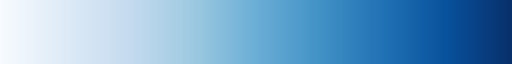

In [103]:
cm._colormaps['Blues']

#### Utils funcs

In [5]:
def scale_(matrix, axis=0):
    return (matrix - np.nanmin(matrix, axis=axis)) / (np.nanmax(matrix, axis=axis) - np.nanmin(matrix, axis=axis))

def select_channels_(ch_names, ROIs, montage):
    """
    ch_names : list of strings, each string being a channel name, composed as follows : <subject id>_<shaft><number>
    ROIs : list of strings, or string, each string being a Region Of Interest (ROI) name (nomenclature as used by the APHM neurologists)
    montage : string, either 'monopolar' or 'bipolar'

    returns : list of strings & list of indexes, the former being the selected channels, the latter being the indexes of the selected channels in the original ch_names list
    """
    if type(ROIs) == str:  # if only one ROI is given
        ROIs = [ROIs]
    import regex as re
    selected_channels = []
    selected_indexes = []
    for i_ch,ch_name in enumerate(ch_names):
        if montage == 'monopolar': modified_ch_name = re.sub(r'[\d_]', '', ch_name)  # remove any '<digit>_'
        else: modified_ch_name = re.sub(r'[\d_]', '', ch_name.split('-')[0])
        
        if modified_ch_name in ROIs:
            selected_channels.append(ch_name)
            selected_indexes.append(i_ch)
    return selected_channels, selected_indexes

def from_chname_to_subjects(ch_names_list_or_array):
    """
    ch_names_list_or_array : list or array of strings, each string being a channel name, composed as follows : <subject id>_<shaft><number>
    """
    subs = []
    n_by_sub = []
    
    for ch_name in ch_names_list_or_array:
        subj_id = ch_name.split('_')[0]
        last_id = subs[-1] if len(subs) > 0 else None
        if subj_id == last_id:
            n_by_sub[-1] += 1
        else:
            subs.append(subj_id)
            n_by_sub.append(1)
        if subj_id not in subs:
            subs.append(ch_name.split('_')[0])
    return subs, n_by_sub

# function to remove isolated channels
def searchlight(loc, name, distance_threshold = 5, n_sub=2, n_repeat = 1, metrics = 'euclidean', weight_axis = None):
    '''
    name: list of channel names (e.g. ['001-shaft_01', '001-shaft'_02', '002-shaft_02'])
    if minkowski, weight_axis is the weighting of different dimensions

    returns: list of booleans, True if the channel is to be kept, False if it is to be ignored, can be used as a mask
    '''
    from scipy.spatial.distance import cdist

    temp_loc, temp_name = loc.copy(), name.copy()
    
    channels_ignore = []  

    for i_repeat in range(n_repeat):
        dist_matrix = cdist(temp_loc,temp_loc, metrics, w = weight_axis)  # computes distance matrix between all channels

        for channel_index in range(dist_matrix.shape[0]):
            if not channel_index in channels_ignore:
                subject_channel = temp_name[channel_index].split('-')[0]
                subject_neighbour_list = []
                for neighbour_index in range(dist_matrix.shape[0]):
                    distance_neighbour = dist_matrix[channel_index,neighbour_index]
                    subject_neighbour = temp_name[neighbour_index].split('-')[0]
                    if subject_neighbour != subject_channel and not subject_neighbour in subject_neighbour_list and distance_neighbour < distance_threshold:
                        subject_neighbour_list.append(subject_neighbour)
                if len(subject_neighbour_list) < n_sub:
                    channels_ignore.append(channel_index)
            else:
                True
    channels_keep = [not (i in (channels_ignore)) for i in np.arange(loc.shape[0])]
    return channels_keep

def stat_only_scores_channels_loc(model_name, df_permuts, df_meta, n_permuts, remove_loners=True, threshold=0.99):
    """
    model_name : string, the name of the model to be tested
    df_permuts : pd.DataFrame, the dataframe containing the permutation results, the first element is the non-permuted score, the rest are the permuted ones    
    model_name : string, the name of the model to be tested
    df_permuts : pd.DataFrame, the dataframe containing the permutation results, the first element is the non-permuted score, the rest are the permuted ones
    df_meta : pd.DataFrame, the dataframe containing the meta-subject information (channel names, locations, ...)
    returns : a dict containing relative scores, channels, locations and base scores for a given model
    """

    dico_output = {}
    # print(f"remove_loners = {remove_loners}")

    # get the data above statistical threshold
    dr = np.vstack(df_permuts[model_name].values) - np.matmul(df_permuts['base'].values.reshape(-1, 1), np.ones((1, n_permuts+1)))
    thresholds = np.percentile(dr[:,1:], q=threshold*100, axis=1)
    stat = dr[:,0] >= thresholds
    # print(sum(stat))

    channels = df_permuts['ch_names'].values
    loc = np.vstack(df_meta['loc'].values)

    # mask the data
    channels = channels[stat]
    loc = loc[stat,:]
    dr = dr[stat,0]
    base_scores = df_permuts['base'].values[stat]

    if remove_loners:  # apply searchlight if needed
        searchlight_mask = my_utils.searchlight(loc, channels, distance_threshold=5, n_sub=2, n_repeat=1, metrics='euclidean', weight_axis=None)
        channels = channels[searchlight_mask]
        loc = loc[searchlight_mask]
        dr = dr[searchlight_mask]
        base_scores = base_scores[searchlight_mask]

        # print(sum(searchlight_mask))

    # fill up dico
    dico_output['relative_scores'] = dr
    dico_output['channels'] = channels
    dico_output['locations'] = loc
    dico_output['base_scores'] = base_scores

    return dico_output

def from_permut_to_pvals_1(scores_with_permutations):
    """
    scores_with_permutations : array of shape (n_channels, n_permutations + 1), where the first column is the non-permuted score and the rest are the permuted ones
    returns : array of shape (n_channels), channel-wise the p-values
    """
    return(np.vstack([1 - percentileofscore(scores_with_permutations[i,1:],  scores_with_permutations[i,0], 'strict')/100  for i in range(scores_with_permutations.shape[0])]))

def from_permut_to_pvals_3(scores_with_permutations):
    """
    Compute p-values from permutation scores.
    """
    pvals = np.zeros((scores_with_permutations.shape[0], 1))
    for i in range(scores_with_permutations.shape[0]):
        # Sort the array and find the index of the original (non-permuted) score
        sorted_scores = sorted(scores_with_permutations[i, :])
        original_score = scores_with_permutations[i, 0]
        # Find the first occurrence of the original score in the sorted array
        match_idx = np.where(np.array(sorted_scores) == original_score)[0][0]
        # Compute p-value
        pvals[i, 0] = 1 - match_idx / scores_with_permutations.shape[1]
    return pvals

def craft_dico_relative_to_base(model_name, df_permuts, n_permuts):
    """
    model_name : string, the name of the model to be tested
    df_permuts : pd.DataFrame, the dataframe containing the permutation results, the first element is the non-permuted score, the rest are the permuted ones
    df_meta : pd.DataFrame, the dataframe containing the meta-subject information (channel names, locations, ...)
    returns : a dict containing relative scores, channels, locations and base scores for a given model
    """
    print(f"crafting dico for {model_name}")
    dico_output = {}

    # get the relative scores for 1. (base + foi) - base  and 2. full - (full -foi)
    dr = np.vstack(df_permuts[model_name].values) - np.matmul(df_permuts['base'].values.reshape(-1, 1), np.ones((1, n_permuts+1)))  # (base + foi) - base
    # get pvalues on each channel's permutations (otherwise it is computed on the flattenned array)
    pvals = from_permut_to_pvals_1(dr)

    # fill dict
    dico_output['dr'] = dr
    dico_output['pvals'] = pvals

    return dico_output

def from_bn_to_clem(df):
    """
    df: pandas DataFrame, with each row corresponding to a subject (index = subject_id), with various columns partially nan filled towards the lasts columns
    returns: 1-D numpy array, concatenating all non-nan values from each row (all subjects all channels concatenated, order kept)
    """
    all_data = []
    for _, row in df.iterrows():
        # print(df.index[i])
        u = row.values
        u_clean = u[~pd.isna(u)]
        all_data.append(u_clean)
    return np.concatenate(all_data)

def generate_colormap_svg(scores, cmap, output_path, title=None, background_color='white'):
    from matplotlib.colors import Normalize
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.ticker import FormatStrFormatter
    from matplotlib.ticker import MaxNLocator
    """
    Generate a colormap as an SVG file from a set of scores.

    Parameters:
        scores (array-like): Array of scores to generate the colormap.
        cmap (Colormap): Matplotlib colormap to use for the visualization or cmap object
        output_path (str): Path to save the SVG file.
        tick_format (str): Format string for tick labels.
    """
    # Normalize the scores
    norm = Normalize(vmin=np.min(scores), vmax=np.max(scores))

    # Create a figure and axis for the colormap
    fig, ax = plt.subplots(figsize=(1, 6))
    fig.subplots_adjust(right=.4,bottom=0.1)

    # Set background color
    fig.patch.set_facecolor(background_color)

    # Create a colorbar
    cbar = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
    # Format the tick labels
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
    cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    
    fig.tight_layout()
    # Save the colormap as an SVG file
    plt.savefig(output_path+f'/{title}.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig)

# # Example usage
# scores = np.random.rand(100)  # Example scores
# output_path = "/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/figures/broadband/CCN2025/colormap.svg"
# colormap = my_utils.create_mix_colormap('dimgray', colors_[m])
# test = np.arange(0, np.pi, 0.01)

# quick function that takes a plt color and return a lighter version (alpha as parameter)
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.

    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

def adjust_palette_alpha(palette, q):
    """
    Adjust the alpha values of a palette by multiplying by q.
    Parameters:
        palette (dict): A dictionary where keys are labels and values are RGBA tuples.
        q (float): The scaler for the alpha values.
    Returns:
        dict: A new palette with adjusted alpha values.
    """
    q = np.abs(q)
    if q > 1:
        raise ValueError("q must be between 0 and 1, inclusive.")
    
    adjusted_palette = {}
    for key, rgba in palette.items():
        if len(rgba) != 4:
            raise ValueError(f"Color for '{key}' is not an RGBA tuple: {rgba}")
        r, g, b, a = rgba
        adjusted_alpha = max(0, min(1, a * q))  # Ensure alpha stays in [0, 1]
        adjusted_palette[key] = (r, g, b, adjusted_alpha)
    
    return adjusted_palette

colors_rgba_adjusted_1 = adjust_palette_alpha(colors_rgba_, 0.6666)
colors_rgba_adjusted_2 = adjust_palette_alpha(colors_rgba_, 0.5)

def insert_row(idx, df, df_insert):
    """
    Insert a row into a DataFrame at a specified index without using .append().
    
    Parameters:
        idx (int): The index at which to insert the new row.
        df (pd.DataFrame): The original DataFrame.
        df_insert (pd.DataFrame): A single-row DataFrame to insert.

    Returns:
        pd.DataFrame: A new DataFrame with the row inserted.
    """
    dfA = df.iloc[:idx, ]
    dfB = df.iloc[idx:, ]

    # Use pd.concat to combine the slices and the new row
    df = pd.concat([dfA, df_insert, dfB], ignore_index=True)

    return df

def load_and_process(result_path, rejected_mask, pvals):
    data_permuts = np.load(os.path.join(result_path, 'r2_full_perm.npy'))[rejected_mask, :]  # loading r² w/ and w/o predictive features permutations
    data = np.load(os.path.join(result_path, 'r2_full_true.npy'))[rejected_mask, :]
    data_controls = np.load(os.path.join(result_path, 'r2_reduced_true.npy'))[rejected_mask, :]

    if data.shape != data_controls.shape:
        raise ValueError("Data and control data shapes do not match.")

    data = from_bn_to_clem(pd.DataFrame(data))  # transformation to clem format
    data_controls = from_bn_to_clem(pd.DataFrame(data_controls))
    
    thresholds = {p: np.percentile(data_permuts, 100*(1-p), axis=2) for p in pvals}  
    array_thresholds = {p: from_bn_to_clem(pd.DataFrame(thresholds[p])) for p in pvals}
    masks = {p: data >= array_thresholds[p] for p in pvals}  # create masks for each p-value
    return masks, data, data_controls

def filter_nans(array):
    array = np.asarray(array)
    return array[~np.isnan(array)]

# test = np.array([[0, 1, 2, np.nan, 4, np.nan, 6]])
# print(filter_nans(test))  # Output: [0. 1. 2. 4. 6.]

def xpos_from_ordinal_data(data_array, spread=1):
    """ generate x positions for a set of ordinal data points, so that points with the same value are spread symetrcally around the base_x position.
    data_array: 1-D array-like, ordinal data points
    spread: float, total spread of the data points with the same value
    """
    x_positions = np.zeros(len(data_array))
    for i, val in enumerate(data_array):
        count_same_value_before = np.sum(data_array[:i] == val)
        total_count_same_value = np.sum(data_array == val)
        if total_count_same_value > 1:
            jitter = (count_same_value_before - (total_count_same_value - 1) / 2) * (spread / (total_count_same_value - 1))
        else:
            jitter = 0
        x_positions[i] = jitter

    return x_positions

test_array = np.array([1, 2, 2, 3, 4, 4, 4, 5, 5])
xpos_from_ordinal_data(test_array, spread=.5)

def plot_pair_violinboxscatter(ax, data_1, data_2, x1, x2, color1, color2, inter_pair_gap=0.2):
    """ for a pair of 1-D data array, plot violin, box and scatter, starting from the exterior of the plotted pair, then going inward, so that the scatters are plotted clostest to the center and the paired samples can be linked with lines.
    ax: matplotlib axis
    data_1: 1-D array-like, first data to plot
    x1: float, x position for data_1
    color1: str, color for data_1
    label1: str, label for data_1
            same for data_2
    """

    # violin plots
    parts1 = ax.violinplot(data_1, positions=[x1], showmeans=False, showmedians=False, showextrema=False, side='low', widths=0.25)
    for pc in parts1['bodies']:
        pc.set_facecolor(lighten_color(color1, .35))
        pc.set_edgecolor(color1)
        pc.set_alpha(0.3)
    parts2 = ax.violinplot(data_2, positions=[x2], showmeans=False, showmedians=False, showextrema=False, side='high', widths=0.25)
    for pc in parts2['bodies']:
        pc.set_facecolor(lighten_color(color2, .35))
        pc.set_edgecolor(color2)
        pc.set_alpha(0.3)

    # box plots
    ax.boxplot(data_1, positions=[x1], widths=0.05, boxprops=dict(color=color1), medianprops=dict(color=color1))
    ax.boxplot(data_2, positions=[x2], widths=0.05, boxprops=dict(color=color2), medianprops=dict(color=color2))

    # scatter plots
    jitters_1 = xpos_from_ordinal_data(data_1, spread=inter_pair_gap/2)
    ax.scatter(np.full(len(data_1), x1+inter_pair_gap/2)+jitters_1, data_1, color=color1, alpha=0.7, edgecolors='none', s=12)
    jitters_2 = xpos_from_ordinal_data(data_2, spread=inter_pair_gap/2)
    ax.scatter(np.full(len(data_2), x2-inter_pair_gap/2)+jitters_2, data_2, color=color2, alpha=0.7, edgecolors='none', s=12)

    # draw intersubject lines
    idx_for_lines = [u for u in range(len(data_1)) if not np.isnan(data_1[u]) and not np.isnan(data_2[u])]  # only subjects with both pos and neg values
    for u in idx_for_lines:
        ax.plot([x1+inter_pair_gap/2 + jitters_1[u], x2-inter_pair_gap/2 + jitters_2[u]], [data_1[u], data_2[u]], color='gray', alpha=0.3, linewidth=0.8)

def plot_statistical_comparison(ax, data_1, data_2, x1, x2, test_func=ttest_rel, alternative='two-sided', y_stat = None):
    """
    Add statistical comparison annotation between two data arrays on a matplotlib axis.
    
    Parameters:
        ax: matplotlib axis object
        data_1, data_2: array-like, data to compare
        x1, x2: float, x positions for the two data groups
        test_func: callable, statistical test function (default: ttest_rel, can be : mannwhitneyu, wilcoxon)
        alternative: str, alternative hypothesis for the test
    """
    from scipy.stats import ttest_rel, mannwhitneyu, wilcoxon, false_discovery_control

    ## case with 2 data arrays to compare
    if data_2 is not None and x2 is not None:
        _, pval = test_func(data_1, data_2, alternative=alternative, nan_policy='omit')

        if y_stat is not None:
            y_star = y_stat
        else:
            y_max = max(np.nanmax(data_1), np.nanmax(data_2))
            y_min = min(np.nanmin(data_1), np.nanmin(data_2))
            y_star = y_max * 1.1 #  + (y_max - y_min) * 0.1

        pval = false_discovery_control(pval, method='bh')
        
        if pval < 0.05:
            if pval < 0.001:
                star = '***'
            elif pval < 0.01:
                star = '**'
            else:
                star = '*'
            ax.plot([x1, x2], [y_star, y_star], 'k-')
            ax.text((x1 + x2) / 2, y_star, star, 
                    ha='center', va='bottom', color='k', fontsize=12)
        else:
            ax.text((x1 + x2) / 2, y_star, 'n.s.', 
                    ha='center', va='bottom', color='k', fontsize=10)
            
    ## case with only one data array to compare against zero        
    else:
        # single sample test against zero
        if test_func == mannwhitneyu:
            raise ValueError("mannwhitneyu requires two samples for comparison.")
        if test_func == ttest_rel: 
            from scipy.stats import ttest_1samp
            test_func = ttest_1samp 
            _, pval = test_func(data_1, 0, alternative=alternative, nan_policy='omit')
        elif test_func == wilcoxon:        
            _, pval = test_func(data_1, None, alternative=alternative, nan_policy='omit')
        
        pval = false_discovery_control(pval, method='bh')

        if y_stat is not None:
            y_star = y_stat
        else:
            y_max = np.nanmax(data_1)
            y_min = np.nanmin(data_1)
            y_star = y_max * 1.1 #  + (y_max - y_min) * 0.1

        if pval < 0.05:
            if pval < 0.001:
                star = '***'
            elif pval < 0.01:
                star = '**'
            else:
                star = '*'
            ax.plot([x1 - 0.1, x1 + 0.1], [y_star, y_star], 'k-')
            ax.text(x1, y_star , star, 
                    ha='center', va='bottom', color='k', fontsize=12)
        else:
            ax.text(x1, y_star , 'n.s.', 
                    ha='center', va='bottom', color='k', fontsize=10)


## Figures

### Tracking (onsets)

#### Mise en place

In [6]:
# load onsets files
onset_results_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/broadband/data/bb_clem_permuts_3onsets/'

subjects_onsets = np.load(os.path.join(onset_results_path, 'subjects.npy'))  # subject list
print(f'Subjects included in onset analysis :  {subjects_onsets.shape[0]}\n{subjects_onsets}')
rejected_subj_mask_onsets = [True if s not in excluded_subjects else False for s in subjects_onsets]

data_permuts_onsets = np.load(os.path.join(onset_results_path, 'r2_full_perm.npy'))[rejected_subj_mask_onsets, :]  # loading r² w/ and w/o onsets permutations
print('Scores with permutations shape : ', data_permuts_onsets.shape)
data_onsets = np.load(os.path.join(onset_results_path, 'r2_full_true.npy'))[rejected_subj_mask_onsets, :]
data_controls = np.load(os.path.join(onset_results_path, 'r2_reduced_true.npy'))[rejected_subj_mask_onsets, :]

data_onsets = from_bn_to_clem(pd.DataFrame(data_onsets))  # transformation to clem format
data_controls = from_bn_to_clem(pd.DataFrame(data_controls))

# define thresholds
pvals = [0.01, 0.005, 0.001]
thresholds_onsets = {p: np.percentile(data_permuts_onsets, 100*(1-p), axis=2) for p in pvals}
array_thresholds_onsets = {p: from_bn_to_clem(pd.DataFrame(thresholds_onsets[p])) for p in pvals}
print(array_thresholds_onsets[0.001].shape)

masks_onsets = {p: data_onsets >= array_thresholds_onsets[p] for p in pvals}  # create masks for each p-value

dr2_onsets = data_onsets - data_controls  # difference in r² between full and reduced model


Subjects included in onset analysis :  54
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 26 27
 28 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 49 51 52 53 54
 55 57 58 59 60 61]
Scores with permutations shape :  (51, 217, 1000)
(7304,)


#### Figures

Does dr² predict significance?
Logistic Regression Accuracy = 0.9652
AUC = 0.8663 

Does r² predict significance?
Logistic Regression Accuracy = 0.9430
AUC = 0.7748 


/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might n

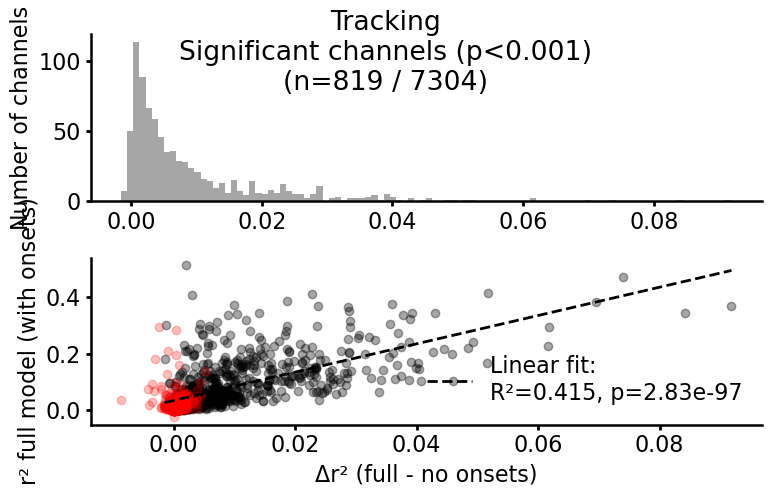

In [7]:
%matplotlib inline
p = 0.001
mask = masks_onsets[p]

# compute correlation on stat channels and get the linear model
slope, intercept, r_value, p_value, std_err = linregress(dr2_onsets[mask], data_onsets[mask])
x_line = np.array([dr2_onsets[mask].min(), dr2_onsets[mask].max()])
y_line = slope * x_line + intercept

# logistic regression
dr2_ = dr2_onsets.reshape(-1, 1)  # features (dr2 scores)
y = mask.astype(int)  # target (0 or 1)
log_reg = LogisticRegression(C=1)
log_reg_ = LogisticRegression(C=1)
log_reg.fit(scale(dr2_), y)
log_reg_.fit(scale(data_onsets.reshape(-1, 1)), y)
y_pred = log_reg.predict(scale(dr2_))  # get predictions ŷ
y_pred_ = log_reg_.predict(scale(data_onsets.reshape(-1, 1)))  # get predictions ŷ
accuracy = accuracy_score(y, y_pred)  # evaluate scores
auc = roc_auc_score(y, y_pred)
accuracy_ = accuracy_score(y, y_pred_)
auc_ = roc_auc_score(y, y_pred_)
print(f"Does dr² predict significance?\nLogistic Regression Accuracy = {accuracy:.4f}\nAUC = {auc:.4f} ")
print(f"\nDoes r² predict significance?\nLogistic Regression Accuracy = {accuracy_:.4f}\nAUC = {auc_:.4f} ")

f, ax = plt.subplots(2, 1, figsize=(8, 5));

# ax[0].hist(dr2, bins=100, color='gray', alpha=0.7)
ax[0].hist(dr2_onsets[mask], bins=100, color='gray', alpha=0.7)
# ax[0].set_xlabel('Δr² (full - no onsets)')
ax[0].set_ylabel('Number of channels')

ax[1].scatter(dr2_onsets[mask], data_onsets[mask], color='k', alpha=0.35)
ax[1].scatter(dr2_onsets[~mask], data_onsets[~mask], color='red', alpha=0.25)
ax[1].plot(x_line, y_line, 'k--', linewidth=2, label=f'Linear fit:\nR²={r_value**2:.3f}, p={p_value:.2e}')
ax[1].set_ylabel('r² full model (with onsets)')
ax[1].set_xlabel('Δr² (full - no onsets)')
ax[1].legend()

for i in range(2):
    ax[i].spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.suptitle(f'Tracking\nSignificant channels (p<{p})\n(n={np.sum(mask)} / {len(mask)})', y=1.);

if save_figs:
    f.savefig(f'{fig_path}/broadband/png/onsets_dr2_correlation_p<{p}.png', dpi=300, bbox_inches='tight')
    f.savefig(f'{fig_path}/broadband/svg/onsets_dr2_correlation_p<{p}.svg', format='svg', bbox_inches='tight')

/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:206: FutureWarning: The 'offscreen' parameter is deprecated and will be removed in 1.9. as it has no effect
  brain = mne.viz.Brain(subjects_dir=surf_path, subject = 'fsaverage',


Using pyvistaqt 3d backend.


/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


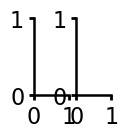

In [8]:
### Brain plot : tracking channels dr²

onset_locs = all_locs[masks_onsets[p], :]
onset_chans = all_chans[masks_onsets[p]]
# s = np.ones(len(onset_chans))
s = dr2_onsets[masks_onsets[p]]
s = np.clip(s, a_min=0, a_max=np.percentile(s, 99))


viz_utils.brainscatter_static(scores=s, locations=onset_locs.T, channels=onset_chans, background='white', min_scores=0, cmap=cm.jet, close=False, fig_label=f'Onsets');  # , hems = ['both']



### 6Preds BB vs HFa

#### Mise en place

In [11]:
### same for predictive features

# load pred files
bb_6preds_results_path  = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/1000permut_6preds/bb_100Hz_permuts_5acc3ons6preds_6preds/'
hfa_6preds_results_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/1000permut_6preds/HFa_100Hz_permuts_5acc3ons6preds_6preds/'

subjects_6preds_bb = np.load(os.path.join(bb_6preds_results_path, 'subjects.npy'))  # subject list
subjects_6preds_hfa = np.load(os.path.join(hfa_6preds_results_path, 'subjects.npy')) 
# print(f'Subjects included in predictive features analysis (BB) :  {subjects_6preds_bb.shape[0]}\n{subjects_6preds_bb}')
# print(f'Subjects included in predictive features analysis (HFA) :  {subjects_6preds_hfa.shape[0]}\n{subjects_6preds_hfa}')

# Checking that both subject lists are identical
if subjects_6preds_bb.tolist() != subjects_6preds_hfa.tolist():
    raise ValueError("Subject lists for BB and HFA do not match.")
else :
    rejected_subj_mask_6preds = [True if s not in excluded_subjects else False for s in subjects_6preds_bb]


## BroadBand
masks_6preds_bb, data_6preds_bb, data_controls_6preds_bb = load_and_process(bb_6preds_results_path, rejected_subj_mask_6preds, pvals)
dr2_6preds_bb = data_6preds_bb - data_controls_6preds_bb  # difference in r² between full and reduced model


## High-Frequency Activity
masks_6preds_hfa, data_6preds_hfa, data_controls_6preds_hfa = load_and_process(hfa_6preds_results_path, rejected_subj_mask_6preds, pvals)
dr2_6preds_hfa = data_6preds_hfa - data_controls_6preds_hfa  # difference in r² between full and reduced model


### Data Preparation (from scores to statistical channels)

# models[2:]
pvals_to_test = [5*1e-2, 1e-2, 5*1e-3, 1e-3, 5*1e-4]
pvals_to_test = pvals_to_test[::-1]

### Tracking models (onsets only)


### Predictive models (w. surprise and entropy)
stat_masks = {}  # init

# build dico stat masks
for p in pvals_to_test:
    stat_masks[p] = {}
    for m in models[2:]:  # for each model except base and full
        stat_masks[p][m] = {}
        # print(f"model {m}")
        data = np.vstack(df_permutations[m].values)
        stat_masks[p][m]['mask'] = from_permut_to_pvals_1(data) < p
        stat_masks[p][m]['channels'] = all_chans[stat_masks[p][m]['mask'][:,0]]

#### Figures

/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/home/sauvage/anaconda3/envs/mne/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might n

Does dr² predict significance?
Logistic Regression Accuracy = 0.9335
AUC = 0.7127 

Does r² predict significance?
Logistic Regression Accuracy = 0.8994
AUC = 0.5542 


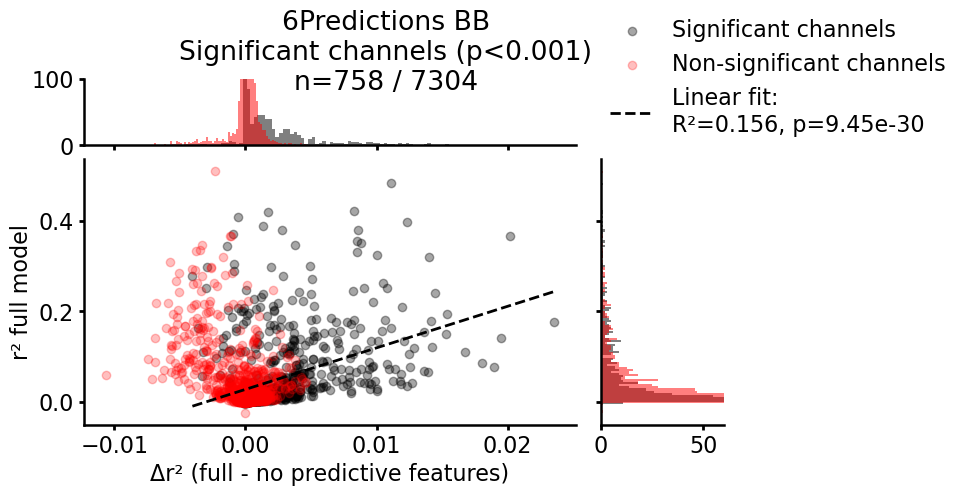

In [12]:
### same for 6preds_bb

p = 0.001
mask = masks_6preds_bb[p]
# compute correlation on stat channels and get the linear model
slope, intercept, r_value, p_value, std_err = linregress(dr2_6preds_bb[mask], data_6preds_bb[mask])
x_line = np.array([dr2_6preds_bb[mask].min(), dr2_6preds_bb[mask].max()])
y_line = slope * x_line + intercept
# logistic regression
dr2_ = dr2_6preds_bb.reshape(-1, 1)  # features (dr2 scores)
y = mask.astype(int)  # from boolean to binary 
log_reg = LogisticRegression(C=1)  # logistic regression for the dr² values
log_reg_ = LogisticRegression(C=1)  # logistic regression for the r² values
log_reg.fit(scale(dr2_), y)
log_reg_.fit(scale(data_6preds_bb.reshape(-1, 1)), y)
y_pred = log_reg.predict(scale(dr2_))  # get predictions ŷ
y_pred_ = log_reg_.predict(scale(data_6preds_bb.reshape(-1, 1)))  # get predictions ŷ
accuracy = accuracy_score(y, y_pred)  # evaluate scores
auc = roc_auc_score(y, y_pred)
accuracy_ = accuracy_score(y, y_pred_)
auc_ = roc_auc_score(y, y_pred_)    
print(f"Does dr² predict significance?\nLogistic Regression Accuracy = {accuracy:.4f}\nAUC = {auc:.4f} ")
print(f"\nDoes r² predict significance?\nLogistic Regression Accuracy = {accuracy_:.4f}\nAUC = {auc_:.4f} ")    

f, ax = plt.subplots(1, 1, figsize=(8, 5), sharex=True);

ax.scatter(dr2_6preds_bb[mask], data_6preds_bb[mask], color='k', alpha=0.35, label='Significant channels')
ax.scatter(dr2_6preds_bb[~mask], data_6preds_bb[~mask], color='red', alpha=0.25, label='Non-significant channels')
ax.plot(x_line, y_line, 'k--', linewidth=2, label=f'Linear fit:\nR²={r_value**2:.3f}, p={p_value:.2e}')
ax.set_ylabel('r² full model')
ax.set_xlabel('Δr² (full - no predictive features)')
  

ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)
ax_histx.hist(dr2_6preds_bb[mask], bins=100, color='black', alpha=0.5)
ax_histx.hist(dr2_6preds_bb[~mask], bins=100, color='red', alpha=0.5)
ax_histy.hist(data_6preds_bb[mask], bins=100, orientation='horizontal', color='black', alpha=0.5)
ax_histy.hist(data_6preds_bb[~mask], bins=100, orientation='horizontal', color='red', alpha=0.5)
ax_histx.set_ylim(ymax=100)
ax_histy.set_xlim(xmax=60)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)


# for a in [ax, ax_histx, ax_histy]:
ax.spines[['top', 'right']].set_visible(False)
ax_histx.spines[['top', 'right']].set_visible(False)
ax_histy.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.suptitle(f'6Predictions BB\nSignificant channels (p<{p})\nn={np.sum(mask)} / {len(mask)}', y=1.);
ax.legend(loc=(1.05, 1.05))


if save_figs:
    f.savefig(f'{fig_path}/broadband/png/predictive_6preds_bb_dr2_correlation_p<{p}.png', dpi=300, bbox_inches='tight')
    f.savefig(f'{fig_path}/broadband/svg/predictive_6preds_bb_dr2_correlation_p<{p}.svg', format='svg', bbox_inches='tight')

Does dr² predict significance?
Logistic Regression Accuracy = 0.9545
AUC = 0.5326 

Does r² predict significance?
Logistic Regression Accuracy = 0.9525
AUC = 0.5000 


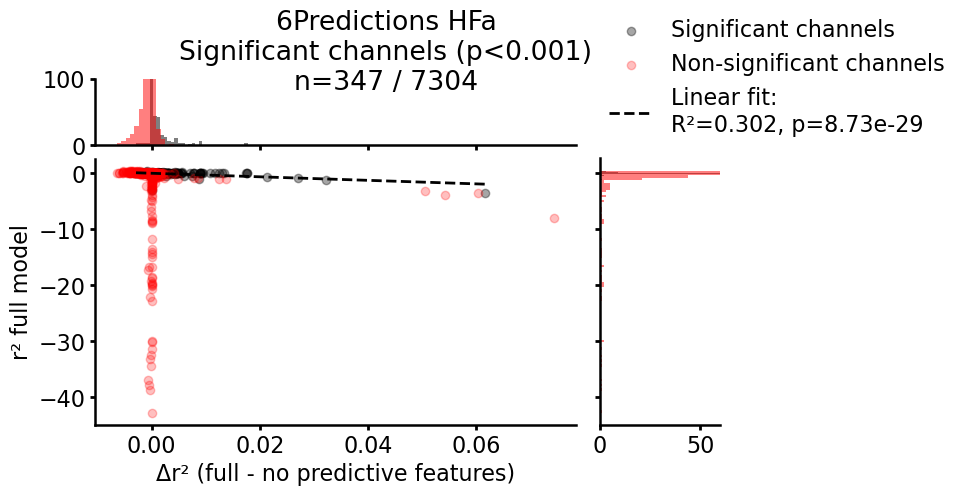

In [13]:
### same for 6preds_hfa

p = 0.001
mask = masks_6preds_hfa[p]
# compute correlation on stat channels and get the linear model
slope, intercept, r_value, p_value, std_err = linregress(dr2_6preds_hfa[mask], data_6preds_hfa[mask])
x_line = np.array([dr2_6preds_hfa[mask].min(), dr2_6preds_hfa[mask].max()])
y_line = slope * x_line + intercept
# logistic regression
dr2_ = dr2_6preds_hfa.reshape(-1, 1)  # features (dr2 scores)
y = mask.astype(int)  # from boolean to binary 
log_reg = LogisticRegression(C=1)  # logistic regression for the dr² values
log_reg_ = LogisticRegression(C=1)  # logistic regression for the r² values
log_reg.fit(scale(dr2_), y)
log_reg_.fit(scale(data_6preds_hfa.reshape(-1, 1)), y)
y_pred = log_reg.predict(scale(dr2_))  # get predictions ŷ
y_pred_ = log_reg_.predict(scale(data_6preds_hfa.reshape(-1, 1)))  # get predictions ŷ
accuracy = accuracy_score(y, y_pred)  # evaluate scores
auc = roc_auc_score(y, y_pred)
accuracy_ = accuracy_score(y, y_pred_)
auc_ = roc_auc_score(y, y_pred_)    
print(f"Does dr² predict significance?\nLogistic Regression Accuracy = {accuracy:.4f}\nAUC = {auc:.4f} ")
print(f"\nDoes r² predict significance?\nLogistic Regression Accuracy = {accuracy_:.4f}\nAUC = {auc_:.4f} ")    

f, ax = plt.subplots(1, 1, figsize=(8, 5), sharex=True);

ax.scatter(dr2_6preds_hfa[mask], data_6preds_hfa[mask], color='k', alpha=0.35, label='Significant channels')
ax.scatter(dr2_6preds_hfa[~mask], data_6preds_hfa[~mask], color='red', alpha=0.25, label='Non-significant channels')
ax.plot(x_line, y_line, 'k--', linewidth=2, label=f'Linear fit:\nR²={r_value**2:.3f}, p={p_value:.2e}')
ax.set_ylabel('r² full model')
ax.set_xlabel('Δr² (full - no predictive features)')
  

ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)
ax_histx.hist(dr2_6preds_hfa[mask], bins=100, color='black', alpha=0.5)
ax_histx.hist(dr2_6preds_hfa[~mask], bins=100, color='red', alpha=0.5)
ax_histy.hist(data_6preds_hfa[mask], bins=100, orientation='horizontal', color='black', alpha=0.5)
ax_histy.hist(data_6preds_hfa[~mask], bins=100, orientation='horizontal', color='red', alpha=0.5)
ax_histx.set_ylim(ymax=100)
ax_histy.set_xlim(xmax=60)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)


# for a in [ax, ax_histx, ax_histy]:
ax.spines[['top', 'right']].set_visible(False)
ax_histx.spines[['top', 'right']].set_visible(False)
ax_histy.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.suptitle(f'6Predictions HFa\nSignificant channels (p<{p})\nn={np.sum(mask)} / {len(mask)}', y=1.);
ax.legend(loc=(1.05, 1.05))


if save_figs:
    f.savefig(f'{fig_path}/broadband/png/predictive_6preds_bb_dr2_correlation_p<{p}.png', dpi=300, bbox_inches='tight')
    f.savefig(f'{fig_path}/broadband/svg/predictive_6preds_bb_dr2_correlation_p<{p}.svg', format='svg', bbox_inches='tight')

/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


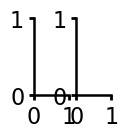

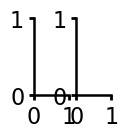

In [14]:
### brain plot : 6preds bb channels dr² and r²

locs_6preds_bb = all_locs[masks_6preds_bb[p], :]
chans_6preds_bb = all_chans[masks_6preds_bb[p]]
s = dr2_6preds_bb[masks_6preds_bb[p]]
s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))
    
viz_utils.brainscatter_static(scores=s, locations=locs_6preds_bb.T, channels=chans_6preds_bb, background='white', min_scores=0, cmap=cm.Greens, close=False, fig_label=f'dr² 6Preds BB');  # , hems = ['both']


s_ = data_6preds_bb[masks_6preds_bb[p]]  # r²
s_ = np.clip(s_, a_min=0, a_max=np.percentile(s_, 95))

viz_utils.brainscatter_static(scores=s_, locations=locs_6preds_bb.T, channels=chans_6preds_bb, background='white', min_scores=0, cmap=cm.Greens, close=False, fig_label=f'r² 6Preds BB');  # , hems = ['both']

/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


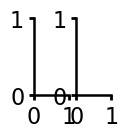

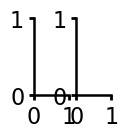

In [15]:
### brain plot : 6preds hfa channels dr²
locs_6preds_hfa = all_locs[masks_6preds_hfa[p], :]
chans_6preds_hfa = all_chans[masks_6preds_hfa[p]]
s = dr2_6preds_hfa[masks_6preds_hfa[p]]
s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

viz_utils.brainscatter_static(scores=s, locations=locs_6preds_hfa.T, channels=chans_6preds_hfa, background='white', min_scores=0, cmap=cm.Greens, close=False, fig_label=f'dr² 6Preds HFA');  # , hems = ['both']

s_ = data_6preds_bb[masks_6preds_hfa[p]]  # r²
s_ = np.clip(s_, a_min=0, a_max=np.percentile(s_, 95))

viz_utils.brainscatter_static(scores=s_, locations=locs_6preds_hfa.T, channels=chans_6preds_hfa, background='white', min_scores=0, cmap=cm.Greens, close=False, fig_label=f'r² 6Preds HFA');  # , hems = ['both']


/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


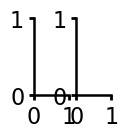

In [16]:
# f, ax = plt.subplots(1, 1, figsize=(6, 4));
# ax.hist(data_controls_6preds_bb[masks_6preds_bb[p]], bins=200, color='gray', alpha=0.7, label='Acoustic r²')


bb_6preds_10ii = data_controls_6preds_bb * masks_6preds_bb[p]
bb_6preds_10ii = np.where(bb_6preds_10ii > 0, 100, bb_6preds_10ii)  # positive values to 1
bb_6preds_10ii = np.where(bb_6preds_10ii < 0, 1, bb_6preds_10ii)  # negative values to 100


viz_utils.brainscatter_static(scores=bb_6preds_10ii, locations=all_locs.T, channels=all_chans, background='white', min_scores=0, cmap=cm.cool, close=False, fig_label=f'6Preds BB\nacoustic score sign\n(p<{p})');  # , hems = ['both']


/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


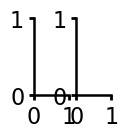

In [17]:
### same for HFA

hfa_6preds_10ii = data_controls_6preds_hfa * masks_6preds_hfa[p]
hfa_6preds_10ii = np.where(hfa_6preds_10ii > 0, 100, hfa_6preds_10ii)  # positive values to 1
hfa_6preds_10ii = np.where(hfa_6preds_10ii < 0, 1, hfa_6preds_10ii) # negative values to -1

viz_utils.brainscatter_static(scores=hfa_6preds_10ii, locations=all_locs.T, channels=all_chans, background='white', min_scores=0, cmap=cm.cool, close=False, fig_label=f'6Preds HFA\nacoustic score sign\n(p<{p})');  # , hems = ['both']

### Acou permuts

In [330]:
len(rejected_subj_mask)
sum(rejected_subj_mask)

7304

In [331]:
permuts_acou_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/HFa_100Hz_permuts_5acc'

data_permuts = np.load(os.path.join(permuts_acou_path, 'r2_full_perm.npy'))  # loading r² w/ and w/o predictive features permutations
data = np.load(os.path.join(permuts_acou_path, 'r2_full_true.npy'))  # [rejected_subj_mask, :]


if data.shape != data_permuts.shape:
    # raise ValueError("Data and control data shapes do not match.")
    print(data.shape, data_permuts.shape)

data = from_bn_to_clem(pd.DataFrame(data))  # transformation to clem format

print(data.shape)

thresholds = {p: np.percentile(data_permuts, 100*(1-p), axis=2) for p in pvals}  
array_thresholds = {p: from_bn_to_clem(pd.DataFrame(thresholds[p])) for p in pvals}
bn_acou_masks = {p: data >= array_thresholds[p] for p in pvals}  # create masks for each p-value

bn_acou_masks[0.001]


(54, 217) (54, 217, 1000)
(7825,)


array([False, False, False, ..., False, False, False])

### 4Preds HFA 1by1

#### Mise en place

In [19]:
pvals

[0.01, 0.005, 0.001]

In [ ]:
### load and transform data
p = 0.001

path_4preds = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/100permut_4preds'

# first load and build from full model
masks_full_4preds_hfa, full_4preds_hfa, data_controls_4preds_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_p4preds'), rejected_subj_mask_6preds, pvals)
dr2_4preds_hfa = full_4preds_hfa - data_controls_4preds_hfa  
mask_4preds_acou_pos_hfa = data_controls_4preds_hfa > 0 # acoustic control positive values mask
mask_4preds_acou_neg_hfa = data_controls_4preds_hfa < 0 # acoustic control negative values mask

# load each model of the (phoneme + word) * (entropy + surprise) design
masks_4preds_2E_hfa, _, data_controls_4preds_2E_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_p2entropy'), rejected_subj_mask_6preds, pvals)
masks_4preds_2S_hfa, _, data_controls_4preds_2S_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_p2surprise'), rejected_subj_mask_6preds, pvals)

masks_4preds_phE_hfa, _, data_controls_4preds_phE_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_ep'), rejected_subj_mask_6preds, pvals)
masks_4preds_phS_hfa, _, data_controls_4preds_phS_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_sp'), rejected_subj_mask_6preds, pvals)

masks_4preds_wdE_hfa, _, data_controls_4preds_wdE_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_ew'), rejected_subj_mask_6preds, pvals) 
masks_4preds_wdS_hfa, _, data_controls_4preds_wdS_hfa = load_and_process(os.path.join(path_4preds, 'HFa_100Hz_permuts_5acc3ons4preds_sw'), rejected_subj_mask_6preds, pvals) 

# compute dr² for each model
dr2_4preds_2S_hfa = full_4preds_hfa - data_controls_4preds_2E_hfa
dr2_4preds_2E_hfa = full_4preds_hfa - data_controls_4preds_2S_hfa
dr2_4preds_phE_hfa = full_4preds_hfa - data_controls_4preds_phE_hfa
dr2_4preds_phS_hfa = full_4preds_hfa - data_controls_4preds_phS_hfa
dr2_4preds_wdE_hfa = full_4preds_hfa - data_controls_4preds_wdE_hfa
dr2_4preds_wdS_hfa = full_4preds_hfa - data_controls_4preds_wdS_hfa


# instantiate moodel dico for 4preds_hfa
#################### should be sorted (model names, masks and scores in the same order) ####################
dico_4preds_hfa = {}
models_4preds = ['4preds', '2surprisal', '2entropy', 'phoneme\nsurprisal', 'phoneme\nentropy', 'word\nsurprisal', 'word\nentropy']
masks_4preds_hfa = [masks_full_4preds_hfa, masks_4preds_2S_hfa, masks_4preds_2E_hfa, masks_4preds_phS_hfa, masks_4preds_phE_hfa, masks_4preds_wdS_hfa, masks_4preds_wdE_hfa]
dr2_models_4preds = [dr2_4preds_hfa, dr2_4preds_2S_hfa, dr2_4preds_2E_hfa, dr2_4preds_phS_hfa, dr2_4preds_phE_hfa, dr2_4preds_wdS_hfa, dr2_4preds_wdE_hfa]

# fill handy dico with masks and scores
for i, m in enumerate(models_4preds):
    dico_4preds_hfa[m] = {}
    dico_4preds_hfa[m]['mask'] = masks_4preds_hfa[i]
    dico_4preds_hfa[m]['dr2'] = dr2_models_4preds[i]


### build the data to compare models between acoustic and non-acoustic clusters
dico_4preds_hfa_by_cluster = {'acou_pos': {}, 'acou_neg': {}}
for i_m, m in enumerate(models_4preds):
    # init lists
    n_pos = []  # number of significant channels by subject
    proportion_pos = []  # proportion of significant channels by subject (within cluster / total * channels)
    dr2_pos = []  # avg relative score by subject
    dr2_prop_pos = []  # avg relative score by subject, weighted by proportion of total explained variance
    n_neg, proportion_neg, dr2_neg, dr2_prop_neg = [], [], [], []  # init lists for acoustic clusters

    mask = dico_4preds_hfa[m]['mask'][p]  # overall mask by model
    mask_pos = mask & mask_acou_pos
    mask_neg = mask & mask_acou_neg

    selected_chans_pos = all_chans[mask_pos]
    selected_chans_neg = all_chans[mask_neg]

    subject_in_pos, n_by_subject_pos = my_utils.from_chname_to_subjects(selected_chans_pos)
    subject_in_neg, n_by_subject_neg = my_utils.from_chname_to_subjects(selected_chans_neg)
    
    # browse through subjects to build pos, then neg
    for id in subjects_ids:
        # mask to get all channels for that subject
        s_chans = np.array([ch for ch in all_chans if id in ch])

        if id not in subject_in_pos:
            n_pos.append(0)
            proportion_pos.append(0)
            dr2_pos.append(np.nan)
            dr2_prop_pos.append(np.nan)
        else:
            i_subj = subject_in_pos.index(id)
            n_pos.append(n_by_subject_pos[i_subj])
            proportion_pos.append(n_by_subject_pos[i_subj] / s_chans.shape[0])  # normalizing by the total number of channels for that subject (* and n.s.)
            ch_subj = [ch__name for ch__name in selected_chans_pos if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  # select all channels for that subject
            dr2_pos.append(np.nanmean(dico_4preds_hfa[m]['dr2'][mono_subj_mask]))  # average dr² for that subject's channels
            dr2_prop_pos.append(np.nanmean(dico_4preds_hfa[m]['dr2'][mono_subj_mask]/full_4preds_hfa[mono_subj_mask]))  # average total score proportion for that subject's channels


        if id not in subject_in_neg:
            n_neg.append(0)
            proportion_neg.append(0)
            dr2_neg.append(np.nan)
            dr2_prop_neg.append(np.nan)
        else:
            i_subj = subject_in_neg.index(id)
            n_neg.append(n_by_subject_neg[i_subj])
            proportion_neg.append(n_by_subject_neg[i_subj] / s_chans.shape[0])
            ch_subj = [ch__name for ch__name in selected_chans_neg if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  
            dr2_neg.append(np.nanmean(dico_4preds_hfa[m]['dr2'][mono_subj_mask]))
            dr2_prop_neg.append(np.nanmean(dico_4preds_hfa[m]['dr2'][mono_subj_mask]/full_4preds_hfa[mono_subj_mask]))


    # fill dico
    dico_4preds_hfa_by_cluster['acou_pos'][m] = {}
    dico_4preds_hfa_by_cluster['acou_pos'][m]['n'] = np.asarray(n_pos)
    dico_4preds_hfa_by_cluster['acou_pos'][m]['proportion'] = np.array(proportion_pos)[~np.isnan(proportion_pos)]
    dico_4preds_hfa_by_cluster['acou_pos'][m]['dr2'] = np.asarray(dr2_pos)
    dico_4preds_hfa_by_cluster['acou_pos'][m]['dr2_prop'] = np.asarray(dr2_prop_pos)
    dico_4preds_hfa_by_cluster['acou_pos'][m]['names'] = all_chans[mask_pos]

    dico_4preds_hfa_by_cluster['acou_neg'][m] = {}
    dico_4preds_hfa_by_cluster['acou_neg'][m]['n'] = np.asarray(n_neg)
    dico_4preds_hfa_by_cluster['acou_neg'][m]['proportion'] = np.array(proportion_neg)[~np.isnan(proportion_neg)]
    dico_4preds_hfa_by_cluster['acou_neg'][m]['dr2'] = np.asarray(dr2_neg)  
    dico_4preds_hfa_by_cluster['acou_neg'][m]['dr2_prop'] = np.asarray(dr2_prop_neg)
    dico_4preds_hfa_by_cluster['acou_neg'][m]['names'] = all_chans[mask_neg]


# display the number of stat channels, model and cluster-wise
for am in [mask_acou_neg, mask_acou_pos]:
    for m in models_4preds:
        mask = dico_4preds_hfa[m]['mask'][p] & am
        print(f'{m} | * channels (p<{p}) : {np.sum(mask)} / {sum(dico_4preds_hfa[m]["mask"][p])}')
    print('\n')


4preds | * channels (p<0.001) : 300 / 532
2surprisal | * channels (p<0.001) : 204 / 373
2entropy | * channels (p<0.001) : 286 / 380
phoneme
surprisal | * channels (p<0.001) : 229 / 311
phoneme
entropy | * channels (p<0.001) : 270 / 351
word
surprisal | * channels (p<0.001) : 190 / 315
word
entropy | * channels (p<0.001) : 291 / 322


4preds | * channels (p<0.001) : 232 / 532
2surprisal | * channels (p<0.001) : 169 / 373
2entropy | * channels (p<0.001) : 94 / 380
phoneme
surprisal | * channels (p<0.001) : 82 / 311
phoneme
entropy | * channels (p<0.001) : 81 / 351
word
surprisal | * channels (p<0.001) : 125 / 315
word
entropy | * channels (p<0.001) : 31 / 322




#### Figures

/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


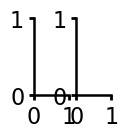

In [21]:
### 1 brain plot by model for 4preds_hfa

for m in models_4preds[:1]:
    mask = dico_4preds_hfa[m]['mask'][p]
    locs = all_locs[mask, :]
    chans = all_chans[mask]
    s = dico_4preds_hfa[m]['dr2'][mask]
    s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

    viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=chans, background='white', min_scores=0, cmap=cmaps_4preds[m], close=False, fig_label=f'dr² {m} HFA\nN={sum(mask)}');  # , hems = ['both']


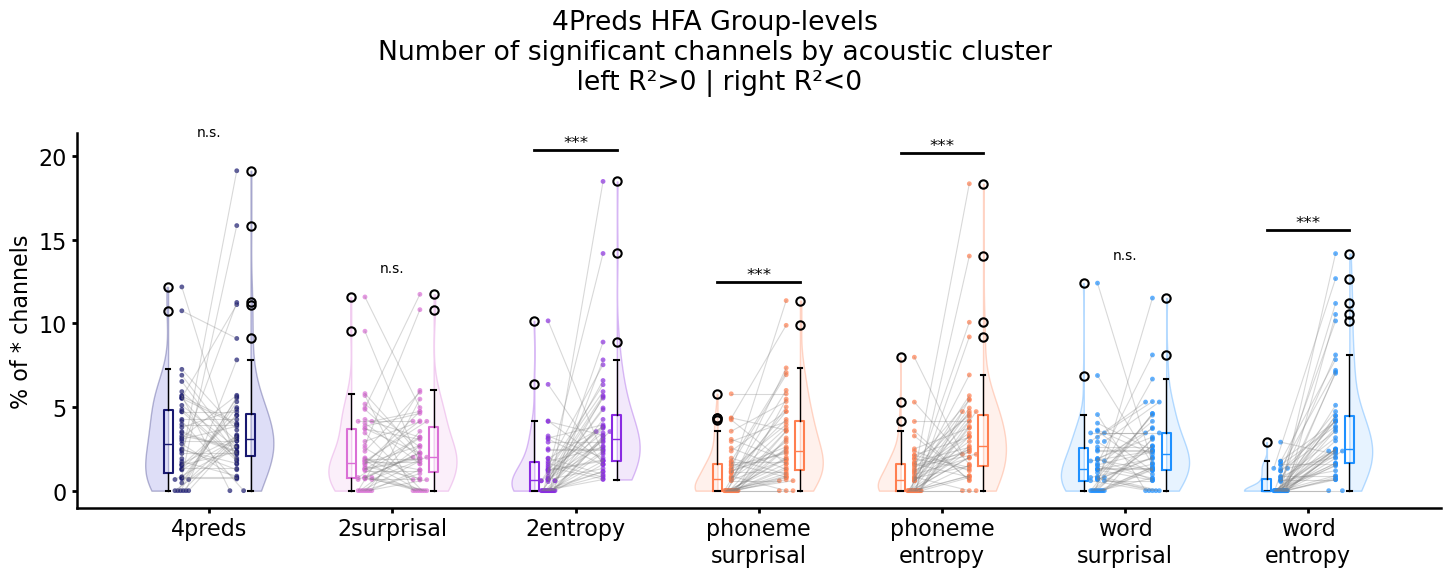

In [22]:
%matplotlib inline

x_ticks_positions = np.arange(len(models_4preds))
pos_neg_gap = 0.45
f, ax = plt.subplots(1, 1, figsize=(15, 6), sharex=True);

for i_m, m in enumerate(models_4preds):


    proportion_pos = dico_4preds_hfa_by_cluster['acou_pos'][m]['proportion']
    proportion_neg = dico_4preds_hfa_by_cluster['acou_neg'][m]['proportion']

    plot_pair_violinboxscatter(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    plot_statistical_comparison(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2)


    # dr2_prop_pos = dico_4preds_hfa_by_cluster['acou_pos'][m]['dr2_prop']
    # dr2_prop_neg = dico_4preds_hfa_by_cluster['acou_neg'][m]['dr2_prop']

    # plot_pair_violinboxscatter(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

    dr2_pos = dico_4preds_hfa_by_cluster['acou_pos'][m]['dr2']
    dr2_neg = dico_4preds_hfa_by_cluster['acou_neg'][m]['dr2']

    # plot_pair_violinboxscatter(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

# ticks and spines
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(x_ticks_positions, models_4preds)
ax.set_ylabel('% of * channels')
f.suptitle(f'4Preds HFA Group-levels\nNumber of significant channels by acoustic cluster\n left R²>0 | right R²<0', y=.97);
f.tight_layout()



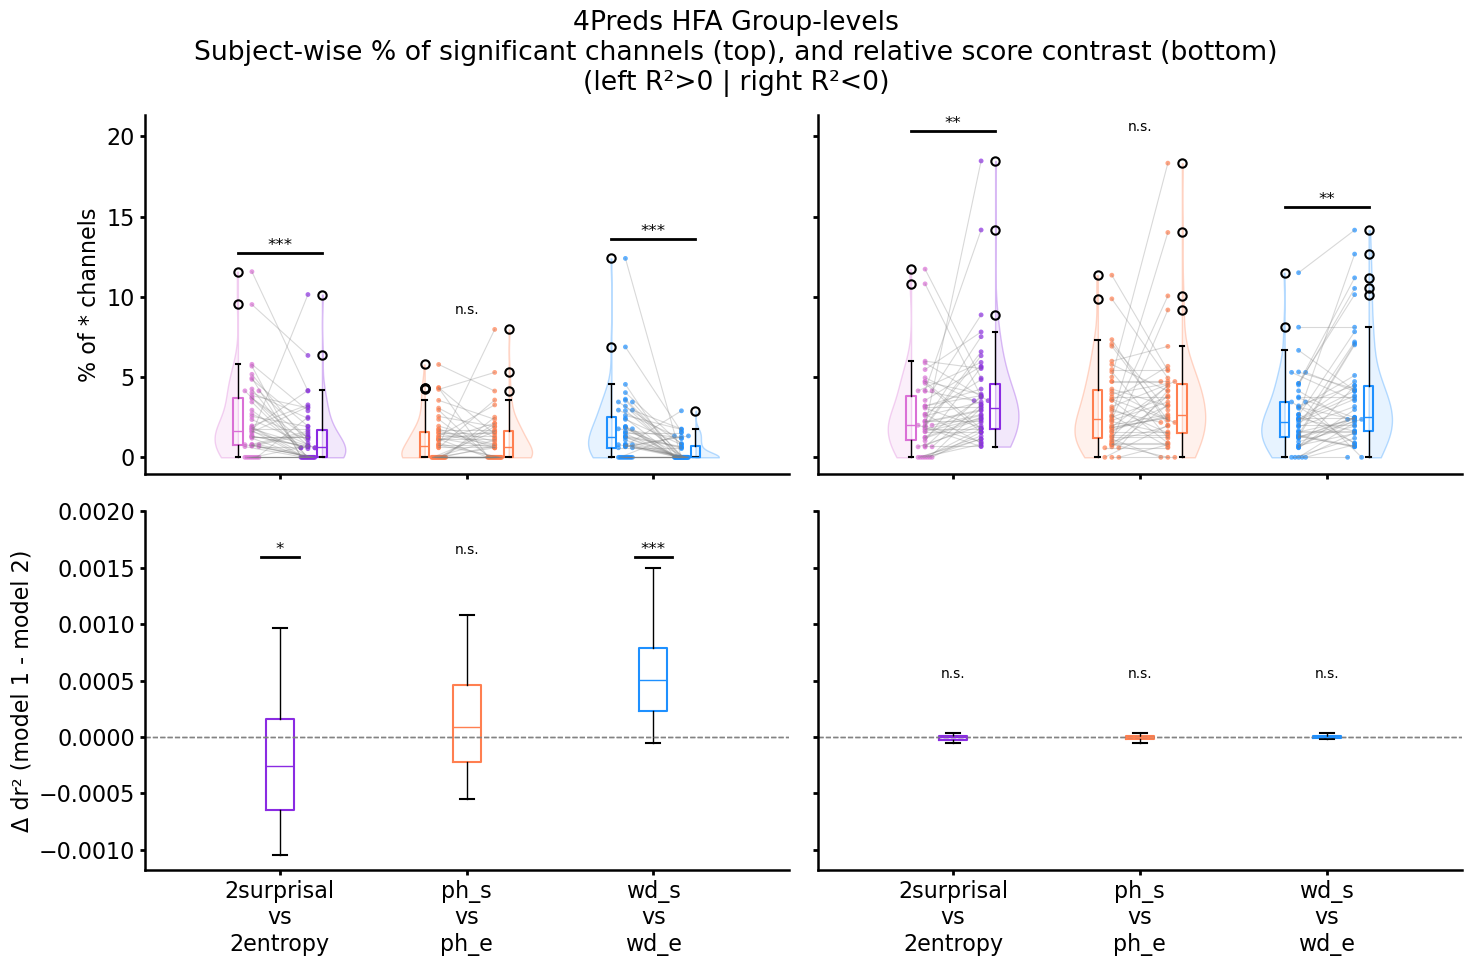

In [23]:
pairs = [['2surprisal', '2entropy'], ['phoneme\nsurprisal', 'phoneme\nentropy'], ['word\nsurprisal', 'word\nentropy']]
pairs_labels = [['2surprisal', '2entropy'], ['ph_s', 'ph_e'], ['wd_s', 'wd_e']]

x_ticks_positions = np.arange(len(pairs))
x_ticks_labels = [f'{m1}\nvs\n{m2}' for (m1, m2) in pairs_labels]
inter_pair_gap = .45

f,ax = plt.subplots(2,2, figsize=(15, 10), sharex=True, sharey='row') #, sharey='row')

for i_m, (m1, m2) in enumerate(pairs):

    for acou in ['acou_pos', 'acou_neg']:

        if acou == 'acou_pos':
            i_acou = 0
        else:
            i_acou = 1

        # get data
        prop_1 = dico_4preds_hfa_by_cluster[acou][m1]['proportion']
        prop_2 = dico_4preds_hfa_by_cluster[acou][m2]['proportion']

        dr2_1 = dico_4preds_hfa_by_cluster[acou][m1]['dr2']
        dr2_2 = dico_4preds_hfa_by_cluster[acou][m2]['dr2']
        contrast_dr2 = filter_nans(dr2_1 - dr2_2)

        # plot pair
        plot_pair_violinboxscatter(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, colors_4preds[m1], colors_4preds[m2], inter_pair_gap=0.15)
        plot_statistical_comparison(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, test_func=wilcoxon)

        # plot single boxplot for dr2 contrast
        bp = ax[1, i_acou].boxplot(
            contrast_dr2,
            positions=[x_ticks_positions[i_m]],
            widths=0.15,
            boxprops=dict(color=colors_4preds[m2]),
            medianprops=dict(color=colors_4preds[m2]),
            whiskerprops=dict(color='k'),
            capprops=dict(color='k'),
            showfliers=False
        )
        ax[1, i_acou].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        # ax[1,i_acou].set_ylim((-0.005, 0.005))

        # add statistical comparison for dr2 contrast
        plot_statistical_comparison(ax=ax[1,i_acou], data_1=contrast_dr2, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=[0.0016, 0.0005][i_acou])

ax[1,0].set_ylim((None, 0.0020))        

for i in range(2):
    for j in range(2):
        ax[j,i].spines[['top', 'right']].set_visible(False)
    ax[0,i].set_xticks([])
    # ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
    ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
# ax[0,0].set_ylabel('# of * channels')
ax[0,0].set_ylabel('% of * channels')
ax[1,0].set_ylabel('Δ dr² (model 1 - model 2)')

# ax[0,0].sharey(ax[0,1])

f.suptitle(f'4Preds HFA Group-levels\nSubject-wise % of significant channels (top), and relative score contrast (bottom)\n(left R²>0 | right R²<0)', y=.97);
f.tight_layout()

In [ ]:
masks_6

[{0.01: array([False, False, False, ..., False, False, False]),
  0.005: array([False, False, False, ..., False, False, False]),
  0.001: array([False, False, False, ..., False, False, False])},
 {0.01: array([False, False, False, ..., False, False, False]),
  0.005: array([False, False, False, ..., False, False, False]),
  0.001: array([False, False, False, ..., False, False, False])},
 {0.01: array([False, False, False, ..., False, False, False]),
  0.005: array([False, False, False, ..., False, False, False]),
  0.001: array([False, False, False, ..., False, False, False])},
 {0.01: array([False, False, False, ..., False, False,  True]),
  0.005: array([False, False, False, ..., False, False,  True]),
  0.001: array([False, False, False, ..., False, False,  True])},
 {0.01: array([False, False, False, ..., False, False, False]),
  0.005: array([False, False, False, ..., False, False, False]),
  0.001: array([False, False, False, ..., False, False, False])},
 {0.01: array([False, Fal

In [136]:
### brain plots

to_plot =  ['syllable\nsurprisal', 'syllable\nentropy']  # ['phoneme\nsurprisal', 'phoneme\nentropy', 'word\nsurprisal', 'word\nentropy']  # , 'phoneme\nsurprisal', 'phoneme\nentropy']
for m in to_plot:
    for mas in ['acou_pos', 'acou_neg']:
        mask = dico_6preds_hfa[m]['mask'][p] & (mask_6preds_acou_pos_hfa if mas == 'acou_pos' else mask_6preds_acou_neg_hfa)
        locs = all_locs[mask, :]
        locs[locs[:,0]>0,0] *= -1 
        chans = all_chans[mask]
        s = dico_6preds_hfa[m]['dr2'][mask]
        s_max = np.max(s)
        s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

        viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=chans, background='white', min_scores=0, cmap=brain_plots_cmaps[m.split('\n')[0]], close=False, fig_label=f'dr² {m.replace("\n", " ")}, {mas} HFA\nN={sum(mask)}               max dr² = {s_max:.4f}', hems = ['lh'],
        add_axes=True, axes_position='lower_left', axes_scale=0.2);  # , hems = ['both']

NameError: name 'mask_6preds_acou_pos_hfa' is not defined

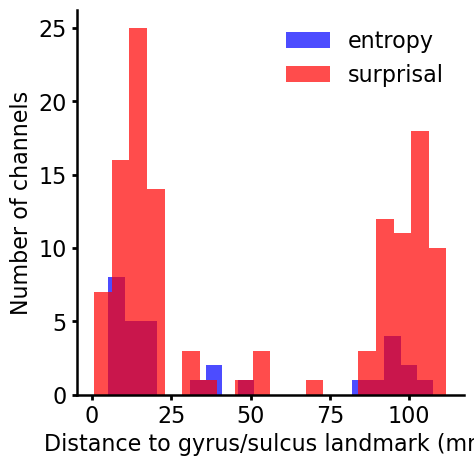

In [ ]:
a  = dico_4preds_hfa['word\nentropy']['mask'][p] & (mask_4preds_acou_pos_hfa)
b  = dico_4preds_hfa['word\nsurprisal']['mask'][p] & (mask_4preds_acou_pos_hfa)
locsa = all_locs[a, :]
locsb = all_locs[b, :]

gs =[-45,-30,10]
da = (locsa - np.asarray(gs))**2
db = (locsb - np.asarray(gs))**2
da = np.sqrt(np.sum(da[:,[0,2]], axis=1))
db = np.sqrt(np.sum(db[:,[0,2]], axis=1))
plt.figure()
plt.hist(da, bins=20, alpha=0.7, label='entropy')
plt.hist(db, bins=20, alpha=0.7, label='surprisal')
plt.xlabel('Distance to gyrus/sulcus landmark (mm)')
plt.ylabel('Number of channels')
plt.legend()

### 6Preds HFa
exactly the same as above, but with 2 additional syllabic regressors

#### Mise en place

In [ ]:
########
### Old
########

# ### same for predictive features
# # load pred files
# pred_results_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/broadband/data/bb_clem_permuts_6preds/'

# subjects_preds = np.load(os.path.join(pred_results_path, 'subjects.npy'))  # subject list
# print(f'Subjects included in predictive features analysis :  {subjects_preds.shape[0]}\n{subjects_preds}')
# rejected_subj_mask_preds = [True if s not in excluded_subjects else False for s in subjects_preds]

# data_permuts_preds = np.load(os.path.join(pred_results_path, 'r2_full_perm.npy'))[rejected_subj_mask_preds, :]  # loading r² w/ and w/o predictive features permutations
# print('Scores with permutations shape : ', data_permuts_preds.shape)
# data_preds = np.load(os.path.join(pred_results_path, 'r2_full_true.npy'))[rejected_subj_mask_preds, :]
# data_controls_preds = np.load(os.path.join(pred_results_path, 'r2_reduced_true.npy'))[rejected_subj_mask_preds, :]

# data_preds = from_bn_to_clem(pd.DataFrame(data_preds))  # transformation to clem format
# data_controls_preds = from_bn_to_clem(pd.DataFrame(data_controls_preds))

# # define thresholds
# pvals_preds = [0.01, 0.005, 0.001]
# thresholds_preds = {p: np.percentile(data_permuts_preds, 100*(1-p), axis=2) for p in pvals_preds}
# array_thresholds_preds = {p: from_bn_to_clem(pd.DataFrame(thresholds_preds[p])) for p in pvals_preds}
# print(array_thresholds_preds[0.001].shape)

# masks_preds = {p: data_preds >= array_thresholds_preds[p] for p in pvals_preds}  # create masks for each p-value

# dr2_preds = data_preds - data_controls_preds  # difference in r² between full and reduced model

In [257]:
path_6preds = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/100permut_6preds'

## load and build from full model (CAUTION : here, full model comes from the 1000 permutations on 6preds)
masks_6preds_hfa, full_6preds_hfa, data_controls_6preds_hfa = load_and_process(hfa_6preds_results_path, rejected_subj_mask_6preds, pvals)
dr2_6preds_hfa = full_6preds_hfa - data_controls_6preds_hfa  # difference in r² between full and reduced model
mask_6preds_acou_pos_hfa = data_controls_6preds_hfa > 0  # acoustic positive mask
mask_6preds_acou_neg_hfa = data_controls_6preds_hfa < 0  # acoustic negative mask

# load each model of the (phoneme + syllable + word) * (entropy + surprise) design
masks_6preds_phE_hfa, _, data_controls_6preds_phE_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_pe'), rejected_subj_mask_6preds, pvals)
masks_6preds_phS_hfa, _, data_controls_6preds_phS_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_ps'), rejected_subj_mask_6preds, pvals)

masks_6preds_syE_hfa, _, data_controls_6preds_syE_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_se'), rejected_subj_mask_6preds, pvals)
masks_6preds_syS_hfa, _, data_controls_6preds_syS_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_ss'), rejected_subj_mask_6preds, pvals)

masks_6preds_wdE_hfa, _, data_controls_6preds_wdE_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_we'), rejected_subj_mask_6preds, pvals) 
masks_6preds_wdS_hfa, _, data_controls_6preds_wdS_hfa = load_and_process(os.path.join(path_6preds, 'HFa_100Hz_permuts_5acc3ons6preds_ws'), rejected_subj_mask_6preds, pvals) 

# compute dr² for each model
dr2_6preds_phE_hfa = full_6preds_hfa - data_controls_6preds_phE_hfa
dr2_6preds_phS_hfa = full_6preds_hfa - data_controls_6preds_phS_hfa
dr2_6preds_syE_hfa = full_6preds_hfa - data_controls_6preds_syE_hfa
dr2_6preds_syS_hfa = full_6preds_hfa - data_controls_6preds_syS_hfa
dr2_6preds_wdE_hfa = full_6preds_hfa - data_controls_6preds_wdE_hfa
dr2_6preds_wdS_hfa = full_6preds_hfa - data_controls_6preds_wdS_hfa


# instantiate moodel dico for 4preds_hfa
#################### should be sorted (model names, masks and scores in the same order) ####################
dico_6preds_hfa = {}
models_6preds = ['6preds', 'phoneme\nsurprisal', 'phoneme\nentropy', 'syllable\nsurprisal', 'syllable\nentropy', 'word\nsurprisal', 'word\nentropy']
masks_6preds_hfa = [masks_6preds_hfa, masks_6preds_phS_hfa, masks_6preds_phE_hfa, masks_6preds_syS_hfa, masks_6preds_syE_hfa, masks_6preds_wdS_hfa, masks_6preds_wdE_hfa]
dr2_models_6preds_hfa = [dr2_6preds_hfa, dr2_6preds_phS_hfa, dr2_6preds_phE_hfa, dr2_6preds_syS_hfa, dr2_6preds_syE_hfa, dr2_6preds_wdS_hfa, dr2_6preds_wdE_hfa]

# fill handy dico with masks and scores
for i, m in enumerate(models_6preds):
    dico_6preds_hfa[m] = {}
    dico_6preds_hfa[m]['mask'] = masks_6preds_hfa[i]
    dico_6preds_hfa[m]['dr2'] = dr2_models_6preds_hfa[i]

    # add computation of subject-wise metrics
    n, proportion, dr2 = [], [], []
    mask = dico_6preds_hfa[m]['mask'][p]
    m_chans = all_chans[mask]

    subject_in_pool, n_by_subject_in_pool = my_utils.from_chname_to_subjects(m_chans)

    for id in subjects_ids:
        s_chans = np.array([ch for ch in all_chans if id in ch])

        if id not in subject_in_pool:
            n.append(0)
            proportion.append(0)
            dr2.append(np.nan)
        else:
            i_subj = subject_in_pool.index(id)
            n.append(n_by_subject_in_pool[i_subj])
            proportion.append(n_by_subject_in_pool[i_subj] / s_chans.shape[0])  # normalizing by the total number of channels for that subject (* and n.s.)
            ch_subj = [ch__name for ch__name in m_chans if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  # select all channels for that subject
            dr2.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]))  # average dr² for that subject's channels

    # fill up dico
    dico_6preds_hfa[m]['n_subject_avg'] = np.asarray(n)
    dico_6preds_hfa[m]['proportion_subject_avg'] = np.asarray(proportion)[~np.isnan(np.asarray(proportion))]
    dico_6preds_hfa[m]['dr2_subject_avg'] = np.asarray(dr2)

### build the data to compare models between acoustic and non-acoustic clusters
dico_6preds_hfa_by_cluster = {'acou_pos': {}, 'acou_neg': {}}
for i_m, m in enumerate(models_6preds):
    # init lists
    n_pos = []  # number of significant channels by subject
    proportion_pos = []  # proportion of significant channels by subject (within cluster / total * channels)
    dr2_pos = []  # avg relative score by subject
    dr2_prop_pos = []  # avg relative score by subject, weighted by proportion of total explained variance
    n_neg, proportion_neg, dr2_neg, dr2_prop_neg = [], [], [], []  # init lists for acoustic clusters

    mask = dico_6preds_hfa[m]['mask'][p]  # overall mask by model
    mask_pos = mask & mask_6preds_acou_pos_hfa
    mask_neg = mask & mask_6preds_acou_neg_hfa

    selected_chans_pos = all_chans[mask_pos]
    selected_chans_neg = all_chans[mask_neg]

    subject_in_pos, n_by_subject_pos = my_utils.from_chname_to_subjects(selected_chans_pos)
    subject_in_neg, n_by_subject_neg = my_utils.from_chname_to_subjects(selected_chans_neg)
    
    # browse through subjects to build pos, then neg
    for id in subjects_ids:
        # mask to get all channels for that subject
        s_chans = np.array([ch for ch in all_chans if id in ch])

        if id not in subject_in_pos:
            n_pos.append(0)
            proportion_pos.append(0)
            dr2_pos.append(np.nan)
            dr2_prop_pos.append(np.nan)
        else:
            i_subj = subject_in_pos.index(id)
            n_pos.append(n_by_subject_pos[i_subj])
            proportion_pos.append(n_by_subject_pos[i_subj] / s_chans.shape[0])  # normalizing by the total number of channels for that subject (* and n.s.)
            ch_subj = [ch__name for ch__name in selected_chans_pos if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  # select all channels for that subject
            dr2_pos.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]))  # average dr² for that subject's channels
            dr2_prop_pos.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]/full_6preds_hfa[mono_subj_mask]))  # average total score proportion for that subject's channels

        if id not in subject_in_neg:
            n_neg.append(0)
            proportion_neg.append(0)
            dr2_neg.append(np.nan)
            dr2_prop_neg.append(np.nan)
        else:
            i_subj = subject_in_neg.index(id)
            n_neg.append(n_by_subject_neg[i_subj])
            proportion_neg.append(n_by_subject_neg[i_subj] / s_chans.shape[0])
            ch_subj = [ch__name for ch__name in selected_chans_neg if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  
            dr2_neg.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]))
            dr2_prop_neg.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]/full_6preds_hfa[mono_subj_mask]))

    # fill dico
    dico_6preds_hfa_by_cluster['acou_pos'][m] = {}
    dico_6preds_hfa_by_cluster['acou_pos'][m]['n'] = np.asarray(n_pos)
    dico_6preds_hfa_by_cluster['acou_pos'][m]['proportion'] = np.array(proportion_pos)[~np.isnan(proportion_pos)]
    dico_6preds_hfa_by_cluster['acou_pos'][m]['dr2'] = np.asarray(dr2_pos)
    dico_6preds_hfa_by_cluster['acou_pos'][m]['dr2_prop'] = np.asarray(dr2_prop_pos)    
    dico_6preds_hfa_by_cluster['acou_pos'][m]['names'] = all_chans[mask_pos]

    dico_6preds_hfa_by_cluster['acou_neg'][m] = {}
    dico_6preds_hfa_by_cluster['acou_neg'][m]['n'] = np.asarray(n_neg)
    dico_6preds_hfa_by_cluster['acou_neg'][m]['proportion'] = np.array(proportion_neg)[~np.isnan(proportion_neg)]
    dico_6preds_hfa_by_cluster['acou_neg'][m]['dr2'] = np.asarray(dr2_neg)  
    dico_6preds_hfa_by_cluster['acou_neg'][m]['dr2_prop'] = np.asarray(dr2_prop_neg)
    dico_6preds_hfa_by_cluster['acou_neg'][m]['names'] = all_chans[mask_neg]    

# display the number of stat channels, model and cluster-wise
for i_am,am in enumerate([mask_6preds_acou_neg_hfa, mask_6preds_acou_pos_hfa]):

    print(['acou_neg', 'acou_pos'][i_am].upper())
    for m in models_6preds:
        mask = dico_6preds_hfa[m]['mask'][p] & am
        print(f'{m} | * channels (p<{p}) : {np.sum(mask)} / {sum(dico_6preds_hfa[m]["mask"][p])}')
    print('\n')



ACOU_NEG
6preds | * channels (p<0.001) : 193 / 347
phoneme
surprisal | * channels (p<0.001) : 214 / 251
phoneme
entropy | * channels (p<0.001) : 252 / 298
syllable
surprisal | * channels (p<0.001) : 181 / 216
syllable
entropy | * channels (p<0.001) : 183 / 198
word
surprisal | * channels (p<0.001) : 179 / 306
word
entropy | * channels (p<0.001) : 275 / 311


ACOU_POS
6preds | * channels (p<0.001) : 154 / 347
phoneme
surprisal | * channels (p<0.001) : 37 / 251
phoneme
entropy | * channels (p<0.001) : 46 / 298
syllable
surprisal | * channels (p<0.001) : 35 / 216
syllable
entropy | * channels (p<0.001) : 15 / 198
word
surprisal | * channels (p<0.001) : 127 / 306
word
entropy | * channels (p<0.001) : 36 / 311




#### Figures

##### Brain Plots

In [ ]:
### brain plots

to_plot =  ['phoneme\nentropy']  # ['syllable\nsurprisal', 'syllable\nentropy', 'word\nsurprisal', 'word\nentropy']  # , 'phoneme\nsurprisal', 'phoneme\nentropy']
for m in to_plot:
    for mas in ['acou_pos', 'acou_neg']:
        mask = dico_6preds_hfa[m]['mask'][p] & (mask_6preds_acou_pos_hfa if mas == 'acou_pos' else mask_6preds_acou_neg_hfa)
        locs = all_locs[mask, :]
        locs[locs[:,0]>0,0] *= -1 
        chans = all_chans[mask]
        s = dico_6preds_hfa[m]['dr2'][mask]
        s_max = np.max(s)
        s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

        viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=chans, background='white', min_scores=0, cmap=brain_plots_cmaps[m.split('\n')[0]], close=False, fig_label=f'dr² {m.replace("\n", " ")}, {mas} HFA\nN={sum(mask)}               max dr² = {s_max:.4f}', hems = ['lh'],
        add_axes=True, axes_position='lower_left', axes_scale=0.2);  # , hems = ['both']

In [ ]:
### 1 brain plot by model for 6preds_hfa

for m in models_6preds:
    mask = dico_6preds_hfa[m]['mask'][p]
    locs = all_locs[mask, :]
    chans = all_chans[mask]
    s = dico_6preds_hfa[m]['dr2'][mask]
    s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

    viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=chans, background='white', min_scores=0, cmap=cmaps_6preds[m], close=False, fig_label=f'dr² {m.replace('\n', ' ')} HFA\nN={sum(mask)}');  # , hems = ['both']

##### Venn

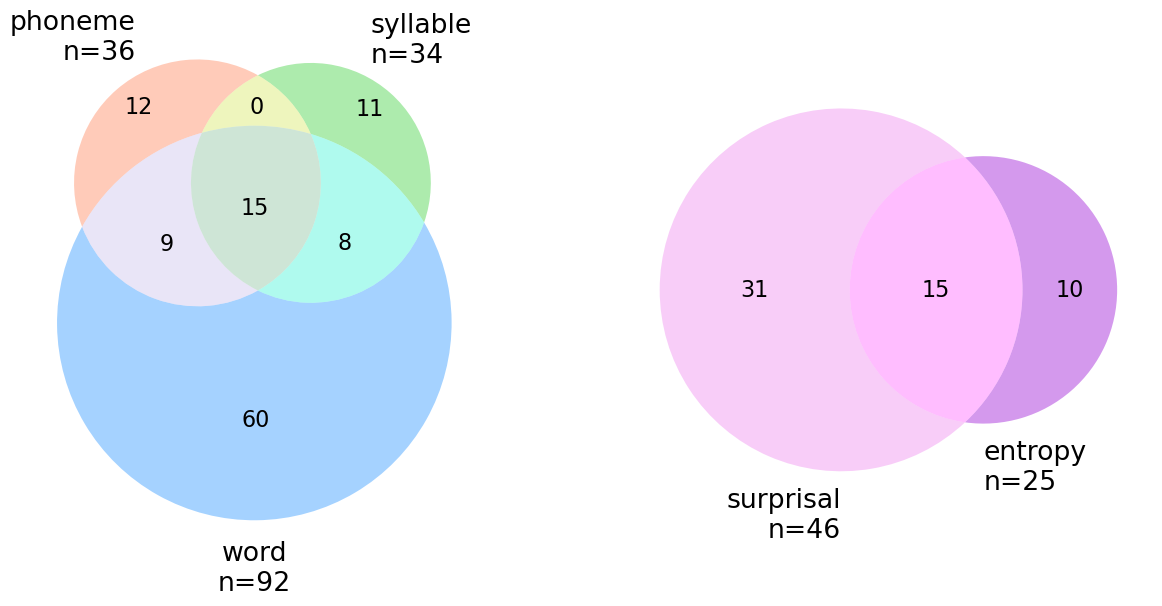

In [ ]:
# Venn diagrams : one 2venn with all phoneme, syllable, word responding channels grouped 2 by 2 (logic OR)
#                 one 3venn with Surprisal and Entropy responding channels grouped 3 by 3

# chans_3E = 

# mask_3S_HFa = dico_6preds_hfa['phoneme\nsurprisal']['mask'][p] | dico_6preds_hfa['syllable\nsurprisal']['mask'][p] | dico_6preds_hfa['word\nsurprisal']['mask'][p]
# mask_3E_HFa = dico_6preds_hfa['phoneme\nentropy']['mask'][p] | dico_6preds_hfa['syllable\nentropy']['mask'][p] | dico_6preds_hfa['word\nentropy']['mask'][p]
mask_3S_HFa = dico_6preds_hfa['phoneme\nsurprisal']['mask'][p] & dico_6preds_hfa['syllable\nsurprisal']['mask'][p] & dico_6preds_hfa['word\nsurprisal']['mask'][p]
mask_3E_HFa = dico_6preds_hfa['phoneme\nentropy']['mask'][p] & dico_6preds_hfa['syllable\nentropy']['mask'][p] & dico_6preds_hfa['word\nentropy']['mask'][p]

chans_3S_HFa = all_chans[mask_3S_HFa]
chans_3E_HFa = all_chans[mask_3E_HFa]

# mask_2ph_HFa = dico_6preds_hfa['phoneme\nentropy']['mask'][p] | dico_6preds_hfa['phoneme\nsurprisal']['mask'][p]
# mask_2sy_HFa = dico_6preds_hfa['syllable\nentropy']['mask'][p] | dico_6preds_hfa['syllable\nsurprisal']['mask'][p]
# mask_2wd_HFa = dico_6preds_hfa['word\nentropy']['mask'][p] | dico_6preds_hfa['word\nsurprisal']['mask'][p]
mask_2ph_HFa = dico_6preds_hfa['phoneme\nentropy']['mask'][p] & dico_6preds_hfa['phoneme\nsurprisal']['mask'][p]
mask_2sy_HFa = dico_6preds_hfa['syllable\nentropy']['mask'][p] & dico_6preds_hfa['syllable\nsurprisal']['mask'][p]
mask_2wd_HFa = dico_6preds_hfa['word\nentropy']['mask'][p] & dico_6preds_hfa['word\nsurprisal']['mask'][p]
chans_2ph_HFa = all_chans[mask_2ph_HFa]
chans_2sy_HFa = all_chans[mask_2sy_HFa]
chans_2wd_HFa = all_chans[mask_2wd_HFa]


fig, ax = plt.subplots(1, 2, figsize=(15, 7))

venn3([set(chans_2ph_HFa), set(chans_2sy_HFa), set(chans_2wd_HFa)], set_labels = (f'phoneme\nn={sum(mask_2ph_HFa)}', f'syllable\nn={sum(mask_2sy_HFa)}', f'word\nn={sum(mask_2wd_HFa)}'), ax=ax[0], set_colors=('coral', 'limegreen', 'dodgerblue'))

venn2([set(chans_3S_HFa), set(chans_3E_HFa)], set_labels = (f'surprisal\nn={sum(mask_3S_HFa)}', f'entropy\nn={sum(mask_3E_HFa)}'), ax=ax[1], set_colors=('violet', 'darkviolet'))

##### Score plots

Text(0.5, 1.08, 'HFa Group-level\n% and dr² of significant channels')

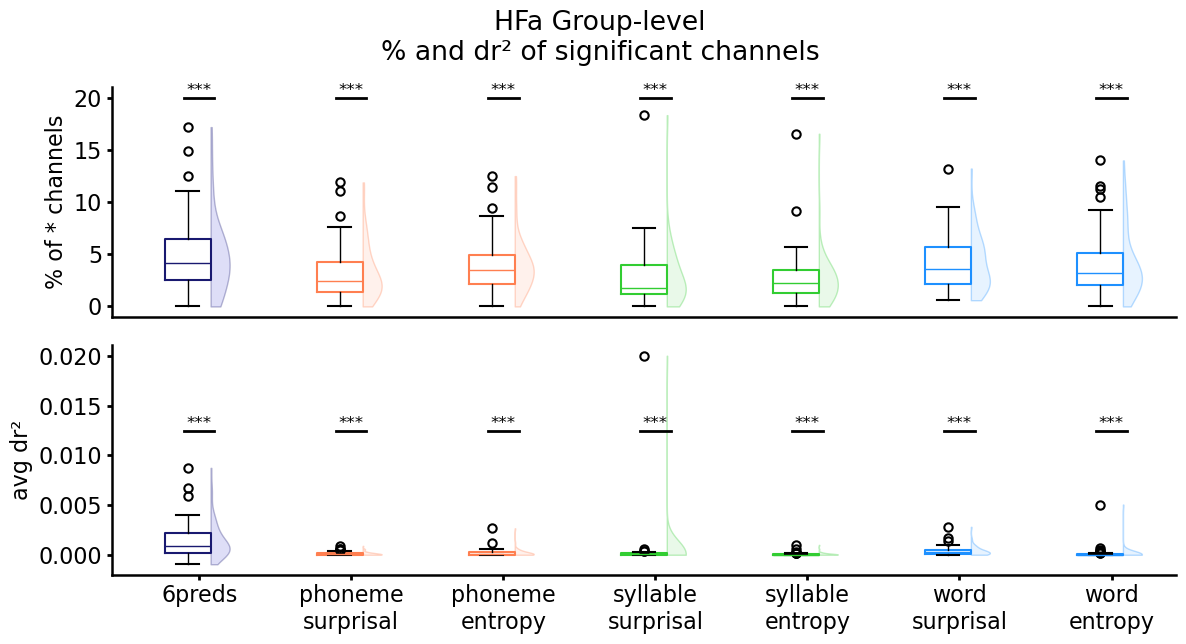

In [318]:
### for each model of 6preds, plot boxplot + scatter + violin with stat

f, ax = plt.subplots(2, 1, figsize=(12, 6))
x_ticks_positions = np.arange(len(models_6preds))
inter_gap = 0.15

for i_m, m in enumerate(models_6preds):

    scores = filter_nans(dico_6preds_hfa[m]['dr2_subject_avg'])
    prop = dico_6preds_hfa[m]['proportion_subject_avg']
    for i in range(2):
        data = [prop, scores][i]
        if i==0: data = data*100
        # ax[i].scatter(np.full(len(data), x_ticks_positions[i_m]), data, color=colors_6preds[m], alpha=0.5, showmeans=False, showmedians=False)
        ax[i].boxplot(data, positions=np.array([x_ticks_positions[i_m]])-inter_gap/2, widths=0.3, boxprops=dict(color=colors_6preds[m]), medianprops=dict(color=colors_6preds[m]))
        parts1 = ax[i].violinplot(data, positions=np.array([x_ticks_positions[i_m]])+inter_gap/2, showmeans=False, showmedians=False, showextrema=False, side='high', widths=0.25)
        for pc in parts1['bodies']:
            pc.set_facecolor(lighten_color(colors_6preds[m], .35))
            pc.set_edgecolor(colors_6preds[m])
            pc.set_alpha(0.3)
        
        plot_statistical_comparison(ax=ax[i], data_1=data, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=[20, 0.0125][i])
    

# spines and ticks
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
ax[0].set_ylabel('% of * channels')
ax[1].set_ylabel('avg dr²')
ax[0].set_xticks([])
ax[1].set_xticks(x_ticks_positions)
ax[1].set_xticklabels(models_6preds)

f.tight_layout()
f.suptitle('HFa Group-level\n% and dr² of significant channels', y=1.08)

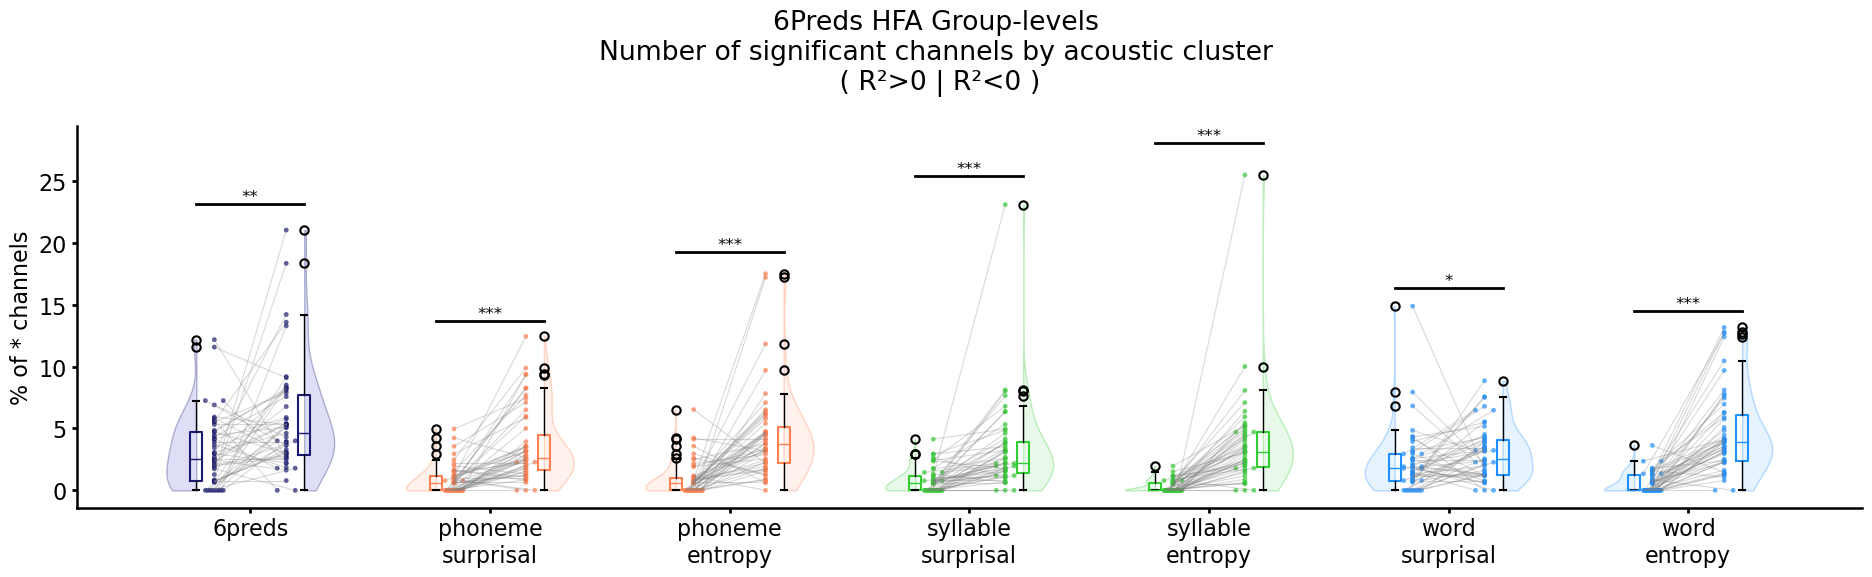

In [167]:
%matplotlib inline

x_ticks_positions = np.arange(len(models_6preds))
pos_neg_gap = 0.45
f, ax = plt.subplots(1, 1, figsize=(19, 6), sharex=True);

for i_m, m in enumerate(models_6preds):


    proportion_pos = dico_6preds_hfa_by_cluster['acou_pos'][m]['proportion']
    proportion_neg = dico_6preds_hfa_by_cluster['acou_neg'][m]['proportion']

    plot_pair_violinboxscatter(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_6preds[m], colors_6preds[m], inter_pair_gap=0.15)
    plot_statistical_comparison(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=wilcoxon)

    # n_pos = dico_6preds_hfa_by_cluster['acou_pos'][m]['n']
    # n_neg = dico_6preds_hfa_by_cluster['acou_neg'][m]['n']

    # plot_pair_violinboxscatter(ax, n_pos, n_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_6preds[m], colors_6preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax, n_pos, n_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=wilcoxon)



    # dr2_prop_pos = dico_4preds_hfa_by_cluster['acou_pos'][m]['dr2_prop']
    # dr2_prop_neg = dico_4preds_hfa_by_cluster['acou_neg'][m]['dr2_prop']

    # plot_pair_violinboxscatter(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

    dr2_pos = dico_6preds_hfa_by_cluster['acou_pos'][m]['dr2']
    dr2_neg = dico_6preds_hfa_by_cluster['acou_neg'][m]['dr2']

    # plot_pair_violinboxscatter(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

# ticks and spines
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(x_ticks_positions, models_6preds)
ax.set_ylabel('% of * channels')
f.suptitle(f'6Preds HFA Group-levels\nNumber of significant channels by acoustic cluster\n ( R²>0 | R²<0 )', y=.97);
f.tight_layout()



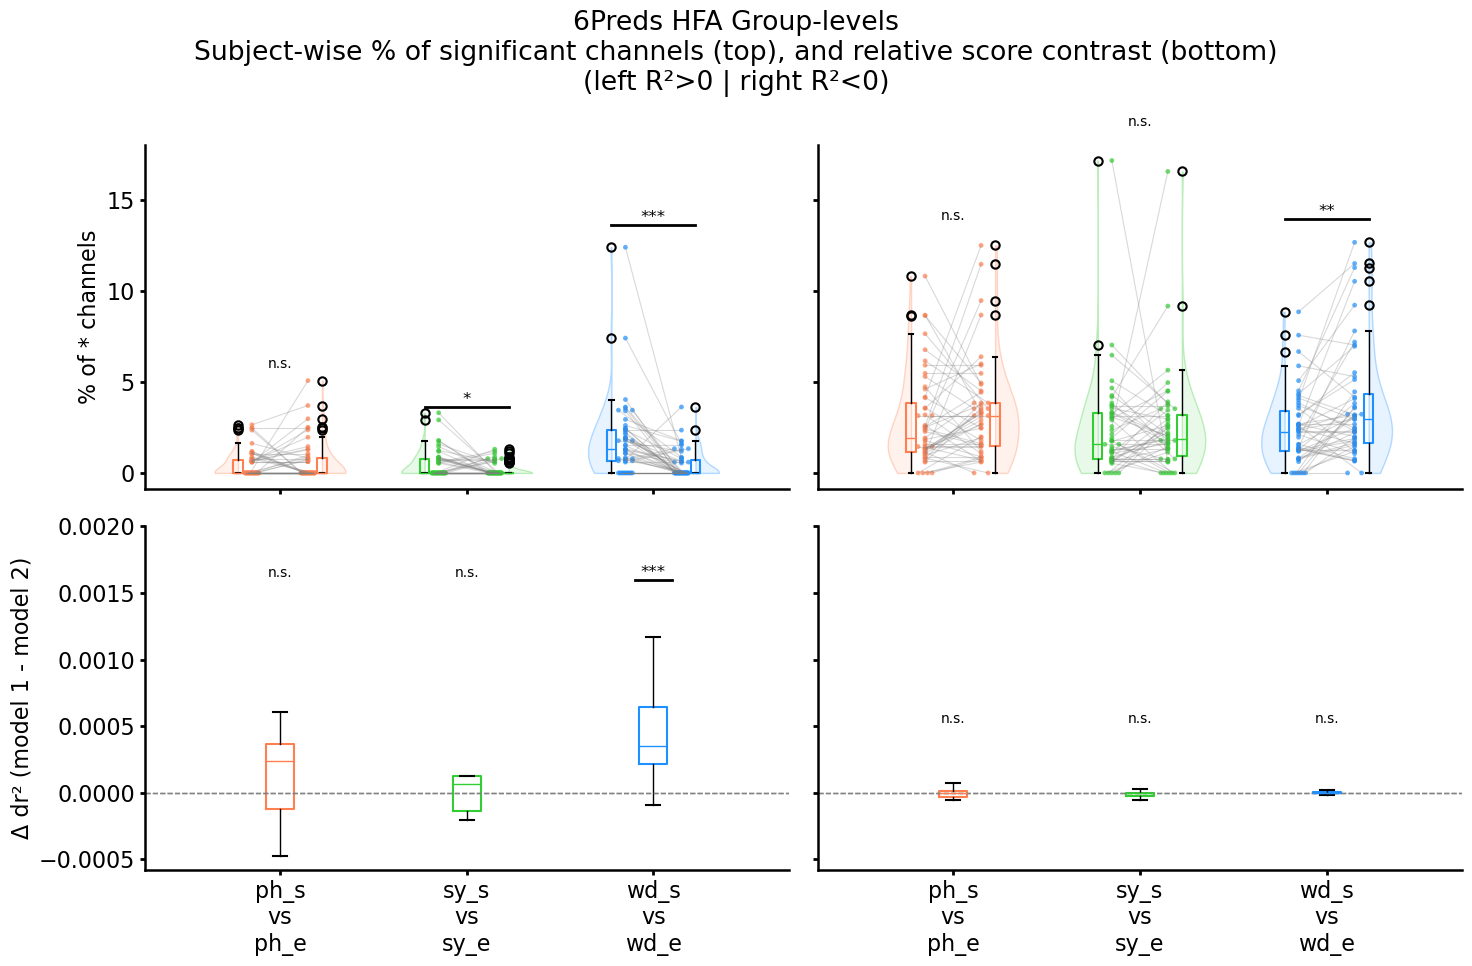

In [ ]:
pairs = [['phoneme\nsurprisal', 'phoneme\nentropy'], ['syllable\nsurprisal', 'syllable\nentropy'], ['word\nsurprisal', 'word\nentropy']]
pairs_labels = [['ph_s', 'ph_e'], ['sy_s', 'sy_e'], ['wd_s', 'wd_e']]

x_ticks_positions = np.arange(len(pairs))
x_ticks_labels = [f'{m1}\nvs\n{m2}' for (m1, m2) in pairs_labels]
inter_pair_gap = .45

f,ax = plt.subplots(2,2, figsize=(15, 10), sharex=True, sharey='row') #, sharey='row')

for i_m, (m1, m2) in enumerate(pairs):

    for acou in ['acou_pos', 'acou_neg']:

        if acou == 'acou_pos':
            i_acou = 0
        else:
            i_acou = 1

        # get data
        prop_1 = dico_6preds_hfa_by_cluster[acou][m1]['proportion']
        prop_2 = dico_6preds_hfa_by_cluster[acou][m2]['proportion']

        dr2_1 = dico_6preds_hfa_by_cluster[acou][m1]['dr2']
        dr2_2 = dico_6preds_hfa_by_cluster[acou][m2]['dr2']
        contrast_dr2 = filter_nans(dr2_1 - dr2_2)

        # plot pair
        plot_pair_violinboxscatter(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, colors_6preds[m1], colors_6preds[m2], inter_pair_gap=0.15)
        plot_statistical_comparison(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, test_func=wilcoxon)

        # plot single boxplot for dr2 contrast
        bp = ax[1, i_acou].boxplot(
            contrast_dr2,
            positions=[x_ticks_positions[i_m]],
            widths=0.15,
            boxprops=dict(color=colors_6preds[m2]),
            medianprops=dict(color=colors_6preds[m2]),
            whiskerprops=dict(color='k'),
            capprops=dict(color='k'),
            showfliers=False
        )
        ax[1, i_acou].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        # ax[1,i_acou].set_ylim((-0.005, 0.005))

        # add statistical comparison for dr2 contrast
        plot_statistical_comparison(ax=ax[1,i_acou], data_1=contrast_dr2, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=[0.0016, 0.0005][i_acou])

ax[1,0].set_ylim((None, 0.0020))        

for i in range(2):
    for j in range(2):
        ax[j,i].spines[['top', 'right']].set_visible(False)
    ax[0,i].set_xticks([])
    # ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
    ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
# ax[0,0].set_ylabel('# of * channels')
ax[0,0].set_ylabel('% of * channels')
ax[1,0].set_ylabel('Δ dr² (model 1 - model 2)')

# ax[0,0].sharey(ax[0,1])

f.suptitle(f'6Preds HFA Group-levels\nSubject-wise % of significant channels (top), and relative score contrast (bottom)\n(left R²>0 | right R²<0)', y=.97);
f.tight_layout()

/tmp/ipykernel_6771/3061688260.py:36: RuntimeWarning: Mean of empty slice
  dr2_m2_avg = np.nanmean(dr2_m2[mask2_subj])
/tmp/ipykernel_6771/3061688260.py:35: RuntimeWarning: Mean of empty slice
  dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
/tmp/ipykernel_6771/3061688260.py:35: RuntimeWarning: Mean of empty slice
  dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
/tmp/ipykernel_6771/3061688260.py:35: RuntimeWarning: Mean of empty slice
  dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
/tmp/ipykernel_6771/3061688260.py:36: RuntimeWarning: Mean of empty slice
  dr2_m2_avg = np.nanmean(dr2_m2[mask2_subj])
/tmp/ipykernel_6771/3061688260.py:36: RuntimeWarning: Mean of empty slice
  dr2_m2_avg = np.nanmean(dr2_m2[mask2_subj])
/tmp/ipykernel_6771/3061688260.py:35: RuntimeWarning: Mean of empty slice
  dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
/tmp/ipykernel_6771/3061688260.py:35: RuntimeWarning: Mean of empty slice
  dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
/tmp/ipykernel_6771/3061688260.py:35: Ru

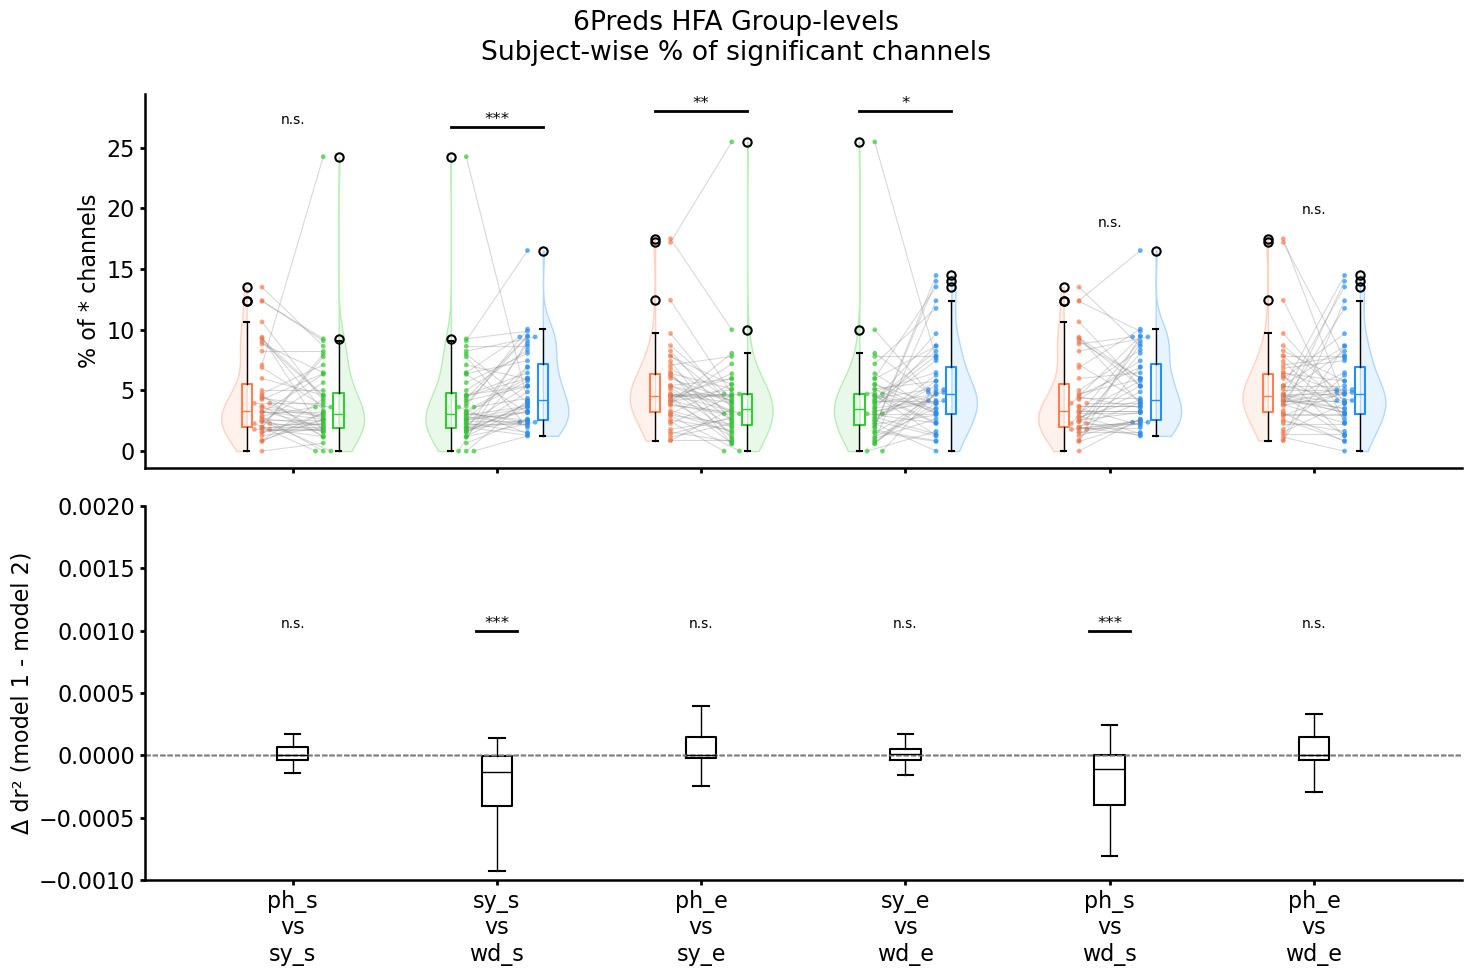

In [228]:
### Compare syl regressors to all others 

pairs = [['phoneme\nsurprisal', 'syllable\nsurprisal'], ['syllable\nsurprisal', 'word\nsurprisal'], ['phoneme\nentropy', 'syllable\nentropy'], ['syllable\nentropy', 'word\nentropy'], ['phoneme\nsurprisal', 'word\nsurprisal'], ['phoneme\nentropy', 'word\nentropy']]
pairs_labels = [['ph_s', 'sy_s'], ['sy_s', 'wd_s'], ['ph_e', 'sy_e'], ['sy_e', 'wd_e'], ['ph_s', 'wd_s'], ['ph_e', 'wd_e']]

x_ticks_positions = np.arange(len(pairs))
x_ticks_labels = [f'{m1}\nvs\n{m2}' for (m1, m2) in pairs_labels]
inter_pair_gap = .45

f,ax = plt.subplots(2,1, figsize=(15, 10), sharex=True, sharey='row') #, sharey='row')

for i_m, (m1, m2) in enumerate(pairs):

    # get data
    prop_1 = dico_6preds_hfa_by_cluster['acou_pos'][m1]['proportion'] + dico_6preds_hfa_by_cluster['acou_neg'][m1]['proportion']
    prop_2 = dico_6preds_hfa_by_cluster['acou_pos'][m2]['proportion'] + dico_6preds_hfa_by_cluster['acou_neg'][m2]['proportion']

    # plot pair
    plot_pair_violinboxscatter(ax[0], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, colors_6preds[m1], colors_6preds[m2], inter_pair_gap=0.15)
    plot_statistical_comparison(ax[0], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, test_func=wilcoxon)


    # selection of stat scores for a model
    dr2_m1 = dico_6preds_hfa[m1]['dr2'][dico_6preds_hfa[m1]['mask'][p]]
    dr2_m2 = dico_6preds_hfa[m2]['dr2'][dico_6preds_hfa[m2]['mask'][p]]
    ch_m1 = all_chans[dico_6preds_hfa[m1]['mask'][p]]
    ch_m2 = all_chans[dico_6preds_hfa[m2]['mask'][p]]

    dr2_avg_across_subjects = []  # init
    # selection of stat scores for 1 subject
    for i_s, s in enumerate(subjects_ids):
        mask1_subj = [s in ch for ch in ch_m1]
        mask2_subj = [s in ch for ch in ch_m2]
        # print(sum(mask_subj))
        dr2_m1_avg = np.nanmean(dr2_m1[mask1_subj])
        dr2_m2_avg = np.nanmean(dr2_m2[mask2_subj])
        dr2_avg_across_subjects.append(dr2_m1_avg - dr2_m2_avg)


    # # plot single boxplot for dr2 contrast
    bp = ax[1].boxplot(
        filter_nans(dr2_avg_across_subjects),
        positions=[x_ticks_positions[i_m]],
        widths=0.15,
        boxprops=dict(color='k'),
        medianprops=dict(color='k'),
        whiskerprops=dict(color='k'),
        capprops=dict(color='k'),
        showfliers=False
    )
    ax[1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax[1].set_ylim((-0.001, 0.002))

    # add statistical comparison for dr2 contrast
    plot_statistical_comparison(ax=ax[1], data_1=dr2_avg_across_subjects, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=0.001)

     
ax[0].set_xticks([])
ax[1].set_xticks(x_ticks_positions, x_ticks_labels)


ax[0].set_ylabel('% of * channels')
ax[1].set_ylabel('Δ dr² (model 1 - model 2)')

# ax[0,0].sharey(ax[0,1])

f.suptitle(f'6Preds HFA Group-levels\nSubject-wise % of significant channels') #, and relative score contrast (bottom)\n(left R²>0 | right R²<0)', y=.97);
f.tight_layout()

### 6preds broadband
exactly the same as above, but for broad band

#### Mise en place

In [320]:
path_6preds = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/permutations/100permut_6preds'

## load and build from full model (CAUTION : here, full model comes from the 1000 permutations on 6preds)
masks_6preds_bb, full_6preds_bb, data_controls_6preds_bb = load_and_process(bb_6preds_results_path, rejected_subj_mask_6preds, pvals)
dr2_6preds_bb = full_6preds_bb - data_controls_6preds_bb  # difference in r² between full and reduced model
mask_6preds_acou_pos_bb = data_controls_6preds_bb > 0  # acoustic positive mask
mask_6preds_acou_neg_bb = data_controls_6preds_bb < 0  # acoustic negative mask

# load each model of the (phoneme + syllable + word) * (entropy + surprise) design
masks_6preds_phE_bb, _, data_controls_6preds_phE_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_pe'), rejected_subj_mask_6preds, pvals)
masks_6preds_phS_bb, _, data_controls_6preds_phS_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_ps'), rejected_subj_mask_6preds, pvals)

masks_6preds_syE_bb, _, data_controls_6preds_syE_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_se'), rejected_subj_mask_6preds, pvals)
masks_6preds_syS_bb, _, data_controls_6preds_syS_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_ss'), rejected_subj_mask_6preds, pvals)

masks_6preds_wdE_bb, _, data_controls_6preds_wdE_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_we'), rejected_subj_mask_6preds, pvals) 
masks_6preds_wdS_bb, _, data_controls_6preds_wdS_bb = load_and_process(os.path.join(path_6preds, 'bb_100Hz_permuts_5acc3ons6preds_ws'), rejected_subj_mask_6preds, pvals) 

# compute dr² for each model
dr2_6preds_phE_bb = full_6preds_bb - data_controls_6preds_phE_bb
dr2_6preds_phS_bb = full_6preds_bb - data_controls_6preds_phS_bb
dr2_6preds_syE_bb = full_6preds_bb - data_controls_6preds_syE_bb
dr2_6preds_syS_bb = full_6preds_bb - data_controls_6preds_syS_bb
dr2_6preds_wdE_bb = full_6preds_bb - data_controls_6preds_wdE_bb
dr2_6preds_wdS_bb = full_6preds_bb - data_controls_6preds_wdS_bb


# instantiate moodel dico for 4preds_hfa
#################### should be sorted (model names, masks and scores in the same order) ####################
dico_6preds_bb = {}
models_6preds = ['6preds', 'phoneme\nsurprisal', 'phoneme\nentropy', 'syllable\nsurprisal', 'syllable\nentropy', 'word\nsurprisal', 'word\nentropy']
masks_6preds_bb = [masks_6preds_bb, masks_6preds_phS_bb, masks_6preds_phE_bb, masks_6preds_syS_bb, masks_6preds_syE_bb, masks_6preds_wdS_bb, masks_6preds_wdE_bb]
dr2_models_6preds_bb = [dr2_6preds_bb, dr2_6preds_phS_bb, dr2_6preds_phE_bb, dr2_6preds_syS_bb, dr2_6preds_syE_bb, dr2_6preds_wdS_bb, dr2_6preds_wdE_bb]

# fill handy dico with masks and scores
for i, m in enumerate(models_6preds):
    dico_6preds_bb[m] = {}
    dico_6preds_bb[m]['mask'] = masks_6preds_bb[i]
    dico_6preds_bb[m]['dr2'] = dr2_models_6preds_bb[i]

    # add computation of subject-wise metrics
    n, proportion, dr2 = [], [], []
    mask = dico_6preds_bb[m]['mask'][p]
    m_chans = all_chans[mask]

    subject_in_pool, n_by_subject_in_pool = my_utils.from_chname_to_subjects(m_chans)

    for id in subjects_ids:
        s_chans = np.array([ch for ch in all_chans if id in ch])

        if id not in subject_in_pool:
            n.append(0)
            proportion.append(0)
            dr2.append(np.nan)
        else:
            i_subj = subject_in_pool.index(id)
            n.append(n_by_subject_in_pool[i_subj])
            proportion.append(n_by_subject_in_pool[i_subj] / s_chans.shape[0])  # normalizing by the total number of channels for that subject (* and n.s.)
            ch_subj = [ch__name for ch__name in m_chans if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  # select all channels for that subject
            dr2.append(np.nanmean(dico_6preds_bb[m]['dr2'][mono_subj_mask]))  # average dr² for that subject's channels

    # fill up dico
    dico_6preds_bb[m]['n_subject_avg'] = np.asarray(n)
    dico_6preds_bb[m]['proportion_subject_avg'] = np.asarray(proportion)[~np.isnan(np.asarray(proportion))]
    dico_6preds_bb[m]['dr2_subject_avg'] = np.asarray(dr2)


### build the data to compare models between acoustic and non-acoustic clusters
dico_6preds_bb_by_cluster = {'acou_pos': {}, 'acou_neg': {}}
for i_m, m in enumerate(models_6preds):
    # init lists
    n_pos = []  # number of significant channels by subject
    proportion_pos = []  # proportion of significant channels by subject (within cluster / total * channels)
    dr2_pos = []  # avg relative score by subject
    dr2_prop_pos = []  # avg relative score by subject, weighted by proportion of total explained variance
    n_neg, proportion_neg, dr2_neg, dr2_prop_neg = [], [], [], []  # init lists for acoustic clusters

    mask = dico_6preds_bb[m]['mask'][p]  # overall mask by model
    mask_pos = mask & mask_6preds_acou_pos_bb
    mask_neg = mask & mask_6preds_acou_neg_bb

    selected_chans_pos = all_chans[mask_pos]
    selected_chans_neg = all_chans[mask_neg]

    subject_in_pos, n_by_subject_pos = my_utils.from_chname_to_subjects(selected_chans_pos)
    subject_in_neg, n_by_subject_neg = my_utils.from_chname_to_subjects(selected_chans_neg)
    
    # browse through subjects to build pos, then neg
    for id in subjects_ids:
        # mask to get all channels for that subject
        s_chans = np.array([ch for ch in all_chans if id in ch])

        if id not in subject_in_pos:
            n_pos.append(0)
            proportion_pos.append(0)
            dr2_pos.append(np.nan)
            dr2_prop_pos.append(np.nan)
        else:
            i_subj = subject_in_pos.index(id)
            n_pos.append(n_by_subject_pos[i_subj])
            proportion_pos.append(n_by_subject_pos[i_subj] / s_chans.shape[0])  # normalizing by the total number of channels for that subject (* and n.s.)
            ch_subj = [ch__name for ch__name in selected_chans_pos if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  # select all channels for that subject
            dr2_pos.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]))  # average dr² for that subject's channels
            dr2_prop_pos.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]/full_6preds_hfa[mono_subj_mask]))  # average total score proportion for that subject's channels

        if id not in subject_in_neg:
            n_neg.append(0)
            proportion_neg.append(0)
            dr2_neg.append(np.nan)
            dr2_prop_neg.append(np.nan)
        else:
            i_subj = subject_in_neg.index(id)
            n_neg.append(n_by_subject_neg[i_subj])
            proportion_neg.append(n_by_subject_neg[i_subj] / s_chans.shape[0])
            ch_subj = [ch__name for ch__name in selected_chans_neg if id in ch__name]
            mono_subj_mask = np.isin(all_chans, ch_subj)  
            dr2_neg.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]))
            dr2_prop_neg.append(np.nanmean(dico_6preds_hfa[m]['dr2'][mono_subj_mask]/full_6preds_hfa[mono_subj_mask]))

    # fill dico
    dico_6preds_bb_by_cluster['acou_pos'][m] = {}
    dico_6preds_bb_by_cluster['acou_pos'][m]['n'] = np.asarray(n_pos)
    dico_6preds_bb_by_cluster['acou_pos'][m]['proportion'] = np.array(proportion_pos)[~np.isnan(proportion_pos)]
    dico_6preds_bb_by_cluster['acou_pos'][m]['dr2'] = np.asarray(dr2_pos)
    dico_6preds_bb_by_cluster['acou_pos'][m]['dr2_prop'] = np.asarray(dr2_prop_pos)    
    dico_6preds_bb_by_cluster['acou_pos'][m]['names'] = all_chans[mask_pos]

    dico_6preds_bb_by_cluster['acou_neg'][m] = {}
    dico_6preds_bb_by_cluster['acou_neg'][m]['n'] = np.asarray(n_neg)
    dico_6preds_bb_by_cluster['acou_neg'][m]['proportion'] = np.array(proportion_neg)[~np.isnan(proportion_neg)]
    dico_6preds_bb_by_cluster['acou_neg'][m]['dr2'] = np.asarray(dr2_neg)  
    dico_6preds_bb_by_cluster['acou_neg'][m]['dr2_prop'] = np.asarray(dr2_prop_neg)
    dico_6preds_bb_by_cluster['acou_neg'][m]['names'] = all_chans[mask_neg]    

# display the number of stat channels, model and cluster-wise
for i_am,am in enumerate([mask_6preds_acou_neg_bb, mask_6preds_acou_pos_bb]):

    print(['acou_neg', 'acou_pos'][i_am].upper())
    for m in models_6preds:
        mask = dico_6preds_bb[m]['mask'][p] & am
        print(f'{m} | * channels (p<{p}) : {np.sum(mask)} / {sum(dico_6preds_bb[m]["mask"][p])}')
    print('\n')



ACOU_NEG
6preds | * channels (p<0.001) : 82 / 758
phoneme
surprisal | * channels (p<0.001) : 52 / 198
phoneme
entropy | * channels (p<0.001) : 75 / 373
syllable
surprisal | * channels (p<0.001) : 21 / 102
syllable
entropy | * channels (p<0.001) : 30 / 119
word
surprisal | * channels (p<0.001) : 36 / 433
word
entropy | * channels (p<0.001) : 31 / 136


ACOU_POS
6preds | * channels (p<0.001) : 676 / 758
phoneme
surprisal | * channels (p<0.001) : 146 / 198
phoneme
entropy | * channels (p<0.001) : 298 / 373
syllable
surprisal | * channels (p<0.001) : 81 / 102
syllable
entropy | * channels (p<0.001) : 89 / 119
word
surprisal | * channels (p<0.001) : 397 / 433
word
entropy | * channels (p<0.001) : 105 / 136




#### Figures

##### Brain plots

/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:263: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


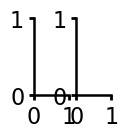

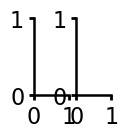

In [93]:
### 1 brain plot by model for 6preds_bb
custom_models = ['word\nentropy', 'word\nsurprisal']
for m in custom_models:
    mask = dico_6preds_bb[m]['mask'][p]
    locs = all_locs[mask, :]
    chans = all_chans[mask]
    s = dico_6preds_bb[m]['dr2'][mask]
    s = np.clip(s, a_min=0, a_max=np.percentile(s, 95))

    viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=chans, background='white', min_scores=0, cmap=cmaps_6preds[m], close=False, fig_label=f'dr² {m.replace('\n', ' ')} BroadBand\nN={sum(mask)}');  # , hems = ['both']

##### Venn

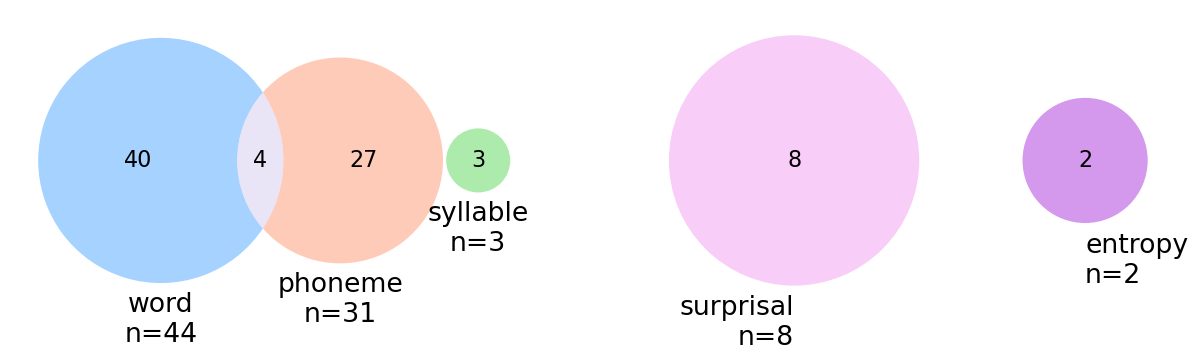

In [232]:
# venn

# mask_3S_bb = dico_6preds_bb['phoneme\nsurprisal']['mask'][p] | dico_6preds_bb['syllable\nsurprisal']['mask'][p] | dico_6preds_bb['word\nsurprisal']['mask'][p]
# mask_3E_bb = dico_6preds_bb['phoneme\nentropy']['mask'][p] | dico_6preds_bb['syllable\nentropy']['mask'][p] | dico_6preds_bb['word\nentropy']['mask'][p]
mask_3S_bb = dico_6preds_bb['phoneme\nsurprisal']['mask'][p] & dico_6preds_bb['syllable\nsurprisal']['mask'][p] & dico_6preds_bb['word\nsurprisal']['mask'][p]
mask_3E_bb = dico_6preds_bb['phoneme\nentropy']['mask'][p] & dico_6preds_bb['syllable\nentropy']['mask'][p] & dico_6preds_bb['word\nentropy']['mask'][p]
chans_3S_bb = all_chans[mask_3S_bb]
chans_3E_bb = all_chans[mask_3E_bb]

# mask_2ph_bb = dico_6preds_bb['phoneme\nentropy']['mask'][p] | dico_6preds_bb['phoneme\nsurprisal']['mask'][p]
# mask_2sy_bb = dico_6preds_bb['syllable\nentropy']['mask'][p] | dico_6preds_bb['syllable\nsurprisal']['mask'][p]
# mask_2wd_bb = dico_6preds_bb['word\nentropy']['mask'][p] | dico_6preds_bb['word\nsurprisal']['mask'][p]
mask_2ph_bb = dico_6preds_bb['phoneme\nentropy']['mask'][p] & dico_6preds_bb['phoneme\nsurprisal']['mask'][p]
mask_2sy_bb = dico_6preds_bb['syllable\nentropy']['mask'][p] & dico_6preds_bb['syllable\nsurprisal']['mask'][p]
mask_2wd_bb = dico_6preds_bb['word\nentropy']['mask'][p] & dico_6preds_bb['word\nsurprisal']['mask'][p]
chans_2ph_bb = all_chans[mask_2ph_bb]
chans_2sy_bb = all_chans[mask_2sy_bb]
chans_2wd_bb = all_chans[mask_2wd_bb]


fig, ax = plt.subplots(1, 2, figsize=(15, 7))

venn3([set(chans_2ph_bb), set(chans_2sy_bb), set(chans_2wd_bb)], set_labels = (f'phoneme\nn={sum(mask_2ph_bb)}', f'syllable\nn={sum(mask_2sy_bb)}', f'word\nn={sum(mask_2wd_bb)}'), ax=ax[0], set_colors=('coral', 'limegreen', 'dodgerblue'))

venn2([set(chans_3S_bb), set(chans_3E_bb)], set_labels = (f'surprisal\nn={sum(mask_3S_bb)}', f'entropy\nn={sum(mask_3E_bb)}'), ax=ax[1], set_colors=('violet', 'darkviolet'))

##### scores plots

Text(0.5, 1.08, 'BB Group-level\n% and dr² of significant channels')

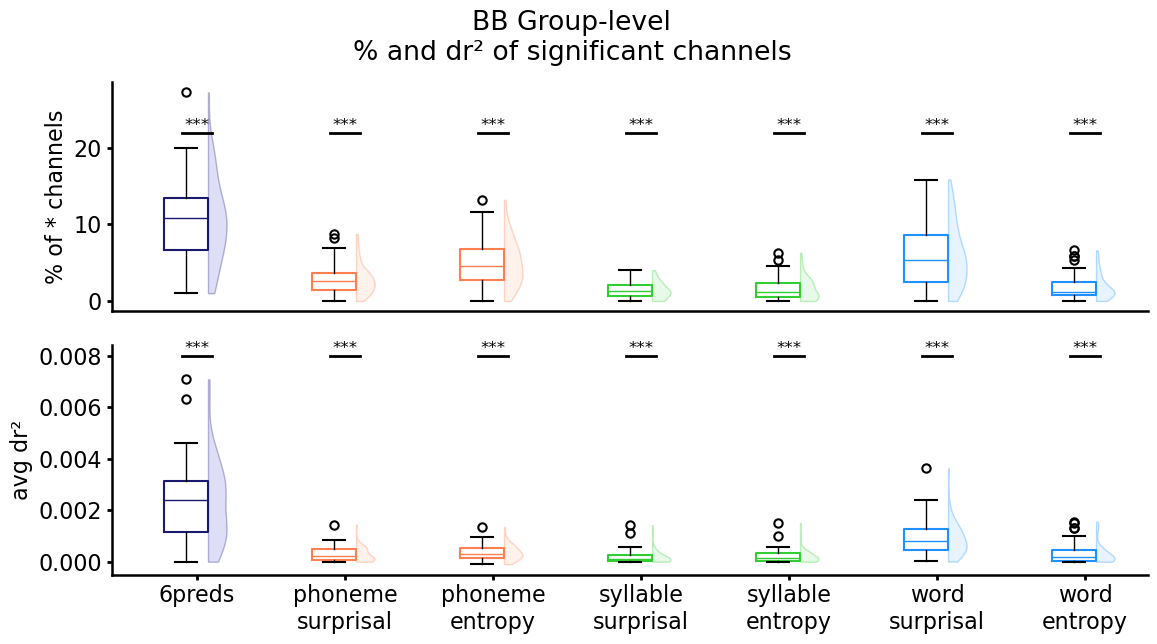

In [323]:
### for each model of 6preds, plot boxplot + scatter + violin with stat

f, ax = plt.subplots(2, 1, figsize=(12, 6))
x_ticks_positions = np.arange(len(models_6preds))
inter_gap = 0.15

for i_m, m in enumerate(models_6preds):

    scores = filter_nans(dico_6preds_bb[m]['dr2_subject_avg'])
    prop = dico_6preds_bb[m]['proportion_subject_avg']
    for i in range(2):
        data = [prop, scores][i]
        if i==0: data = data*100
        # ax[i].scatter(np.full(len(data), x_ticks_positions[i_m]), data, color=colors_6preds[m], alpha=0.5, showmeans=False, showmedians=False)
        ax[i].boxplot(data, positions=np.array([x_ticks_positions[i_m]])-inter_gap/2, widths=0.3, boxprops=dict(color=colors_6preds[m]), medianprops=dict(color=colors_6preds[m]))
        parts1 = ax[i].violinplot(data, positions=np.array([x_ticks_positions[i_m]])+inter_gap/2, showmeans=False, showmedians=False, showextrema=False, side='high', widths=0.25)
        for pc in parts1['bodies']:
            pc.set_facecolor(lighten_color(colors_6preds[m], .35))
            pc.set_edgecolor(colors_6preds[m])
            pc.set_alpha(0.3)
        
        plot_statistical_comparison(ax=ax[i], data_1=data, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=[22, 0.008][i])
    

# spines and ticks
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
ax[0].set_ylabel('% of * channels')
ax[1].set_ylabel('avg dr²')
ax[0].set_xticks([])
ax[1].set_xticks(x_ticks_positions)
ax[1].set_xticklabels(models_6preds)

f.tight_layout()
f.suptitle('BB Group-level\n% and dr² of significant channels', y=1.08)

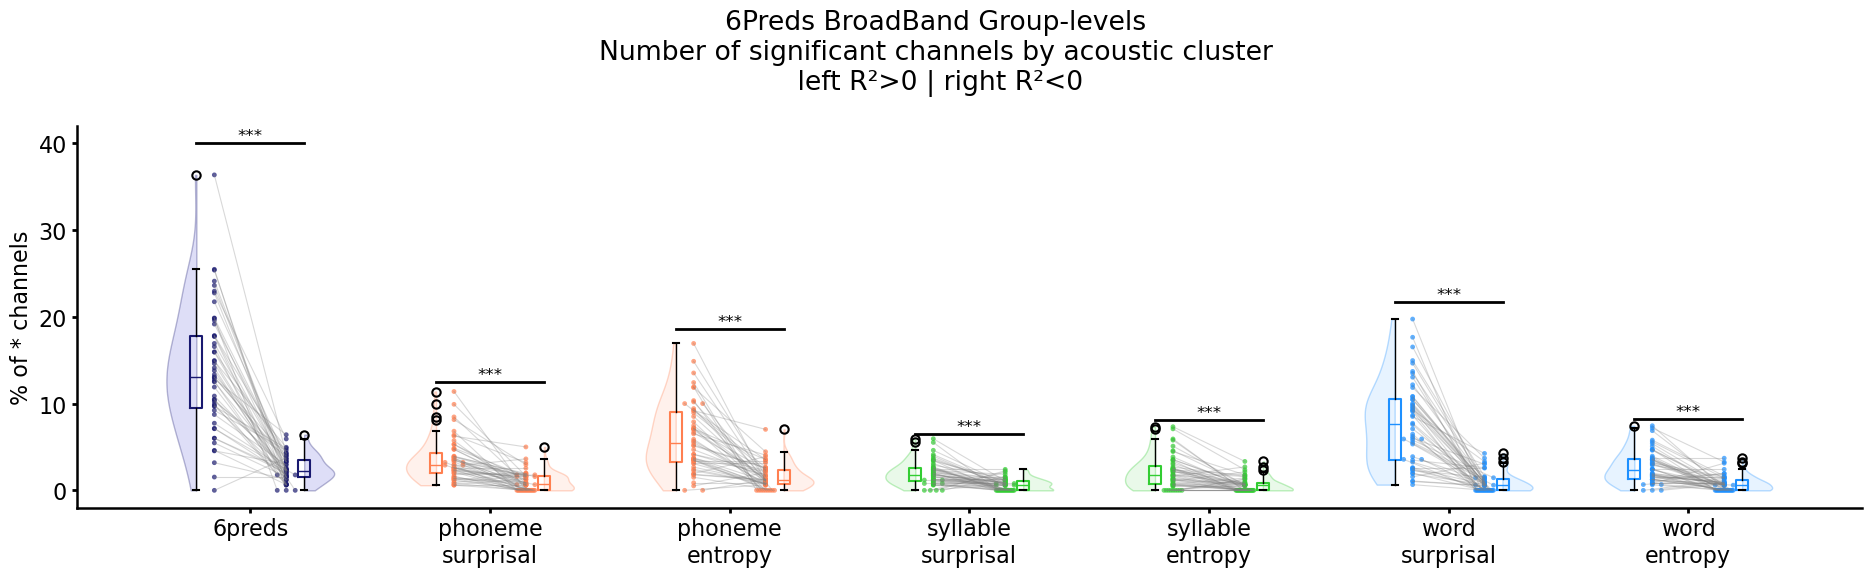

In [108]:
%matplotlib inline

x_ticks_positions = np.arange(len(models_6preds))
pos_neg_gap = 0.45
f, ax = plt.subplots(1, 1, figsize=(19, 6), sharex=True);

for i_m, m in enumerate(models_6preds):


    proportion_pos = dico_6preds_bb_by_cluster['acou_pos'][m]['proportion']
    proportion_neg = dico_6preds_bb_by_cluster['acou_neg'][m]['proportion']

    plot_pair_violinboxscatter(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_6preds[m], colors_6preds[m], inter_pair_gap=0.15)
    plot_statistical_comparison(ax, proportion_pos*100, proportion_neg*100, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=wilcoxon)


    # dr2_prop_pos = dico_6preds_bb_by_cluster['acou_pos'][m]['dr2_prop']
    # dr2_prop_neg = dico_6preds_bb_by_cluster['acou_neg'][m]['dr2_prop']

    # plot_pair_violinboxscatter(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_6preds[m], colors_6preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_prop_pos, dr2_prop_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

    dr2_pos = dico_6preds_bb_by_cluster['acou_pos'][m]['dr2']
    dr2_neg = dico_6preds_bb_by_cluster['acou_neg'][m]['dr2']

    # plot_pair_violinboxscatter(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, colors_4preds[m], colors_4preds[m], inter_pair_gap=0.15)
    # plot_statistical_comparison(ax[1], dr2_pos, dr2_neg, x_ticks_positions[i_m]-pos_neg_gap/2, x_ticks_positions[i_m]+pos_neg_gap/2, test_func=mannwhitneyu)

# ticks and spines
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(x_ticks_positions, models_6preds)
ax.set_ylabel('% of * channels')
f.suptitle(f'6Preds BroadBand Group-levels\nNumber of significant channels by acoustic cluster\n left R²>0 | right R²<0', y=.97);
f.tight_layout()



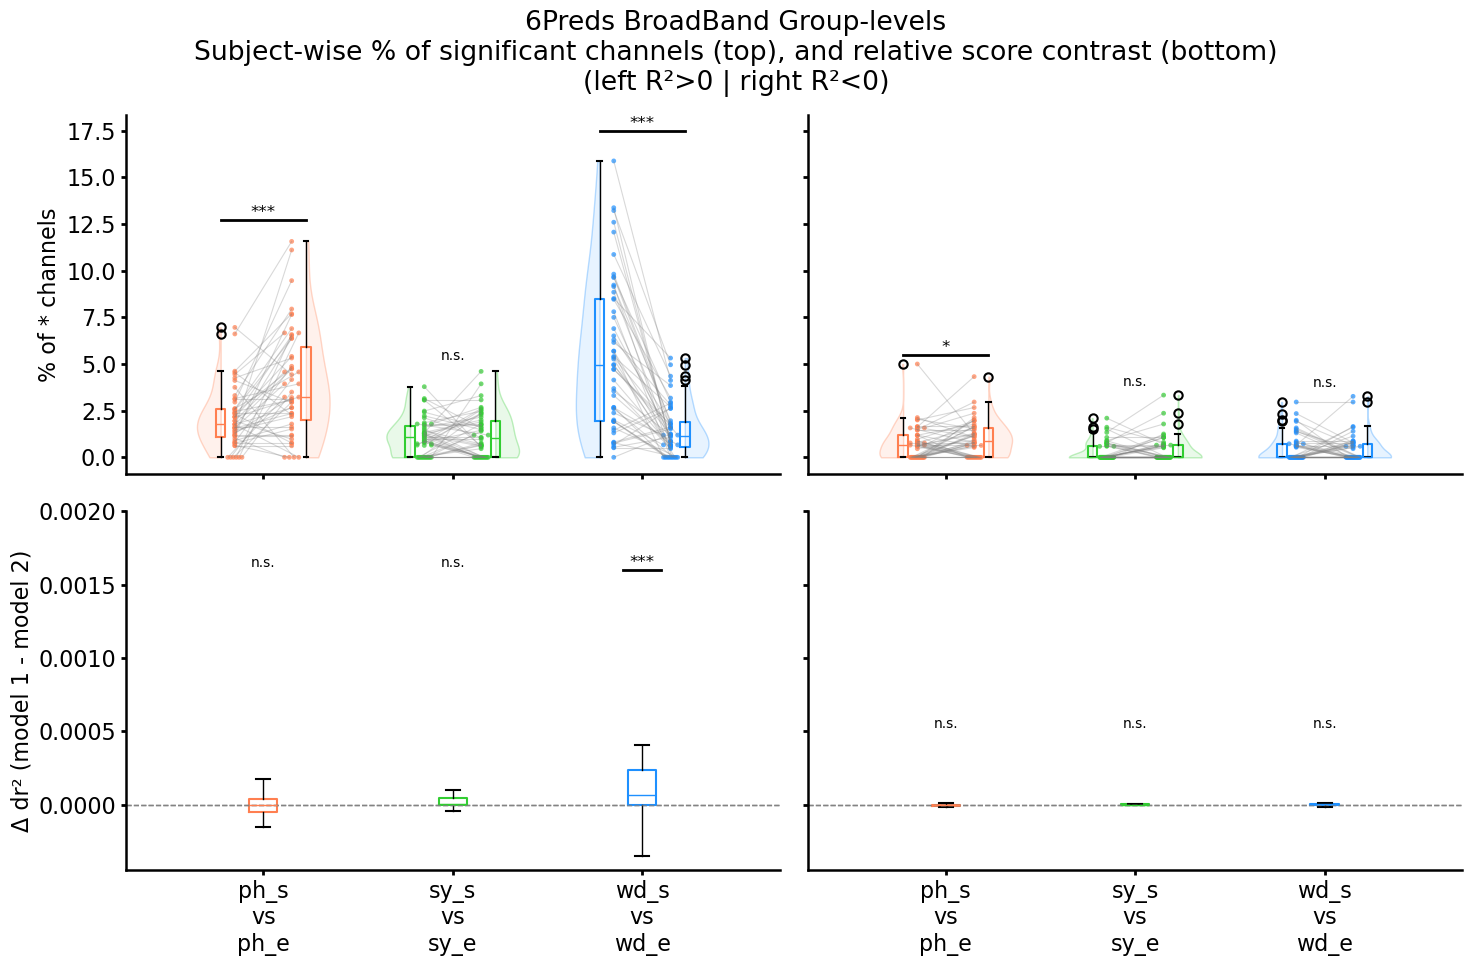

In [38]:
pairs = [['phoneme\nsurprisal', 'phoneme\nentropy'], ['syllable\nsurprisal', 'syllable\nentropy'], ['word\nsurprisal', 'word\nentropy']]
pairs_labels = [['ph_s', 'ph_e'], ['sy_s', 'sy_e'], ['wd_s', 'wd_e']]

x_ticks_positions = np.arange(len(pairs))
x_ticks_labels = [f'{m1}\nvs\n{m2}' for (m1, m2) in pairs_labels]
inter_pair_gap = .45

f,ax = plt.subplots(2,2, figsize=(15, 10), sharex=True, sharey='row') #, sharey='row')

for i_m, (m1, m2) in enumerate(pairs):

    for acou in ['acou_pos', 'acou_neg']:

        if acou == 'acou_pos': i_acou = 0
        else: i_acou = 1

        # get data
        prop_1 = dico_6preds_bb_by_cluster[acou][m1]['proportion']
        prop_2 = dico_6preds_bb_by_cluster[acou][m2]['proportion']

        dr2_1 = dico_6preds_bb_by_cluster[acou][m1]['dr2']
        dr2_2 = dico_6preds_bb_by_cluster[acou][m2]['dr2']
        contrast_dr2 = filter_nans(dr2_1 - dr2_2)

        # plot pair
        plot_pair_violinboxscatter(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, colors_6preds[m1], colors_6preds[m2], inter_pair_gap=0.15)
        plot_statistical_comparison(ax[0,i_acou], prop_1*100, prop_2*100, x_ticks_positions[i_m]-inter_pair_gap/2, x_ticks_positions[i_m]+inter_pair_gap/2, test_func=wilcoxon)

        # plot single boxplot for dr2 contrast
        bp = ax[1, i_acou].boxplot(
            contrast_dr2,
            positions=[x_ticks_positions[i_m]],
            widths=0.15,
            boxprops=dict(color=colors_6preds[m2]),
            medianprops=dict(color=colors_6preds[m2]),
            whiskerprops=dict(color='k'),
            capprops=dict(color='k'),
            showfliers=False
        )
        ax[1, i_acou].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        # ax[1,i_acou].set_ylim((-0.005, 0.005))

        # add statistical comparison for dr2 contrast
        plot_statistical_comparison(ax=ax[1,i_acou], data_1=contrast_dr2, data_2=None, x1=x_ticks_positions[i_m], x2=None, test_func=wilcoxon, y_stat=[0.0016, 0.0005][i_acou])

ax[1,0].set_ylim((None, 0.0020))        

for i in range(2):
    for j in range(2):
        ax[j,i].spines[['top', 'right']].set_visible(False)
    ax[0,i].set_xticks([])
    # ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
    ax[1,i].set_xticks(x_ticks_positions, x_ticks_labels)
# ax[0,0].set_ylabel('# of * channels')
ax[0,0].set_ylabel('% of * channels')
ax[1,0].set_ylabel('Δ dr² (model 1 - model 2)')

# ax[0,0].sharey(ax[0,1])

f.suptitle(f'6Preds BroadBand Group-levels\nSubject-wise % of significant channels (top), and relative score contrast (bottom)\n(left R²>0 | right R²<0)', y=.97);
f.tight_layout()

### Tracking / Predictive 



Text(0.5, 0.85, 'Channels significant (p<0.001)')

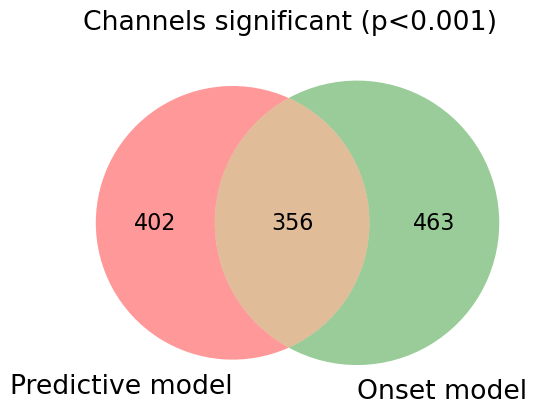

In [469]:
### TODO : have a new 'all_chans' with subjects 8, 34, and 37

p = 0.001
pred_chans =  all_chans[masks_preds[p]] # stat_masks[p]['base + pred_linguistic']['channels']
onset_chans = all_chans[masks_onsets[p]]
onset_chans.shape


f, ax = plt.subplots(1,1,figsize=(6,6))
venn2([set(pred_chans), set(onset_chans)], set_labels = ('Predictive model', 'Onset model'), ax=ax)
f.suptitle(f'Channels significant (p<{p})', y=0.85)

In [ ]:
### Intersection of channels responding to onset & predictive model

intersect_onset_predictive_mask = np.logical_and(masks_onsets[p], stat_masks[p]['base + pred_linguistic']['mask'].squeeze())
intersect_onset_predictive_chans = all_chans[intersect_onset_predictive_mask]
intersect_onset_predictive_locs = all_locs[intersect_onset_predictive_mask, :]
s = dr2_onsets[intersect_onset_predictive_mask]
s = np.clip(s, a_min=0, a_max=np.percentile(s, 99))

# viz_utils.brainscatter_static(scores=s, locations=intersect_onset_predictive_locs.T, channels=intersect_onset_predictive_chans, background='white', min_scores=0, cmap=cm.jet, close=False, fig_label=f'Onset & Predictive model intersection p<{p}');  # , hems = ['both']

In [11]:
### One color per region on the venn2 diagram

pred_no_onset_mask = np.logical_and(stat_masks[p]['base + pred_linguistic']['mask'].squeeze(), ~masks_onsets[p])
onset_no_pred_mask = np.logical_and(masks_onsets[p], ~stat_masks[p]['base + pred_linguistic']['mask'].squeeze())

s = np.ones(all_chans.shape)*-10
s[pred_no_onset_mask] = 1
s[intersect_onset_predictive_mask] = 2
s[onset_no_pred_mask] = 3

# intersect_onset_predictive_mask.sum()

# viz_utils.brainscatter_static(scores=s, locations=all_locs.T, channels=all_chans, background='white', min_scores=0, cmap=my_utils.create_mix_colormap('dodgerblue', 'coral'), close=False, fig_label=f'Onset & Predictive separation p<{p}');  # , hems = ['both']

In [12]:
### statistical test : how spatially different are the population encoding onsets vs predictive information?

onset_locs = all_locs[onset_no_pred_mask, :]
predictive_locs = all_locs[pred_no_onset_mask, :]

# wilcoxon-rank sign test on x, y, z coordinates separately
from scipy.stats import ranksums
for dim, coord in enumerate(['x', 'y', 'z']):
    stat, p_value = ranksums(onset_locs[:, dim], predictive_locs[:, dim], alternative='two-sided')
    print(f"Coordinate {coord} : stat={stat:.3f}, p={p_value:.3e}")


Coordinate x : stat=0.344, p=7.311e-01
Coordinate y : stat=-5.660, p=1.517e-08
Coordinate z : stat=3.564, p=3.653e-04


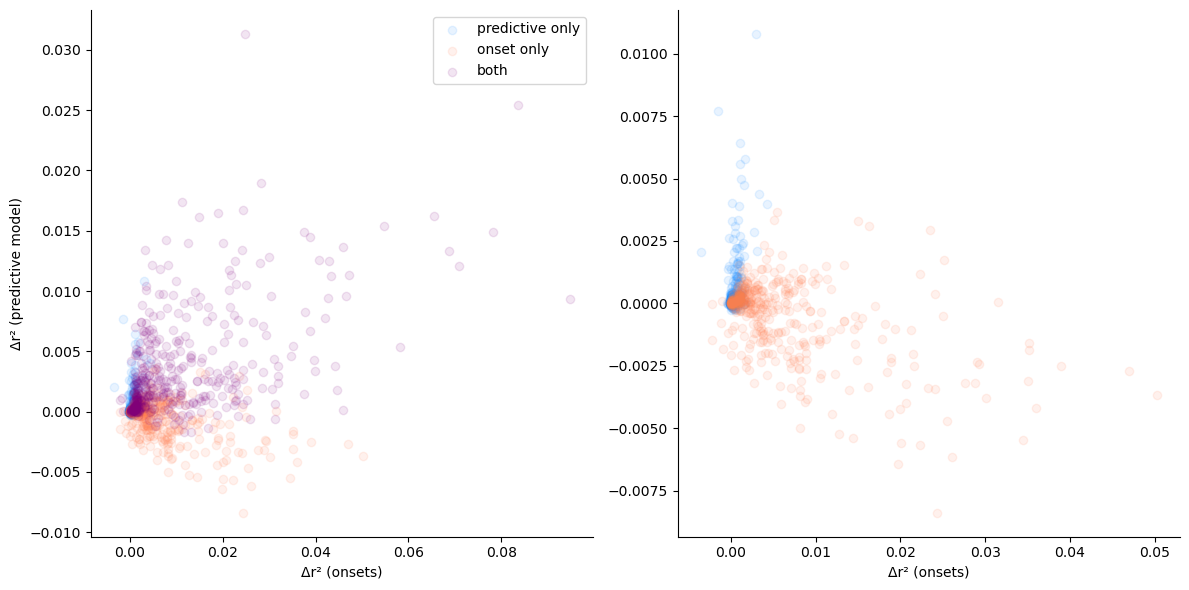

In [ ]:
### Scatter plot of dr² (onsets) vs dr² (predictive model), 1 color per region of the venn dagram

dr2_pred = np.vstack(df_permutations['base + pred_linguistic'].values)[:,0] - np.vstack(df_permutations['base'].values)[:,0]

f, ax = plt.subplots(1,2,figsize=(12,6))
alpha = 0.1
ax[0].scatter(dr2_onsets[pred_no_onset_mask], dr2_pred[pred_no_onset_mask], color='dodgerblue', alpha=alpha, label='predictive only')
ax[0].scatter(dr2_onsets[onset_no_pred_mask], dr2_pred[onset_no_pred_mask], color='coral', alpha=alpha, label = 'onset only')
ax[0].scatter(dr2_onsets[intersect_onset_predictive_mask], dr2_pred[intersect_onset_predictive_mask], color='purple', alpha=alpha, label = 'both')

ax[1].scatter(dr2_onsets[pred_no_onset_mask], dr2_pred[pred_no_onset_mask], color='dodgerblue', alpha=alpha, label='predictive only')
ax[1].scatter(dr2_onsets[onset_no_pred_mask], dr2_pred[onset_no_pred_mask], color='coral', alpha=alpha, label = 'onset only')

ax[0].set_xlabel('Δr² (onsets)')
ax[1].set_xlabel('Δr² (onsets)')
ax[0].set_ylabel('Δr² (predictive model)')
ax[0].legend()
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
f.tight_layout()




/home/sauvage/Documents/Code/paper_shiznit/viz_utils.py:178: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


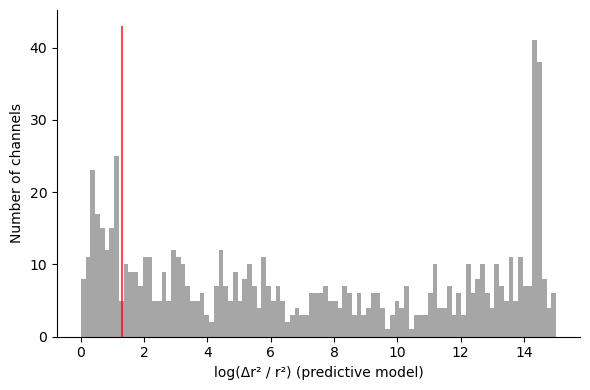

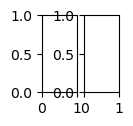

In [79]:
### visualize dr²_pred / r²_pred on the brain


preds_locs = all_locs[masks_preds[p], :]
preds_chans = all_chans[masks_preds[p]]
# s = np.ones(len(onset_chans))
s = scale_(dr2_preds[masks_preds[p]])/(scale_(data_preds[masks_preds[p]])+1e-6)  # to avoid division by zero
# s = np.log1p(s)
s = np.clip(s, a_min=0, a_max=np.percentile(s, 99.5))


thr = np.median(s) - np.median(np.absolute(s - np.mean(s)))

s_acou = s[s < thr]
locs_acou = preds_locs[s < thr, :]
chans_acou = preds_chans[s < thr]
s_ling = s[s >= thr]
locs_ling = preds_locs[s >= thr, :]
chans_ling = preds_chans[s >= thr]


#histogram of s
f, ax = plt.subplots(1,1,figsize=(6,4))

ax.hist(s, bins=100, color='gray', alpha=0.7)
ax.vlines(x=thr, ymin=0, ymax=ax.get_ylim()[1], color='red', alpha=0.7, label='threshold')
ax.set_xlabel('log(Δr² / r²) (predictive model)')
ax.set_ylabel('Number of channels')
ax.spines[['top', 'right']].set_visible(False)
f.tight_layout()

# viz_utils.brainscatter_static(scores=s, locations=preds_locs.T, channels=preds_chans, background='white', min_scores=0, cmap=cm.hot, close=False, fig_label=f'Predictive model Δr² / r²');  # , hems = ['both']

clusterized_locs = np.concatenate([locs_acou, locs_ling], axis=0)
clusterized_chans = np.concatenate([chans_acou, chans_ling], axis=0)
clusterized_scores = np.concatenate([np.ones(len(s_acou)), np.ones(len(s_ling))*1e-5], axis=0)

viz_utils.brainscatter_static(scores=clusterized_scores, locations=clusterized_locs.T, channels=clusterized_chans, background='white', min_scores=0, cmap=my_utils.create_mix_colormap('sandybrown', 'cornflowerblue'), close=False, fig_label=f'Predictive model - Acoustic vs Linguistic');  # , hems = ['both']


### Encoding of predictive features (Venn)

#### Venn

In [41]:

p = 1e-3

ch_ph = stat_masks[p]['base + ph']['channels']
ch_syll = stat_masks[p]['base + syll']['channels']
ch_wd = stat_masks[p]['base + wd']['channels']

ch_full_surprise = stat_masks[p]['base + 3surprise']['channels']
ch_full_entropy = stat_masks[p]['base + 3entropy']['channels']

fig, axes = plt.subplots(1, 2, figsize=(10,5))

venn3([set(ch_ph), set(ch_syll), set(ch_wd)], set_labels = ('2Phonetic', '2Syllabic', '2Lexical'), ax=axes[0], set_colors=(colors_['base + ph'], colors_['base + syll'], colors_['base + wd']))
# plt.show()
axes[0].set_title('Linguistic levels')
venn2([set(ch_full_surprise), set(ch_full_entropy)], set_labels = ('3Surprise', '3Entropy'), ax=axes[1], set_colors=(colors_['base + 3surprise'], colors_['base + 3entropy']))
axes[1].set_title('Prediction Error vs. Prediction Uncertainty')
fig.tight_layout()
fig.suptitle(f'Overlap of significant channels (p<{p})', fontsize=14, y=0.05)

if save_figs:
    # save in png and in svg
    fig.savefig(f'{fig_path}/broadband/png/venn_significant_channels_p<{p}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_path}/broadband/svg/venn_significant_channels_p<{p}.svg', format='svg', bbox_inches='tight')

In [50]:
p =  1e-3

fig, axes = plt.subplots(3, 1, figsize=(4, 6))

for i, level in enumerate(['ph', 'syll', 'wd']):
    ch_s = stat_masks[p][f'base + {level}_surprise']['channels']
    ch_e = stat_masks[p][f'base + {level}_entropy']['channels']

    axes[i].set_title(f'{level}', y=0.95)
    venn2([set(ch_s), set(ch_e)], set_labels = ('Surprise', 'Entropy'), ax=axes[i], set_colors=(colors_[f'base + {level}_surprise'], colors_[f'base + {level}_entropy']))
    
fig.tight_layout()
# fig.suptitle(f'Prediction Error vs. Prediction Uncertainty\nOverlap of significant channels with p<{p}', fontsize=14, y=1.01)
fig.suptitle(f'Overlap of significant channels (p<{p})', fontsize=14, y=0.03)

if save_figs:
    # save in png and in svg
    fig.savefig(f'{fig_path}/broadband/png/venn_significant_channels_p<{p}_level-wise.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_path}/broadband/svg/venn_significant_channels_p<{p}_level-wise.svg', format='svg', bbox_inches='tight')

In [ ]:
p =  1e-3

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
for i, feat in enumerate(['Surprise', 'Entropy']):
    ch_ph = stat_masks[p][f'base + ph_{feat.lower()}']['channels']
    ch_syll = stat_masks[p][f'base + syll_{feat.lower()}']['channels']
    ch_wd = stat_masks[p][f'base + wd_{feat.lower()}']['channels']

    axes[i].set_title(f'{feat}', y=1.02)
    venn3([set(ch_ph), set(ch_syll), set(ch_wd)], set_labels = ('phoneme', 'syllable', 'word'), ax=axes[i], set_colors=(colors_[f'base + ph_{feat.lower()}'], colors_[f'base + syll_{feat.lower()}'], colors_[f'base + wd_{feat.lower()}']))

fig.tight_layout()
# fig.suptitle(f'Overlap of significant channels (p<{p})', fontsize=14, y=0.05)

if save_figs:
    # save in png and in svg
    fig.savefig(f'{fig_path}/png/venn_significant_channels_p<{p}_feature_wise.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_path}/svg/venn_significant_channels_p<{p}_feature_wise.svg', format='svg', bbox_inches='tight')


In [61]:
chan_ph_E = stat_masks[1e-3]['base + ph_entropy']['channels']
loc_ph_E = all_locs[stat_masks[1e-3]['base + ph_entropy']['mask'].squeeze(), :]
s_ph_E = np.ones((len(chan_ph_E), 1))

chan_wd_S = stat_masks[1e-3]['base + wd_surprise']['channels']
loc_wd_S = all_locs[stat_masks[1e-3]['base + wd_surprise']['mask'].squeeze(), :]
s_wd_S = np.ones((len(chan_wd_S), 1))*2


intersection_of_interest = set(chan_ph_E).intersection(set(chan_wd_S))
print(f"number of channels in the intersection : {len(intersection_of_interest)}")


locs = []
scores = []
channels = []

for ch, loc, score in zip(chan_ph_E, loc_ph_E, s_ph_E):
    if not ch in intersection_of_interest:
        locs.append(loc)
        scores.append(score)
        channels.append(ch)

for ch, loc, score in zip(chan_wd_S, loc_wd_S, s_wd_S):
    if not ch in intersection_of_interest:
        locs.append(loc)
        scores.append(score)
        channels.append(ch)

locs = np.asarray(locs)
scores = np.asarray(scores)[:,0]
channels = np.asarray(channels)

viz_utils.brainscatter_static(scores=scores, locations=locs.T, channels=channels, background='white', min_scores=0, cmap=cm.jet, close=False, fig_label=f'{m}');  # , hems = ['both']

number of channels in the intersection : 30


### Brain plots
- scores relatifs
- locs
- plot on brains

In [10]:
### plot the barycenters of each set of significant channels
p = 1e-3

loc_ph = all_locs[stat_masks[p]['base + ph']['mask'].squeeze(),:]
loc_syll = all_locs[stat_masks[p]['base + syll']['mask'].squeeze(),:]
loc_wd = all_locs[stat_masks[p]['base + wd']['mask'].squeeze(),:]
loc_3surprise = all_locs[stat_masks[p]['base + 3surprise']['mask'].squeeze(),:]
loc_3entropy = all_locs[stat_masks[p]['base + 3entropy']['mask'].squeeze(),:]

# get barycenters splitted by hemisphere !
ph_barycenter_l = np.mean(loc_ph[loc_ph[:,1] > 0], axis=0)
syll_barycenter_l = np.mean(loc_syll[loc_syll[:,1] > 0], axis=0)
wd_barycenter_l = np.mean(loc_wd[loc_wd[:,1] > 0], axis=0)
surprise3_barycenter_l = np.mean(loc_3surprise[loc_3surprise[:,1] > 0], axis=0)
entropy3_barycenter_l = np.mean(loc_3entropy[loc_3entropy[:,1] > 0], axis=0)

ph_barycenter_r = np.mean(loc_ph[loc_ph[:,1] < 0], axis=0)
syll_barycenter_r = np.mean(loc_syll[loc_syll[:,1] < 0], axis=0)
wd_barycenter_r = np.mean(loc_wd[loc_wd[:,1] < 0], axis=0)
surprise3_barycenter_r = np.mean(loc_3surprise[loc_3surprise[:,1] < 0], axis=0)
entropy3_barycenter_r = np.mean(loc_3entropy[loc_3entropy[:,1] < 0], axis=0)

loc_barycenters = np.vstack([ph_barycenter_l, syll_barycenter_l, wd_barycenter_l, surprise3_barycenter_l, entropy3_barycenter_l,
                              ph_barycenter_r, syll_barycenter_r, wd_barycenter_r, surprise3_barycenter_r, entropy3_barycenter_r])

In [81]:
### show channels responsive to : 

p = 1e-3

m = 'base + ph'


locs = np.vstack(df_metasubj['loc'].values)[stat_masks[p][m]['mask'].squeeze(),:]
channels = stat_masks[p][m]['channels']
s = np.ones(len(channels))


viz_utils.brainscatter_static(scores=s, locations=locs.T, channels=channels, background='white', min_scores=0, cmap=cm.jet, close=False, fig_label=f'{m}');  # , hems = ['both']

### Spectral Profiles of Encoding

In [42]:
freqs     = np.linspace(np.sqrt(0.3), np.sqrt(180), 81)**2 # Hilbert: 81 freqs - 80 bands
freqs_mid = (freqs[:-1] + freqs[1:]) / 2

In [43]:
def spectral_df_to_array(df, excluded_subjects):
    # Remove rows where subject (first level of multi-index) is in excluded_subjects
    df = df[~df.index.get_level_values(0).isin(excluded_subjects)]

    # Reshape the dataframe to have arrays of length 80 (number of frequencies) as values
    df_compact = df.groupby(level=[0, 2]).apply(lambda x: x.values.flatten())

    # Convert to DataFrame with proper structure
    df_compact = pd.DataFrame({
        'r2': df.groupby(level=[0, 2])['r2'].apply(lambda x: x.values)
    })
    return np.vstack(df_compact['r2'].values)

In [44]:
import sys, numpy as np
sys.modules['numpy._core'] = np.core
sys.modules['numpy._core.numeric'] = np.core.numeric

fres_results_path = '/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/f-resolved/server_results'

full_profiles_4preds = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons4preds.pkl'))
profiles_4preds_no_ws = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1we.pkl'))
profiles_4preds_no_we = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1ws.pkl'))
profiles_4preds_no_ps = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1pe.pkl'))
profiles_4preds_no_pe = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1ps.pkl'))

# re save at the same place with '_v2' suffix
full_profiles_4preds.to_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons4preds_v2.pkl'))
profiles_4preds_no_ws.to_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1we_v2.pkl'))
profiles_4preds_no_we.to_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1ws_v2.pkl'))
profiles_4preds_no_ps.to_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1pe_v2.pkl'))
profiles_4preds_no_pe.to_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1ps_v2.pkl'))


In [45]:
# print('Old df index :', df_full_profiles_4preds.index.names)

# # Remove rows where subject (first level of multi-index) is in excluded_subjects
# df_full_profiles_4preds = df_full_profiles_4preds[~df_full_profiles_4preds.index.get_level_values(0).isin(excluded_subjects)]

# # multi-index dimensions are ('subject', 'channel', 'frequency')
# # Reshape the dataframe to have arrays of length 80 (number of frequencies) as values
# df_full_profiles_4preds_compact = df_full_profiles_4preds.groupby(level=[0, 2]).apply(lambda x: x.values.flatten())

# # Convert to DataFrame with proper structure
# df_full_profiles_4preds_compact = pd.DataFrame({
#     'r2': df_full_profiles_4preds.groupby(level=[0, 2])['r2'].apply(lambda x: x.values)
# })

In [46]:
fres_results_path

'/home/sauvage/Documents/Code/Wildly_Convoluted_Brains/results/f-resolved/server_results'

In [47]:
# use pandas to reload/ load the pickle file
df_4preds_full_profiles = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons4preds_v2.pkl'))
df_4preds_no_ws = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1we_v2.pkl'))
df_4preds_no_we = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2ph1ws_v2.pkl'))
df_4preds_no_ps = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1pe_v2.pkl'))
df_4preds_no_pe = pd.read_pickle(os.path.join(fres_results_path, '4preds/amp_enc_5acc3ons2wd1ps_v2.pkl'))


full_profiles_4preds = spectral_df_to_array(df_4preds_full_profiles, excluded_subjects)

# compute unique variance sspectral profiles
ws_profiles_4preds = full_profiles_4preds - spectral_df_to_array(df_4preds_no_ws, excluded_subjects)
we_profiles_4preds = full_profiles_4preds - spectral_df_to_array(df_4preds_no_we, excluded_subjects)
ps_profiles_4preds = full_profiles_4preds - spectral_df_to_array(df_4preds_no_ps, excluded_subjects)
pe_profiles_4preds = full_profiles_4preds - spectral_df_to_array(df_4preds_no_pe, excluded_subjects)

print('New array shape :', full_profiles_4preds.shape)  # should be (n_channels_total, n_frequencies)
print(ws_profiles_4preds.shape, we_profiles_4preds.shape, ps_profiles_4preds.shape, pe_profiles_4preds.shape)


New array shape : (7304, 80)
(7304, 80) (7304, 80) (7304, 80) (7304, 80)


2.0403391155708723e-08 4
0.000763147397809963 29
1.5248127592014017e-08 20
0.003541533232009897 6
0.006452321851562132 21
0.010971817328860085 36
0.08117306453225187 30
0.030705001490489874 31


/tmp/ipykernel_6771/1106502630.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


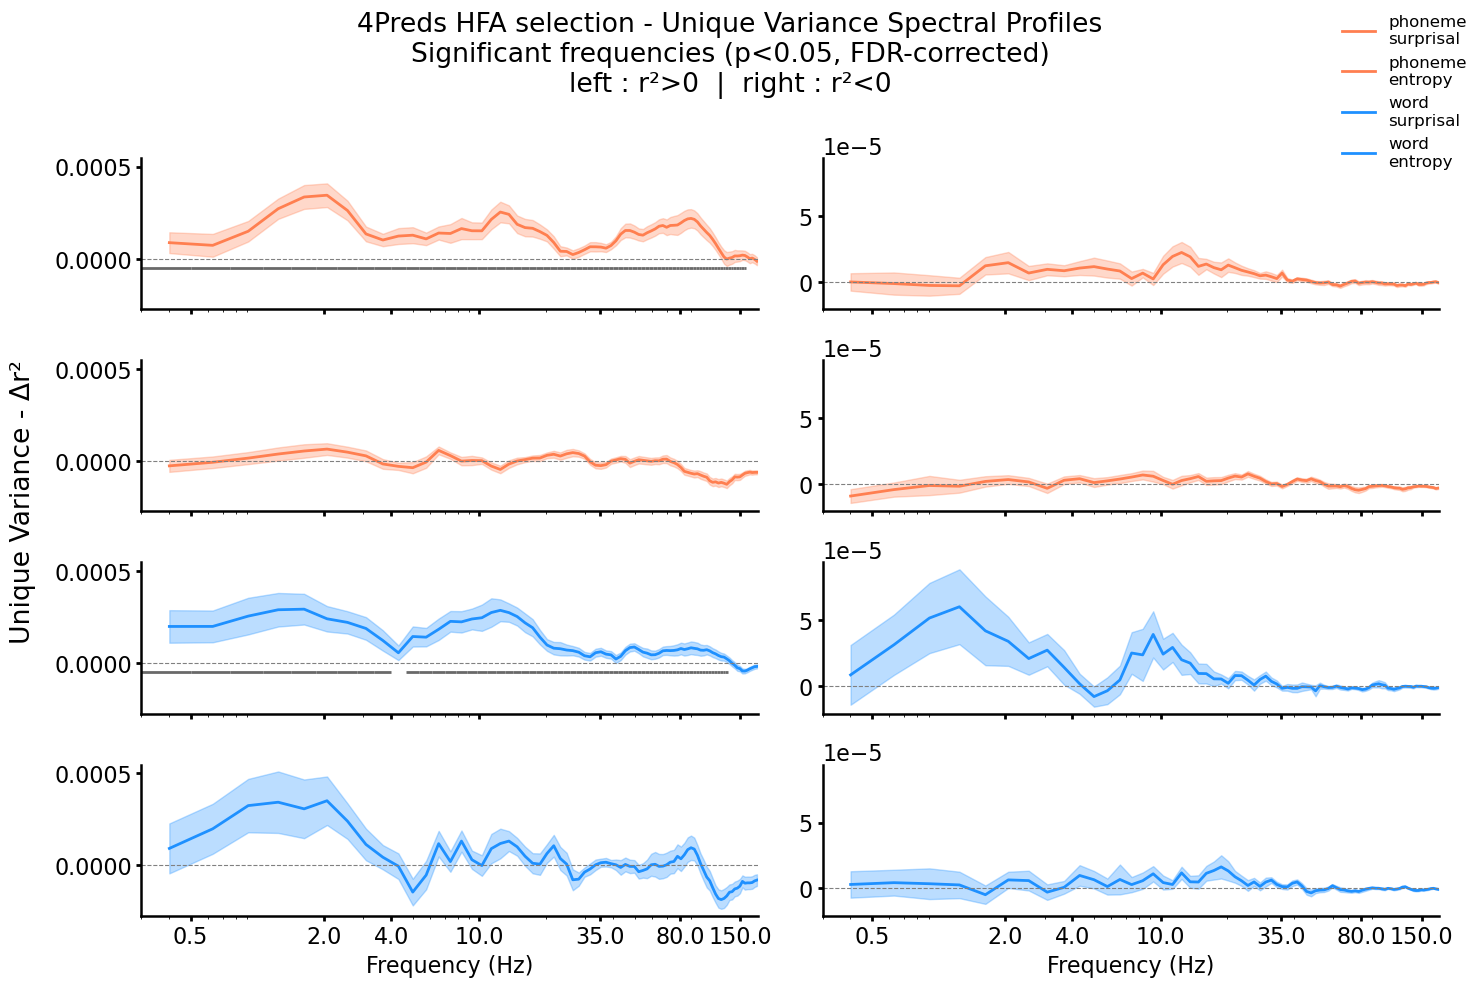

In [ ]:
%matplotlib inline

models_to_plot = ['phoneme\nsurprisal', 'phoneme\nentropy', 'word\nsurprisal', 'word\nentropy']

f, ax = plt.subplots(len(models_to_plot), 2, figsize=(15, 10), sharex=True, sharey='col')

for i_mask, mask_acou in enumerate([mask_4preds_acou_pos_hfa, mask_4preds_acou_neg_hfa]):
    for i_m, m in enumerate(models_to_plot):
        if m == 'phoneme\nsurprisal': profiles = ws_profiles_4preds
        if m == 'phoneme\nentropy': profiles = we_profiles_4preds
        if m == 'word\nsurprisal': profiles = ps_profiles_4preds
        if m == 'word\nentropy': profiles = pe_profiles_4preds

        mask = dico_4preds_hfa[m]['mask'][0.01]  # get significant channels mask for that model at p=0.001
        profiles = profiles[mask & mask_acou, :]  # select only significant channels with acoustic mask

        # average across channels
        mean_profile = np.nanmean(profiles, axis=0)
        sem_profile = np.nanstd(profiles, axis=0) / np.sqrt(profiles.shape[0])

        # plot
        ax[i_m, i_mask].plot(freqs_mid, mean_profile, label=['', f'{m}'][i_mask], color=colors_6preds[m])
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile - sem_profile, mean_profile + sem_profile, color=colors_6preds[m], alpha=0.3)
        ax[i_m, i_mask].set_xscale('log')
        ax[i_m, i_mask].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        
        # statistical test against 0 at each frequency (one-sample t-test) + FDR correction
        p_values = []
        for freq in range(profiles.shape[1]):  #statistical test at each frequency
            stat, p_val = wilcoxon(x=profiles[:, freq], alternative = 'greater')
            p_values.append(p_val)
        p_values = np.array(p_values)
        print(p_values.min(), p_values.argmin())
        pvals_corrected = multipletests(p_values, method='fdr_tsbh')[1]
        #pvals_corrected = np.asarray(p_values)
        sig_freqs = freqs_mid[pvals_corrected < 0.05]  # mark significant frequencies on the plot
        
        # if a frequency is significant : plot a line centered in mid_freqs[freq] starting at freqs[freq] and ending at freqs[freq+1]
        for freq in range(profiles.shape[1]):
            if pvals_corrected[freq] < 0.05:
                if freq == freqs[0] : xmin=freqs[0]
                else: xmin=freqs[freq]
                ax[i_m, i_mask].hlines(y=-5e-5 , xmin=freqs[freq], xmax=freqs[freq+1], color='dimgray', linewidth=2)

# set xlims 
ax[-1,0].set_xlim(0.3, 180)
ax[-1,1].set_xlim(0.3, 180)

# ticks and labels
for i in range(len(models_to_plot)):
    ax[i,0].spines[['top', 'right']].set_visible(False)
    ax[i,0].set_xticks(custom_ticks)
    ax[i,0].set_xticklabels(custom_ticks_labels)
    ax[i,0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax[i,1].spines[['top', 'right']].set_visible(False)
    ax[i,1].set_xticks(custom_ticks)
    ax[i,1].set_xticklabels(custom_ticks_labels)
    ax[i,1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[-1,0].set_xlabel('Frequency (Hz)')
ax[-1,1].set_xlabel('Frequency (Hz)')


f.supylabel('Unique Variance - Δr²')

f.suptitle('4Preds HFA selection - Unique Variance Spectral Profiles\nSignificant frequencies (p<0.05, FDR-corrected)\nleft : r²>0  |  right : r²<0', y=0.99)

f.legend(loc='upper right', fontsize=12)
f.tight_layout()
f.show()


[8.67655564e-02 3.95246531e-02 1.31628439e-02 1.06919861e-03
 5.15999696e-04 8.70103861e-04 5.04919010e-03 3.85888256e-01
 4.40949163e-01 5.62193174e-02 1.02570730e-03 9.83371370e-02
 5.29921638e-02 7.19971475e-01 1.35649724e-01 4.45128376e-03
 1.06719567e-02 9.11056953e-03 2.35666367e-04 2.29494165e-04
 9.64522340e-03 1.57527501e-02 2.18887692e-02 6.80852368e-03
 1.15766868e-02 1.17925963e-02 9.21979053e-02 1.64903243e-01
 2.59287875e-01 2.50487691e-01 3.50895504e-01 4.61254595e-01
 4.26685238e-01 1.81424573e-01 1.05414147e-01 2.47403525e-01
 5.46357951e-02 9.16144947e-02 2.76642114e-02 6.59543432e-04
 1.17112242e-02 1.26060277e-03 4.97318091e-02 3.62454487e-02
 5.57512610e-03 2.73516690e-01 1.90127977e-02 1.33434408e-02
 3.43871947e-02 4.17629745e-02 3.78925284e-02 1.17143163e-01
 7.56112880e-02 2.00677107e-01 2.82414960e-01 3.37549453e-01
 2.10491435e-01 3.73769191e-01 5.35935490e-01 2.29064387e-01
 1.05737018e-01 9.71163110e-02 2.72634554e-01 5.25383478e-01
 8.62219982e-01 9.938354

/tmp/ipykernel_6771/2601436091.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


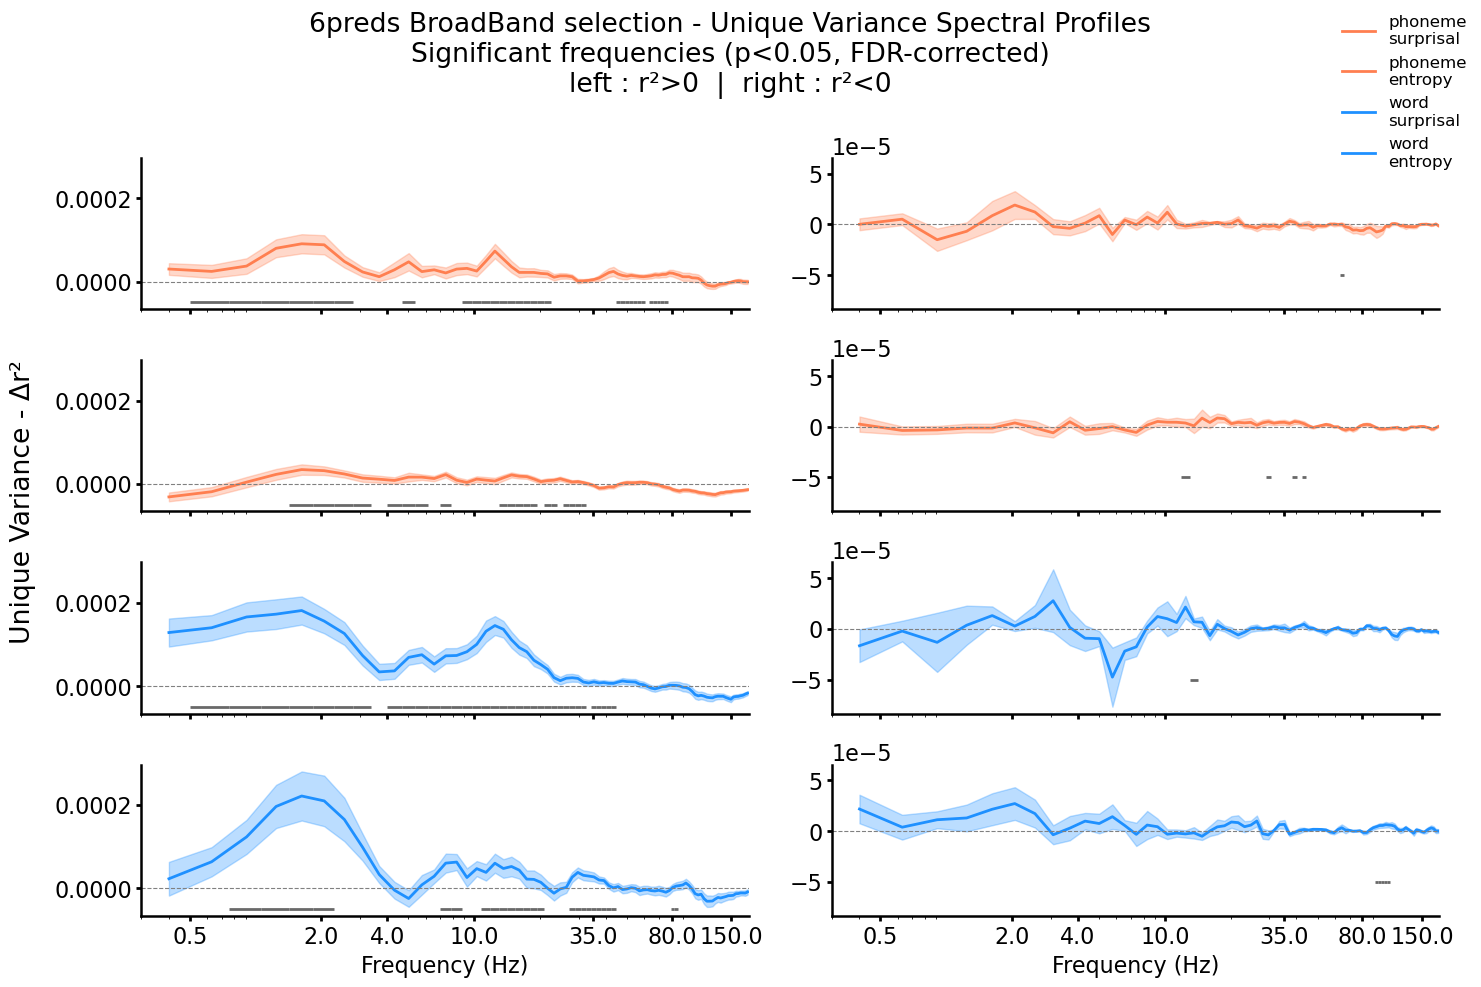

In [90]:
models_to_plot = ['phoneme\nsurprisal', 'phoneme\nentropy', 'word\nsurprisal', 'word\nentropy']
p = 0.01

f, ax = plt.subplots(len(models_to_plot), 2, figsize=(15, 10), sharex=True, sharey='col')

for i_mask, mask_acou in enumerate([mask_6preds_acou_pos_bb, mask_6preds_acou_neg_bb]):
    for i_m, m in enumerate(models_to_plot):
        if m == 'phoneme\nsurprisal': profiles = ws_profiles_4preds
        if m == 'phoneme\nentropy': profiles = we_profiles_4preds
        if m == 'word\nsurprisal': profiles = ps_profiles_4preds
        if m == 'word\nentropy': profiles = pe_profiles_4preds

        mask = dico_6preds_bb[m]['mask'][p]  # get significant channels mask for that model at p=0.001
        profiles = profiles[mask & mask_acou, :]  # select only significant channels with acoustic mask

        # average across channels
        mean_profile = np.nanmean(profiles, axis=0)
        sem_profile = np.nanstd(profiles, axis=0) / np.sqrt(profiles.shape[0])

        # plot
        ax[i_m, i_mask].plot(freqs_mid, mean_profile, label=['', f'{m}'][i_mask], color=colors_6preds[m])
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile - sem_profile, mean_profile + sem_profile, color=colors_6preds[m], alpha=0.3)
        ax[i_m, i_mask].set_xscale('log')
        ax[i_m, i_mask].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        
        # statistical test against 0 at each frequency (one-sample t-test) + FDR correction
        p_values = []
        for freq in range(profiles.shape[1]):  #statistical test at each frequency
            stat, p_val = wilcoxon(x=profiles[:, freq], alternative = 'greater')
            p_values.append(p_val)
        p_values = np.array(p_values)
        print(p_values)
        pvals_corrected = multipletests(p_values, method='fdr_tsbh')[1]
        pvals_corrected = np.asarray(p_values)
        sig_freqs = freqs_mid[pvals_corrected < 0.05]  # mark significant frequencies on the plot
        
        # if a frequency is significant : plot a line centered in mid_freqs[freq] starting at freqs[freq] and ending at freqs[freq+1]
        for freq in range(profiles.shape[1]):
            if pvals_corrected[freq] < 0.05:
                if freq == freqs[0] : xmin=freqs[0]
                else: xmin=freqs[freq]
                ax[i_m, i_mask].hlines(y=-5e-5 , xmin=freqs[freq], xmax=freqs[freq+1], color='dimgray', linewidth=2)

# set xlims 
ax[-1,0].set_xlim(0.3, 180)
ax[-1,1].set_xlim(0.3, 180)

# ticks and labels
for i in range(len(models_to_plot)):
    ax[i,0].spines[['top', 'right']].set_visible(False)
    ax[i,0].set_xticks(custom_ticks)
    ax[i,0].set_xticklabels(custom_ticks_labels)
    ax[i,0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax[i,1].spines[['top', 'right']].set_visible(False)
    ax[i,1].set_xticks(custom_ticks)
    ax[i,1].set_xticklabels(custom_ticks_labels)
    ax[i,1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[-1,0].set_xlabel('Frequency (Hz)')
ax[-1,1].set_xlabel('Frequency (Hz)')

f.supylabel('Unique Variance - Δr²')

f.suptitle('6preds BroadBand selection - Unique Variance Spectral Profiles\nSignificant frequencies (p<0.05, FDR-corrected)\nleft : r²>0  |  right : r²<0', y=0.99)

f.legend(loc='upper right', fontsize=12)
f.tight_layout()
f.show()


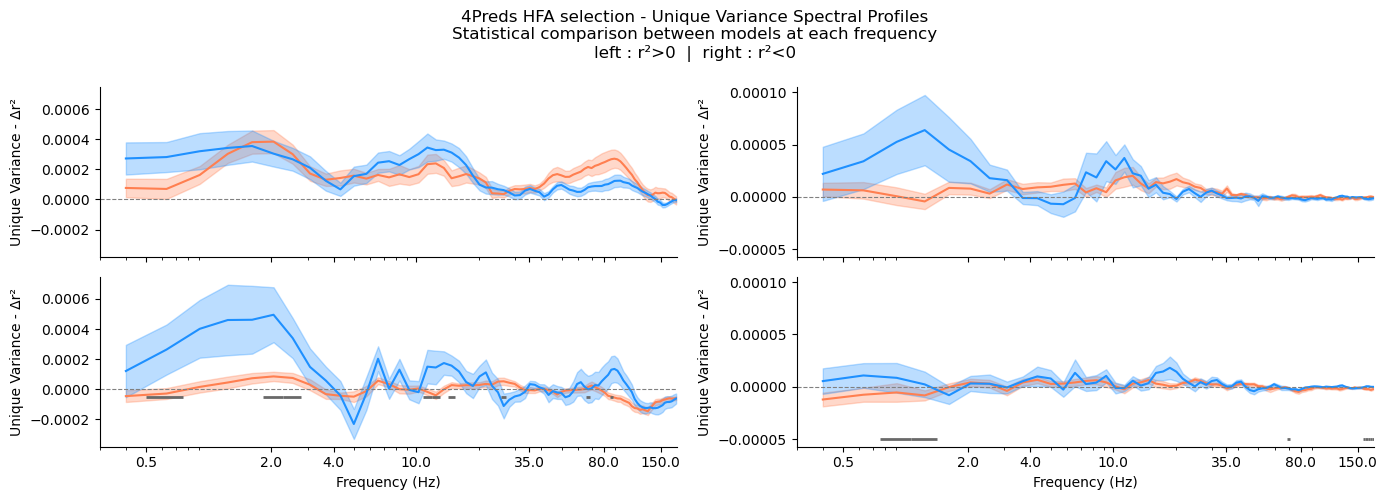

In [39]:
## make a figure comparing pairs of profiles, with statistical comparison between profiles at each frequency
model_pairs = [('phoneme\nsurprisal', 'word\nsurprisal'), ('phoneme\nentropy', 'word\nentropy')]
same_color_in_pair = False

f, ax = plt.subplots(len(model_pairs), 2, figsize=(14, 5), sharex=True, sharey='col')

for i_mask, mask_acou in enumerate([mask_acou_pos, mask_acou_neg]):
    for i_m, (m1, m2) in enumerate(model_pairs):
        if m1 == 'phoneme\nsurprisal': profiles1 = ws_profiles_4preds
        if m1 == 'phoneme\nentropy': profiles1 = we_profiles_4preds
        if m1 == 'word\nsurprisal': profiles1 = ps_profiles_4preds
        if m1 == 'word\nentropy': profiles1 = pe_profiles_4preds

        if m2 == 'phoneme\nsurprisal': profiles2 = ws_profiles_4preds
        if m2 == 'phoneme\nentropy': profiles2 = we_profiles_4preds
        if m2 == 'word\nsurprisal': profiles2 = ps_profiles_4preds
        if m2 == 'word\nentropy': profiles2 = pe_profiles_4preds

        mask1 = dico_4preds_hfa[m1]['mask'][0.001]
        mask2 = dico_4preds_hfa[m2]['mask'][0.001]
        # combined_mask = np.logical_and(mask1, mask2)  # select channels significant in both models

        profiles1 = profiles1[mask1 & mask_acou, :]
        profiles2 = profiles2[mask2 & mask_acou, :]

        mean_profile1 = np.nanmean(profiles1, axis=0)
        sem_profile1 = np.nanstd(profiles1, axis=0) / np.sqrt(profiles1.shape[0])

        mean_profile2 = np.nanmean(profiles2, axis=0)
        sem_profile2 = np.nanstd(profiles2, axis=0) / np.sqrt(profiles2.shape[0])

        ax[i_m, i_mask].plot(freqs_mid, mean_profile1, label=f'{m1}', color=colors_4preds[m1])
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile1 - sem_profile1, mean_profile1 + sem_profile1, color=colors_4preds[m1], alpha=0.3)

        ax[i_m, i_mask].plot(freqs_mid, mean_profile2, label=f'{m2}', color=colors_4preds[m2], alpha=0.7 if same_color_in_pair else 1.0)
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile2 - sem_profile2, mean_profile2 + sem_profile2, color=colors_4preds[m2], alpha=0.15 if same_color_in_pair else 0.3)
        ax[i_m, i_mask].set_xscale('log')
        ax[i_m, i_mask].set_ylabel('Unique Variance - Δr²')
        ax[i_m, i_mask].axhline(0, color='gray', linestyle='--', linewidth=0.8) 
        # ax[i_m, i_mask].set_title(f'{m1.replace("\n", " ")} vs {m2.replace("\n", " ")}', y=0.92)
        # statistical comparison between profiles at each frequency (paired wilcoxon)
        p_values = []
        for freq in range(profiles1.shape[1]):
            stat, p_val = mannwhitneyu(profiles1[:, freq], profiles2[:, freq], alternative='two-sided')
            p_values.append(p_val)
        p_values = np.array(p_values)
        pvals_corrected = false_discovery_control(p_values, method='by')
        sig_freqs = freqs_mid[pvals_corrected < 0.05]

    for freq in range(profiles1.shape[1]):
        # if pvals_corrected[freq] < 0.05:
        if p_values[freq] < 0.05:
            ax[i_m, i_mask].hlines(y=-5e-5 , xmin=freqs[freq], xmax=freqs[freq+1], color='dimgray', linewidth=2)

# set xlims 
ax[-1,0].set_xlim(0.3, 180)
ax[-1,1].set_xlim(0.3, 180)
# ticks and labels
for i in range(len(model_pairs)):
    ax[i,0].spines[['top', 'right']].set_visible(False)
    ax[i,0].set_xticks(custom_ticks)
    ax[i,0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax[i,1].spines[['top', 'right']].set_visible(False)
    ax[i,1].set_xticks(custom_ticks)
    ax[i,1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[-1,0].set_xlabel('Frequency (Hz)')
ax[-1,1].set_xlabel('Frequency (Hz)')

f.suptitle('4Preds HFA selection - Unique Variance Spectral Profiles\nStatistical comparison between models at each frequency\nleft : r²>0  |  right : r²<0', y=0.99)
f.tight_layout()



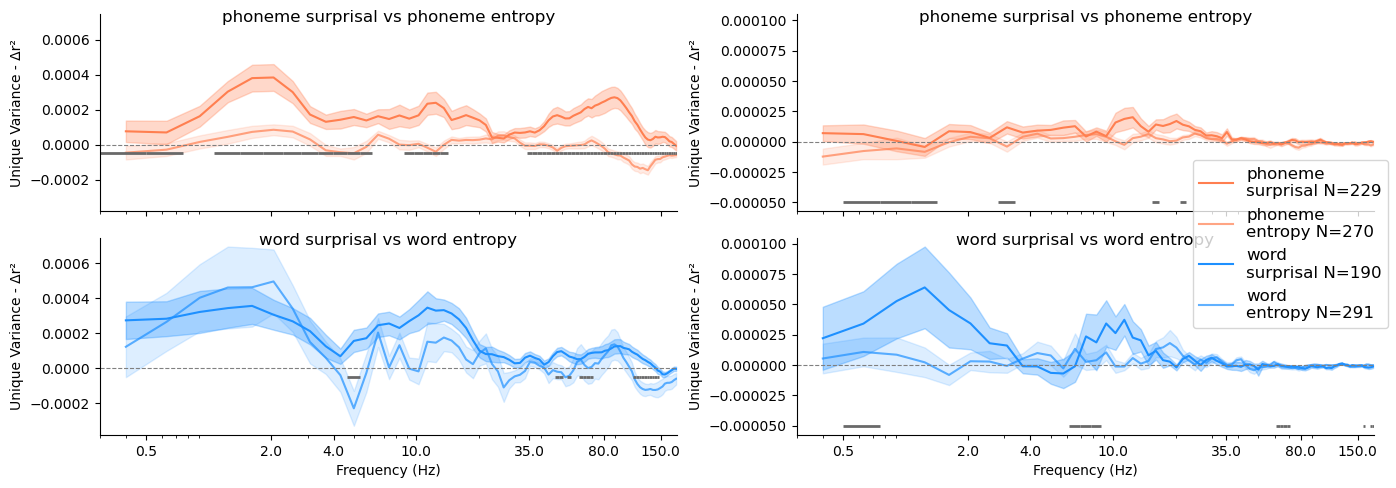

In [44]:
### same but different pairs :
model_pairs = [('phoneme\nsurprisal', 'phoneme\nentropy'), ('word\nsurprisal', 'word\nentropy')]
same_color_in_pair = True

f, ax = plt.subplots(len(model_pairs), 2, figsize=(14, 5), sharex=True, sharey='col')

for i_mask, mask_acou in enumerate([mask_acou_pos, mask_acou_neg]):
    for i_m, (m1, m2) in enumerate(model_pairs):
        if m1 == 'phoneme\nsurprisal': profiles1 = ws_profiles_4preds
        if m1 == 'phoneme\nentropy': profiles1 = we_profiles_4preds
        if m1 == 'word\nsurprisal': profiles1 = ps_profiles_4preds
        if m1 == 'word\nentropy': profiles1 = pe_profiles_4preds

        if m2 == 'phoneme\nsurprisal': profiles2 = ws_profiles_4preds
        if m2 == 'phoneme\nentropy': profiles2 = we_profiles_4preds
        if m2 == 'word\nsurprisal': profiles2 = ps_profiles_4preds
        if m2 == 'word\nentropy': profiles2 = pe_profiles_4preds

        mask1 = dico_4preds_hfa[m1]['mask'][0.001]
        mask2 = dico_4preds_hfa[m2]['mask'][0.001]
        # combined_mask = np.logical_and(mask1, mask2)  # select channels significant in both models

        profiles1 = profiles1[mask1 & mask_acou, :]
        profiles2 = profiles2[mask2 & mask_acou, :]

        mean_profile1 = np.nanmean(profiles1, axis=0)
        sem_profile1 = np.nanstd(profiles1, axis=0) / np.sqrt(profiles1.shape[0])

        mean_profile2 = np.nanmean(profiles2, axis=0)
        sem_profile2 = np.nanstd(profiles2, axis=0) / np.sqrt(profiles2.shape[0])

        ax[i_m, i_mask].plot(freqs_mid, mean_profile1, label=['', f'{m1} N={sum(mask1 & mask_acou)}'][i_mask], color=colors_4preds[m1])
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile1 - sem_profile1, mean_profile1 + sem_profile1, color=colors_4preds[m1], alpha=0.3)

        ax[i_m, i_mask].plot(freqs_mid, mean_profile2, label=['', f'{m2} N={sum(mask2 & mask_acou)}'][i_mask], color=colors_4preds[m2], alpha=0.7 if same_color_in_pair else 1.0)
        ax[i_m, i_mask].fill_between(freqs_mid, mean_profile2 - sem_profile2, mean_profile2 + sem_profile2, color=colors_4preds[m2], alpha=0.15 if same_color_in_pair else 0.3)
        ax[i_m, i_mask].set_xscale('log')
        ax[i_m, i_mask].set_ylabel('Unique Variance - Δr²')
        ax[i_m, i_mask].axhline(0, color='gray', linestyle='--', linewidth=0.8) 
        ax[i_m, i_mask].set_title(f'{m1.replace("\n", " ")} vs {m2.replace("\n", " ")}', y=0.92)    

        # statistical comparison between profiles at each frequency (paired wilcoxon)
        p_values = []
        for freq in range(profiles1.shape[1]):
            stat, p_val = mannwhitneyu(profiles1[:, freq], profiles2[:, freq], alternative='two-sided')
            p_values.append(p_val)
        p_values = np.array(p_values)
        pvals_corrected = false_discovery_control(p_values, method='by')
        sig_freqs = freqs_mid[pvals_corrected < 0.05]
        # sig_freqs = freqs_mid[p_values < 0.05]

        for freq in range(profiles1.shape[1]):
            # if pvals_corrected[freq] < 0.05:
            if p_values[freq] < 0.05:
                ax[i_m, i_mask].hlines(y=-5e-5 , xmin=freqs[freq], xmax=freqs[freq+1], color='dimgray', linewidth=2)

# set xlims
ax[-1,0].set_xlim(0.3, 180)
ax[-1,1].set_xlim(0.3, 180)

# ticks and labels
for i in range(len(model_pairs)):
    for j in range(2):
        ax[i, j].spines[['top', 'right']].set_visible(False)
        ax[i, j].set_xticks(custom_ticks)
        ax[i, j].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[-1,0].set_xlabel('Frequency (Hz)')
ax[-1,1].set_xlabel('Frequency (Hz)')
# f.suptitle('4Preds HFA selection - Unique Variance Spectral Profiles\nSignificant frequencies (p<0.05, FDR-corrected)', y=0.99)

f.legend(loc='center right', fontsize=12)
f.tight_layout()


In [26]:
df_metasubj_fres = pickle.load(open(f'{df_metasubj_fres_path}/df_metasubject_frequency-resolved_bipolar_{signal_feature}_all_levels.pkl', 'rb'))
fres_subjects_ids = list(set([s[:3] for s in df_metasubj_fres['ch_names'].values]))

### Check that all subjects are present in frequency-resolved dataframe
for subj in subjects_ids:
    if subj not in fres_subjects_ids:
        print(f'subject {subj} is missing in frequency-resolved dataframe')

df_metasubj_fres.head()

subject 061 is missing in frequency-resolved dataframe


,ch_names,loc,base,base + pred_linguistic,base + wd + syll,base + wd + ph,base + syll + ph,base + wd,base + syll,base + ph,base + 3surprise,base + 3entropy,base + ~wd_surprise,base + ~wd_entropy,base + ~syll_surprise,base + ~syll_entropy,base + ~ph_surprise,base + ~ph_entropy
sub-001,001_Ia'2-Ia'1,"[-34.375810995697975, 5.4889824241399765, -13....","[-0.08814465028740562, -0.02171808309887848, -...","[-0.08784077827972603, -0.021718537993993304, ...","[-0.08796060822953491, -0.021718401108054765, ...","[-0.08794292336835625, -0.021718389340538026, ...","[-0.08793120240192279, -0.021718383952812913, ...","[-0.08805924505574456, -0.021718246414703747, ...","[-0.08804897451599505, -0.02171824166818226, -...","[-0.08803391345206077, -0.021718231670945175, ...","[-0.0879618501534758, -0.021718316125290384, -...","[-0.08803113315428435, -0.021718316431919148, ...","[-0.08788816586071424, -0.02171846138124418, -...","[-0.08788290360442123, -0.021718461259775834, ...","[-0.08790198233233182, -0.021718464503821623, ...","[-0.08788171722329444, -0.02171846390297456, -...","[-0.08792873175753702, -0.021718470248715427, ...","[-0.08787381137467423, -0.021718470635184995, ..."
sub-001,001_Ia'3-Ia'2,"[-34.76913832128048, 8.027023635804653, -10.40...","[-0.05178384821337332, -0.07395704278108331, -...","[-0.05171345842424542, -0.0739571699573061, -0...","[-0.05174076234056364, -0.07395713159839237, -...","[-0.0517427239753284, -0.07395712850367389, -0...","[-0.05174229180810057, -0.07395712686734117, -...","[-0.05177456789664765, -0.073957088456496, -0....","[-0.051774361620394505, -0.07395708702106174, ...","[-0.051776356851888194, -0.07395708438631546, ...","[-0.05175851017379849, -0.07395710820254986, -...","[-0.051757223589360565, -0.07395710773362665, ...","[-0.051727501345256874, -0.07395714860738574, ...","[-0.051727083686131256, -0.07395714840883123, ...","[-0.05172740610884254, -0.07395714949821053, -...","[-0.05172773751056807, -0.07395714927072014, -...","[-0.0517258013813471, -0.07395715053245326, -0...","[-0.05172742363780194, -0.07395715151174782, -..."
sub-001,001_Ia'4-Ia'3,"[-35.10013781487942, 10.569498874247074, -7.60...","[-0.07812605137276196, -0.12233235311377852, -...","[-0.07812220860016357, -0.12223612467486147, -...","[-0.07812304815111201, -0.12223289518749555, -...","[-0.07812339661195322, -0.12222444952685081, -...","[-0.0781234186127524, -0.12221446756126586, -0...","[-0.07812444357393837, -0.12225345313370325, -...","[-0.0781244684615078, -0.12224612429763733, -0...","[-0.07812477400676436, -0.12224282088135549, -...","[-0.07812393021703863, -0.12223372429115491, -...","[-0.07812387137361823, -0.1222261056072255, -0...","[-0.07812278099759937, -0.12222149413520775, -...","[-0.0781228054489643, -0.12222056496224074, -0...","[-0.07812276718193219, -0.122225005117644, -0....","[-0.07812279827630775, -0.12222844656166103, -...","[-0.07812259273149764, -0.12222883512064384, -...","[-0.07812260848034884, -0.12223516207911338, -..."
sub-001,001_Ia'5-Ia'4,"[-35.41124984622002, 13.132959138602018, -4.78...","[-0.04874264693801007, -0.04492273654995329, -...","[-0.048743318457423655, -0.04492335673036489, ...","[-0.04874311737553914, -0.04492317171298939, -...","[-0.048743099440878755, -0.044923154533775336,...","[-0.048743090444747894, -0.04492314599716503, ...","[-0.048742889069867526, -0.044922960685698586,...","[-0.04874288114471685, -0.0449229531693283, -0...","[-0.04874286591141632, -0.044922938575175396, ...","[-0.048742991666023895, -0.044923054974099944,...","[-0.04874299124743549, -0.044923054944532484, ...","[-0.04874320521999329, -0.044923252154431784, ...","[-0.04874320470691242, -0.044923251542703733, ...","[-0.04874320970167547, -0.04492325653849107, -...","[-0.04874320985317291, -0.044923256296161986, ...","[-0.04874321886631172, -0.04492326507909672, -...","[-0.04874321969673856, -0.04492326596150535, -..."
sub-001,001_Ia'6-Ia'5,"[-35.97523458302021, 17.772937193512917, 0.348...","[-0.34218016856895417, -

In [27]:
dico_anti_fres = {
    'full' : 'base',
    'base + pred_linguistic' : 'base',
    'base + 3surprise' : 'base + 3entropy',
    'base + 3entropy' : 'base + 3surprise',
    'base + wd' : 'base + syll + ph',
    'base + syll' : 'base + wd + ph',
    'base + ph' : 'base + wd + syll',
    'base + wd_entropy' : 'base + ~wd_entropy',
    'base + wd_surprise' : 'base + ~wd_surprise',
    'base + syll_entropy' : 'base + ~syll_entropy',
    'base + syll_surprise' : 'base + ~syll_surprise',
    'base + ph_entropy' : 'base + ~ph_entropy',
    'base + ph_surprise' : 'base + ~ph_surprise',
}

df_metasubj_fres_relative = df_metasubj_fres[['loc', 'ch_names']].copy()

for m in relative_models:
    # print(f"base + {m}")
    if m == 'full':
        df_metasubj_fres_relative[f'{m}'] = df_metasubj_fres['base + pred_linguistic'] - df_metasubj_fres['base']
    else:
        df_metasubj_fres_relative[f'{m}'] = df_metasubj_fres['base + pred_linguistic'] - df_metasubj_fres[dico_anti_fres[f'base + {m}']]
    # masking

df_metasubj_fres_relative.head()

,loc,ch_names,full,ph,syll,wd,3surprise,3entropy,wd_surprise,wd_entropy,syll_surprise,syll_entropy,ph_surprise,ph_entropy,pred_linguistic
sub-001,"[-34.375810995697975, 5.4889824241399765, -13....",001_Ia'2-Ia'1,"[0.00030387200767958977, -4.548951148229674e-0...","[0.00011982994980888617, -1.3688593853908304e-...","[0.00010214508863022609, -1.486534552778973e-0...","[9.042412219675833e-05, -1.5404118039116788e-0...","[0.00019035487455831834, -2.2156207415621743e-...","[0.00012107187374976736, -2.2186870292026373e-...","[4.738758098821183e-05, -7.661274912390548e-08...","[4.2125324695205246e-05, -7.673421746970388e-0...","[6.120405260578998e-05, -7.349017168076233e-08...","[4.0938943568408215e-05, -7.409101874383817e-0...","[8.795347781098695e-05, -6.774527787703488e-08...","[3.3033094948203834e-05, -6.735880830888163e-0...","[0.00030387200767958977, -4.548951148229674e-0..."
sub-001,"[-34.76913832128048, 8.027023635804653, -10.40...",001_Ia'3-Ia'2,"[7.0389789127899e-05, -1.2717622278890506e-07,...","[2.7303916318222043e-05, -3.8358913725944355e-...","[2.9265551082978403e-05, -4.145363220742215e-0...","[2.8833383855147998e-05, -4.308996492952133e-0...","[4.3765165115144944e-05, -6.222367944508367e-0...","[4.505174955306973e-05, -6.175475623926285e-08...","[1.4042921011453435e-05, -2.134992035940364e-0...","[1.3625261885835682e-05, -2.1548474865573652e-...","[1.3947684597122312e-05, -2.0459095570468655e-...","[1.4279086322649404e-05, -2.068658595810735e-0...","[1.2342957101681151e-05, -1.9424852837346407e-...","[1.396521355651742e-05, -1.8445558275237417e-0...","[7.0389789127899e-05, -1.2717622278890506e-07,..."
sub-001,"[-35.10013781487942, 10.569498874247074, -7.60...",001_Ia'4-Ia'3,"[3.842772598391941e-06, 9.622843891704536e-05,...","[8.395509484421249e-07, -3.2294873659188816e-0...","[1.1880117896517772e-06, -1.167514801066194e-0...","[1.2100125888342417e-06, -2.1657113595613398e-...","[1.6627734546609263e-06, -1.001906763598015e-0...","[1.721616875061116e-06, -2.400383706566145e-06...","[5.723974357968453e-07, -1.4630539653726071e-0...","[5.968488007296324e-07, -1.555971262073852e-05...","[5.585817686171168e-07, -1.1119557217470488e-0...","[5.896761441775977e-07, -7.67811320044609e-06,...","[3.841313340746666e-07, -7.2895542176376615e-0...","[3.9988018527004066e-07, -9.625957480968728e-0...","[3.842772598391941e-06, 9.622843891704536e-05,..."
sub-001,"[-35.41124984622002, 13.132959138602018, -4.78...",001_Ia'5-Ia'4,"[-6.715194135822888e-07, -6.201804116021115e-0...","[-2.010818845182838e-07, -1.8501737550358222e-...","[-2.1901654490008582e-07, -2.0219658955489273e...","[-2.280126757611689e-07, -2.107331998624229e-0...","[-3.272099881670987e-07, -3.017858324072531e-0...","[-3.2679139976010685e-07, -3.017562649476613e-...","[-1.1323743036306677e-07, -1.0457593310753133e...","[-1.1375051123252433e-07, -1.0518766115769074e...","[-1.0875574818491884e-07, -1.0019187381832273e...","[-1.0860425074532554e-07, -1.0043420290567484e...","[-9.959111193363901e-08, -9.165126817201052e-0...","[-9.876068509523384e-08, -9.076885953973601e-0...","[-6.715194135822888e-07, -6.201804116021115e-0..."
sub-001,"[-35.97523458302021, 17.772937193512917, 0.348...",001_Ia'6-Ia'5,"[0.000668418347155697, 1.2750647738188348e-05,...","[0.0002044202962805941, 1.1882052378953123e-06...","[0.00020617210554352283, 9.951509527539315e-07...","[0.00022024894153144237, 2.2292819930602725e-0...","[0.00029862200445002207, 3.139767202411936e-06...","[0.000347143651590609, 3.1360243360478712e-06,...","[0.0001016152172828022, 5.810408363338126e-07,...","[0.00011422855347920091, 1.0557808682032377e-0...","[9.454306833478476e-05, 2.5196347493150473e-07...","[0.00010618926256383832, 1.0682381379467643e-0...","[8.440208440507746e-05, 4.931785885925466e-07,...","[0.00011583579369911501, 1.8379416887037703e-0...","[0.000668418347155697, 1.2750647738188348e-05,..."


In [28]:

# len(df_metasubj_fres_relative)

all_chans_fres = df_metasubj_fres['ch_names'].values
# all_chans_fres

mask_in_fres = np.array([True if ch in all_chans_fres else False for ch in all_chans]).reshape(-1, 1)

# we need to mask the masks to keep only channels present in frequency-resolved dataframe
for p in pvals_to_test:
    for m in models[2:]:
        stat_masks[p][m]['mask_fres'] = stat_masks[p][m]['mask'][mask_in_fres]


NameError: name 'pvals_to_test' is not defined

In [ ]:
### SEP figures
### Spatial ?
### ERPs ?

p = 1e-3

cut_freq = 1

# models of interest ############################################

moi_1 = ['ph', 'syll', 'wd']
moi_2 = ['3surprise', '3entropy']
moi_3 = []

# moi_1 = ['ph_entropy', 'ph_surprise']
# moi_2 = ['syll_entropy', 'syll_surprise']
# moi_3 = ['wd_entropy', 'wd_surprise']

title_flag = '2levels_3features'  ###############################

f,ax = plt.subplots(2,1, figsize=(7,6), sharey=True)
for moi in [moi_1, moi_2, moi_3]:
    if moi == moi_1: i = 0
    if moi == moi_2: i = 1
    # if moi == moi_3: i = 2
    for m in moi:
        # dataprep
        mask = stat_masks[p][f'base + {m}']['mask_fres']

        data = np.vstack(df_metasubj_fres_relative[m].values)[mask]
        above = np.percentile(data, 99, axis=0)
        data = np.clip(data, 0, above)  # clip negative values to zero

        # compute average and statistical lower and upper bounds
        avg = np.nanmean(data, axis=0)
        std = np.nanstd(data, axis=0)
        upper = avg + std/np.sqrt(sum(mask))
        lower = avg - std/np.sqrt(sum(mask))
        
        # plot
        ax[i].plot(freqs[cut_freq:], avg[cut_freq:], label=f'{m} N={sum(mask)}', color=colors_[f'base + {m}'])
        ax[i].fill_between(freqs[cut_freq:], lower[cut_freq:], upper[cut_freq:], alpha=0.3, color=colors_[f'base + {m}'])
    
# the rest is aesthetics and informativeness
    ax[i].set_xscale('log')
    ax[i].spines[['top', 'right']].set_visible(False)
ax[1].set_xlabel('Frequencies (Hz)')
ax[0].legend()
ax[1].legend()
# ax[2].legend()
for i in range(2):
    ax[i].set_xticks(custom_ticks)
    ax[i].get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax[i].set_ylabel('Δr²')
f.tight_layout()

if save_figs:
    f.savefig(fig_path + f'/broadband/png/SpectralEncodingProfile_{title_flag}.png', dpi=300, bbox_inches='tight')
    f.savefig(fig_path + f'/broadband/svg/SpectralEncodingProfile_{title_flag}.svg', format='svg', bbox_inches='tight')
